## WiFi-CSI Human Pose Estimation — Assignment 2*

**Option 2: a practical machine-learning system.** This notebook starts from dataset exploration and preprocessing. It is artefact-first: every numbered section starts with a restart cell and can be run without executing earlier analytical sections. Normal use loads versioned manifests, checkpoints, logs, predictions, and metrics instead of rebuilding completed work.

## How to use this notebook

1. Jump directly to any numbered section and run that section's first **restart cell**, followed by the cells you want in that section.
2. Normal execution does not rebuild 166,600 samples or train a model; it loads accepted artefacts.
3. Backend source is displayed from imported modules with `inspect.getsource`, so the notebook shows the exact implementation it executes instead of maintaining a stale second copy.
4. The notebook assumes the datasets have already been acquired and extracted in this project workspace.

## 1. Task definition and real-world data

**Research question.** Can a model estimate a canonical 2D human skeleton from a short WiFi-CSI window, and does label-free exposure to target-domain CSI improve transfer to an unseen environment?

Training input is finite standardized amplitude `float32[9,5,30]`: nine Tx–Rx links, five packets, and thirty subcarriers. Training output is `float32[14,2]`: fourteen hip-centred, torso-normalized body joints. Deployment accepts the same CSI tensor and returns one canonical skeleton; it requires no camera. Wi-Pose provides video-derived AlphaPose supervision. WiMANS has no native skeleton ground truth, so its CSI is used only for label-free adaptation and carefully qualified target evaluation.

In [1]:
# Section 1 restart cell
from pathlib import Path
import collections, json, sys
import pandas as pd

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'environment.yml').exists()), None)
assert PROJECT_ROOT is not None, 'Open the repository first.'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

def read_jsonl(path):
    assert path.exists(), f'Missing artefact: {path}'
    return [json.loads(line) for line in path.open() if line.strip()]

wipose = read_jsonl(PROJECT_ROOT / 'data/manifests/wipose_samples.jsonl')
wimans = read_jsonl(PROJECT_ROOT / 'data/manifests/wimans_partitions_v1.jsonl')
pd.DataFrame({
    'dataset': ['Wi-Pose', 'WiMANS eligible'],
    'records': [len(wipose), len(wimans)],
    'role': ['labelled source', 'unlabelled target'],
})

,dataset,records,role
0,Wi-Pose,166600,labelled source
1,WiMANS eligible,1782,unlabelled target


## 1.1 Wi-Pose: labelled source dataset
Wi-Pose is the supervised source dataset. Each MATLAB v7.3 file contains one five-packet CSI window and one AlphaPose-18 annotation: 18 x-coordinates, 18 y-coordinates, and 18 confidence scores. Raw `(x, y)` is preserved for modelling. Because the released camera coordinate frame appears sideways on a normal screen, a separate clockwise transform is used only for visualization.


In the following figure, the CSI heatmap colour represents amplitude. Skeleton-marker colour represents AlphaPose confidence on a fixed 0–1 viridis scale: purple is lower and yellow is higher confidence.

In [2]:
import json, collections, h5py, numpy as np
source_manifest = PROJECT_ROOT / 'data/manifests/wipose_samples.jsonl'
wipose = [json.loads(line) for line in source_manifest.open(encoding='utf-8')]
print('samples:', len(wipose))
print('archive split:', collections.Counter(r['archive_split'] for r in wipose))
print('participants:', len({r['participant'] for r in wipose}))
raw_path = Path(wipose[0]['csi_path'])
with h5py.File(raw_path, 'r') as f:
    raw_csi = np.asarray(f['CSI'][()], dtype=np.float32)
    pose_vector = np.asarray(f['SkeletonPoints'][()], dtype=np.float32).reshape(3, 18)
joints_pixel = pose_vector[:2, :14].T  # official raw (x, y) target
joints_display = np.column_stack([480 - joints_pixel[:,1], joints_pixel[:,0]])  # display only
confidence = pose_vector[2, :14]
print('raw CSI:', raw_csi.shape, raw_csi.dtype)
print('body joints:', joints_pixel.shape, 'confidence:', confidence.shape)

samples: 166600
archive split: Counter({'Train': 132847, 'Test': 33753})
participants: 120
raw CSI: (3, 3, 30, 5) float32
body joints: (14, 2) confidence: (14,)


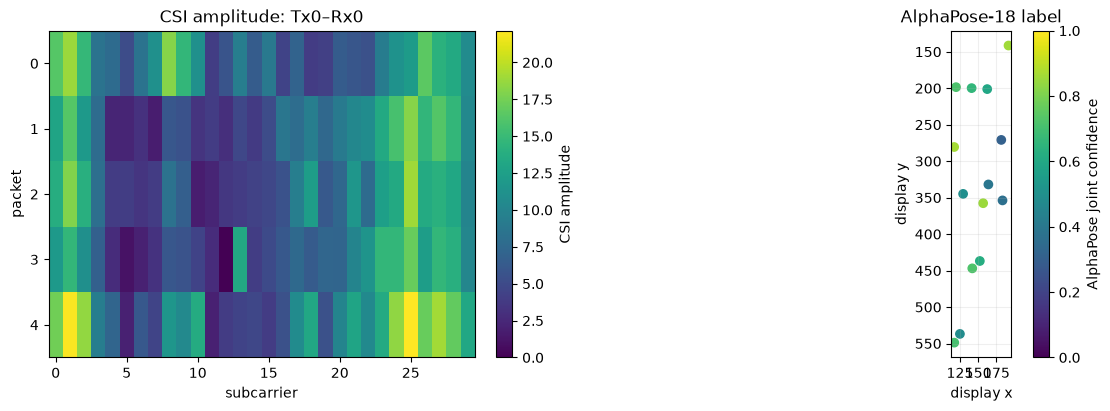

In [3]:
import matplotlib.pyplot as plt
csi = raw_csi.transpose(3, 0, 1, 2)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
heat = axes[0].imshow(csi[:, 0, 0, :], aspect='auto', cmap='viridis')
axes[0].set(title='CSI amplitude: Tx0–Rx0', xlabel='subcarrier', ylabel='packet')
fig.colorbar(heat, ax=axes[0], label='CSI amplitude')
points = axes[1].scatter(joints_display[:,0], joints_display[:,1], c=confidence, cmap='viridis', vmin=0, vmax=1)
axes[1].invert_yaxis(); axes[1].set(title='AlphaPose-18 label', xlabel='display x', ylabel='display y', aspect='equal')
axes[1].grid(alpha=.2)
fig.colorbar(points, ax=axes[1], label='AlphaPose joint confidence')
plt.show()

### Wi-Pose distributions
The filename encodes activity, recording/participant identifier, and frame. Distribution checks reveal class imbalance, participant imbalance, and whether the supplied archive split is suitable for an HPE evaluation. The assignment will later replace the archive split with a participant-grouped 80/10/10 split to prevent adjacent frames from the same person leaking across partitions.


Bar length/height and the participant line encode sample count. Plot colours distinguish categories or panels only; they do not encode another measured variable.

,sample_id,csi_path,pose_path,participant,activity,archive_split
0,bend_001-frame001,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,001,bend,Train
1,bend_001-frame002,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,001,bend,Train
2,bend_001-frame003,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,001,bend,Train
3,bend_001-frame004,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,001,bend,Train
4,bend_001-frame005,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,/data/axnguyen/31050_ML/wifi_csi_hpe/data/extr...,001,bend,Train


,samples,participants,activities,duplicate_ids
0,166600,120,12,0


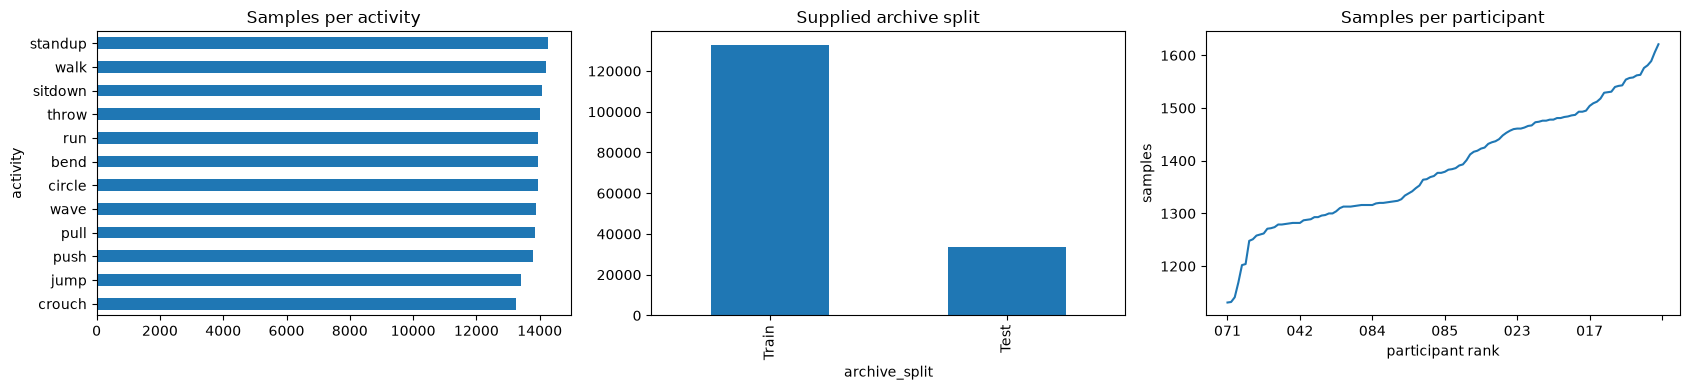

In [4]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
wipose_df = pd.DataFrame(wipose)
display(wipose_df.head())
summary = pd.DataFrame({
    'samples': [len(wipose_df)],
    'participants': [wipose_df.participant.nunique()],
    'activities': [wipose_df.activity.nunique()],
    'duplicate_ids': [wipose_df.sample_id.duplicated().sum()]
})
display(summary)
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
wipose_df.activity.value_counts().sort_values().plot.barh(ax=axes[0], title='Samples per activity')
wipose_df.archive_split.value_counts().plot.bar(ax=axes[1], title='Supplied archive split')
wipose_df.participant.value_counts().sort_values().plot(ax=axes[2], title='Samples per participant')
axes[2].set_xlabel('participant rank'); axes[2].set_ylabel('samples')
plt.tight_layout()

### Wi-Pose signal and pose quality
A raw CSI sample has shape `(3, 3, 30, 5)`: transmit antenna, receive antenna, subcarrier, and packet. The model-facing layout is `(5, 3, 3, 30)`. Pose confidence is inspected before choosing a masking threshold. Canonical coordinates are centred on the hip midpoint and divided by neck-to-hip torso length, which removes camera translation and body-scale variation while preserving articulation.


The blue histogram encodes frequency by bar height. In the pose panel, viridis marker colour encodes AlphaPose confidence from purple (lower) to yellow (higher).

,value
CSI minimum,0.000000
CSI maximum,46.549232
CSI mean,18.152164
CSI std,10.595465
CSI NaNs,0.000000
mean pose confidence,0.616517
minimum pose confidence,0.308481
torso scale,138.634308


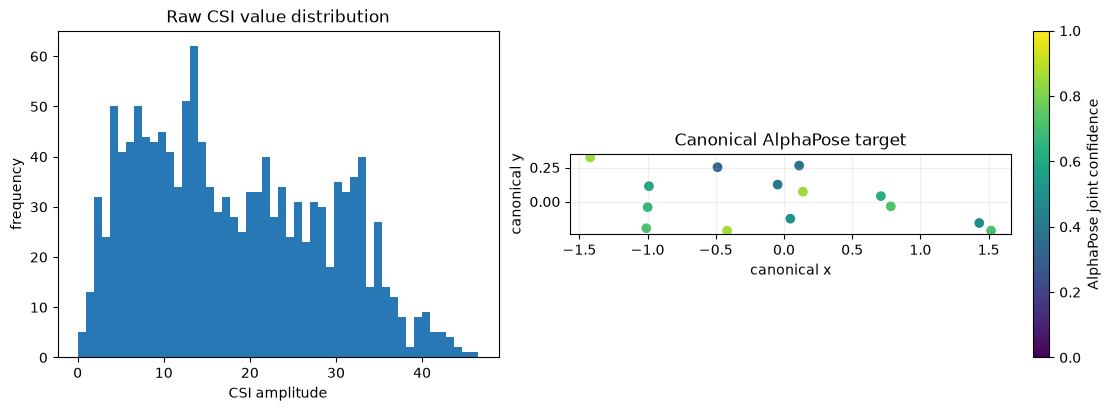

In [5]:
hip_midpoint = (joints_pixel[8] + joints_pixel[11]) / 2
torso = max(np.linalg.norm(joints_pixel[1] - hip_midpoint), 1.0)
joints_canonical = (joints_pixel - hip_midpoint) / torso
quality = pd.Series({
    'CSI minimum': float(np.nanmin(raw_csi)), 'CSI maximum': float(np.nanmax(raw_csi)),
    'CSI mean': float(np.nanmean(raw_csi)), 'CSI std': float(np.nanstd(raw_csi)),
    'CSI NaNs': int(np.isnan(raw_csi).sum()), 'mean pose confidence': float(confidence.mean()),
    'minimum pose confidence': float(confidence.min()), 'torso scale': float(torso)
})
display(quality.to_frame('value'))
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].hist(raw_csi.ravel(), bins=50, color='#2878B5')
axes[0].set(title='Raw CSI value distribution', xlabel='CSI amplitude', ylabel='frequency')
points = axes[1].scatter(joints_canonical[:,0], -joints_canonical[:,1], c=confidence, cmap='viridis', vmin=0, vmax=1)
axes[1].set(title='Canonical AlphaPose target', xlabel='canonical x', ylabel='canonical y', aspect='equal')
axes[1].grid(alpha=.2)
fig.colorbar(points, ax=axes[1], label='AlphaPose joint confidence')
plt.show()

### Wi-Pose CSI–skeleton sequence example
Each Wi-Pose file aligns one skeleton frame with five CSI packets. The [official Wi-Pose release](https://github.com/NjtechCVLab/Wi-PoseDataset) states that synchronized camera images were processed by AlphaPose to create 18 coordinate and confidence labels. These are camera-derived supervision, not manually verified ground truth. Confidence measures the pose estimator's certainty and can mask or down-weight unreliable joints during training. The display uses a shoulder–hip torso outline rather than OpenPose's visually confusing direct neck-to-hip links.


Line colours identify subcarriers in the legend; heatmap colour encodes raw CSI value. Blue skeleton lines are anatomical edges, while viridis joint colour encodes confidence.

,sample_id,activity,participant,frame,packet_start,packet_end
161397,walk_029-frame001,walk,029,1,0,4
161398,walk_029-frame002,walk,029,2,5,9
161399,walk_029-frame003,walk,029,3,10,14
161400,walk_029-frame004,walk,029,4,15,19
161401,walk_029-frame005,walk,029,5,20,24
161402,walk_029-frame006,walk,029,6,25,29
161403,walk_029-frame007,walk,029,7,30,34
161404,walk_029-frame008,walk,029,8,35,39


CSI: (40, 30); skeletons: (8, 18, 2)


,joint_index,joint_name
0,0,nose
1,1,neck
2,2,right shoulder
3,3,right elbow
4,4,right wrist
5,5,left shoulder
6,6,left elbow
7,7,left wrist
8,8,right hip
9,9,right knee


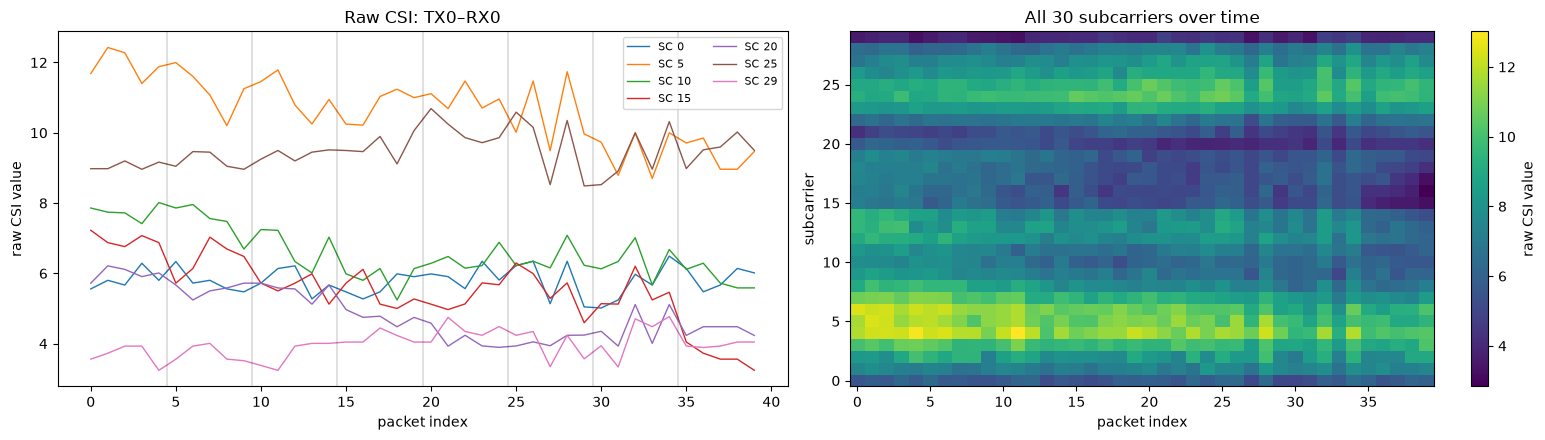

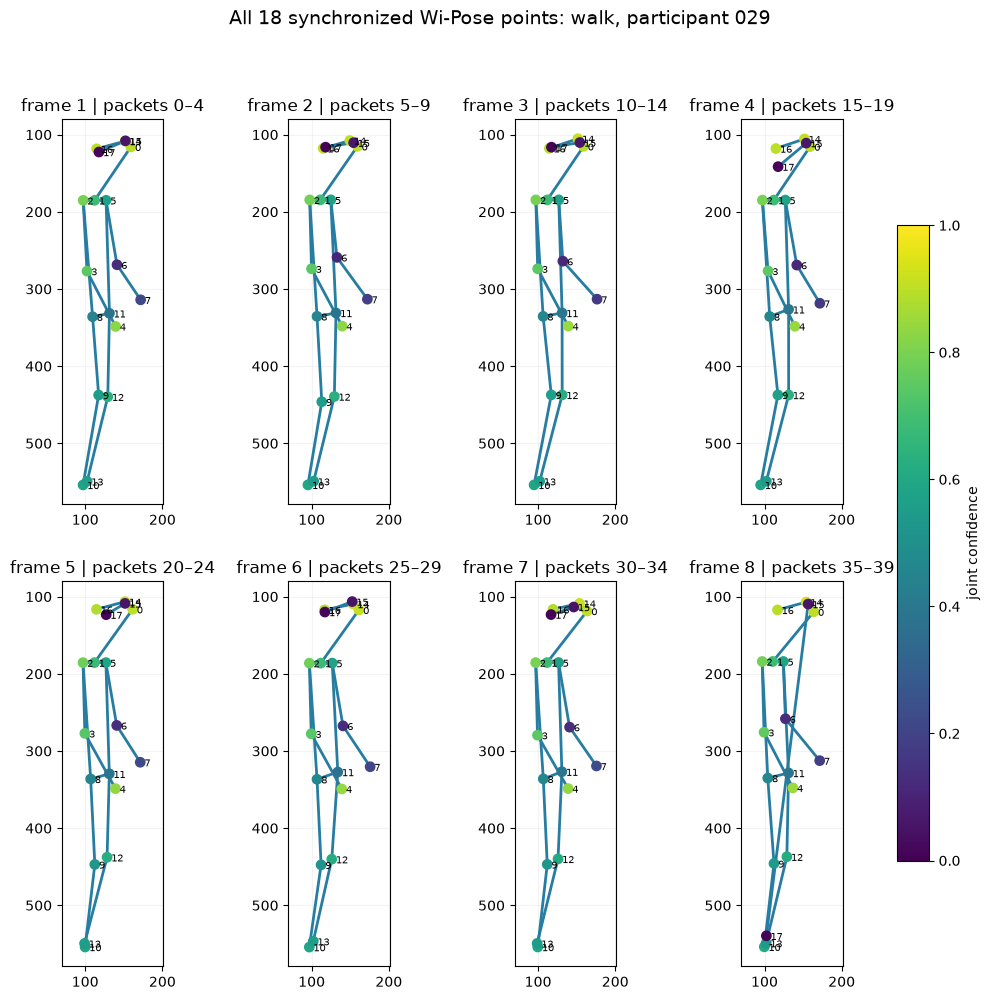

In [6]:
SEQUENCE_ACTIVITY = 'walk'
SEQUENCE_PARTICIPANT = None  # Example: '009'; None selects the longest matching sequence.
N_SEQUENCE_FRAMES = 8
TX_INDEX, RX_INDEX = 0, 0
SUBCARRIERS_TO_PLOT = [0, 5, 10, 15, 20, 25, 29]
sequence_index = wipose_df.copy()
sequence_index['frame'] = sequence_index.sample_id.str.extract(r'-frame(\d+)$')[0].astype(int)
candidates = sequence_index[sequence_index.activity.eq(SEQUENCE_ACTIVITY)]
if SEQUENCE_PARTICIPANT is None: SEQUENCE_PARTICIPANT = candidates.participant.value_counts().index[0]
sequence = candidates[candidates.participant.eq(SEQUENCE_PARTICIPANT)].sort_values('frame').iloc[:N_SEQUENCE_FRAMES].copy()
if sequence.empty: raise ValueError('No matching sequence; check activity and participant.')
csi_windows, skeletons, confidences = [], [], []
for path_text in sequence.csi_path:
    with h5py.File(path_text, 'r') as f:
        raw = np.asarray(f['CSI'][()], dtype=np.float32)
        pose = np.asarray(f['SkeletonPoints'][()], dtype=np.float32).reshape(3, 18)
    csi_windows.append(raw[TX_INDEX, RX_INDEX].T)
    raw_joints=pose[:2,:].T
    skeletons.append(np.column_stack([480-raw_joints[:,1],raw_joints[:,0]])); confidences.append(pose[2,:])
csi_sequence = np.concatenate(csi_windows, axis=0)
skeletons, confidences = np.stack(skeletons), np.stack(confidences)
sequence['packet_start'] = np.arange(len(sequence)) * 5; sequence['packet_end'] = sequence.packet_start + 4
display(sequence[['sample_id','activity','participant','frame','packet_start','packet_end']])
print(f'CSI: {csi_sequence.shape}; skeletons: {skeletons.shape}')
JOINT_NAMES = ['nose','neck','right shoulder','right elbow','right wrist','left shoulder','left elbow','left wrist','right hip','right knee','right ankle','left hip','left knee','left ankle','right eye','left eye','right ear','left ear']
BODY18_EDGES = [(0,1),(1,2),(2,3),(3,4),(1,5),(5,6),(6,7),(2,8),(8,9),(9,10),(5,11),(11,12),(12,13),(2,5),(8,11),(0,14),(14,16),(0,15),(15,17)]
display(pd.DataFrame({'joint_index': range(18), 'joint_name': JOINT_NAMES}))
fig, (ax, ax_heat) = plt.subplots(1, 2, figsize=(16, 4.5))
for sc in SUBCARRIERS_TO_PLOT: ax.plot(csi_sequence[:,sc], label=f'SC {sc}', linewidth=1)
for boundary in range(5,len(csi_sequence),5): ax.axvline(boundary-.5,color='k',alpha=.12)
ax.set(title=f'Raw CSI: TX{TX_INDEX}–RX{RX_INDEX}',xlabel='packet index',ylabel='raw CSI value'); ax.legend(ncol=2,fontsize=8)
image=ax_heat.imshow(csi_sequence.T,aspect='auto',origin='lower',cmap='viridis')
ax_heat.set(title='All 30 subcarriers over time',xlabel='packet index',ylabel='subcarrier'); fig.colorbar(image,ax=ax_heat,label='raw CSI value')
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(2, 4, figsize=(14, 11), squeeze=False)
x_min,x_max=skeletons[:,:,0].min(),skeletons[:,:,0].max(); y_min,y_max=skeletons[:,:,1].min(),skeletons[:,:,1].max(); padding=25
for i,(joints,conf,pose_ax) in enumerate(zip(skeletons,confidences,axes.flat)):
    for a,b in BODY18_EDGES: pose_ax.plot(joints[[a,b],0],joints[[a,b],1],color='#277da1',linewidth=2)
    points=pose_ax.scatter(joints[:,0],joints[:,1],c=conf,cmap='viridis',vmin=0,vmax=1,s=45,zorder=3)
    for joint_id,(x,y) in enumerate(joints): pose_ax.annotate(str(joint_id),(x,y),xytext=(3,-3),textcoords='offset points',fontsize=7)
    pose_ax.set_title(f"frame {sequence.iloc[i].frame} | packets {sequence.iloc[i].packet_start}–{sequence.iloc[i].packet_end}")
    pose_ax.set_aspect('equal'); pose_ax.set_xlim(x_min-padding,x_max+padding); pose_ax.set_ylim(y_max+padding,y_min-padding); pose_ax.grid(alpha=.15)
fig.suptitle(f'All 18 synchronized Wi-Pose points: {SEQUENCE_ACTIVITY}, participant {SEQUENCE_PARTICIPANT}',fontsize=14)
fig.colorbar(points,ax=axes.ravel().tolist(),label='joint confidence',shrink=.75); plt.show()

### Full AlphaPose-labelled skeleton video
Matplotlib can animate the complete selected Wi-Pose sequence inline. The left panel shows all 18 ground-truth points and bones. The right panel shows the raw 30-subcarrier CSI heatmap with a moving cursor at the five packets associated with the current skeleton frame. `VIDEO_FPS` controls playback speed; it is a visualization setting, not a claim about the dataset capture rate. Set `SAVE_MP4=True` to write the same animation under `results/figures/`.


Blue lines are AlphaPose skeleton edges, marker colour is confidence, and the CSI panel uses colour for amplitude. The colour bars define both numeric scales.

In [7]:
from matplotlib import animation
from IPython.display import HTML
VIDEO_FPS = 20
VIDEO_MAX_FRAMES = None  # None uses the full matching recording.
SAVE_MP4 = False
video_sequence = candidates[candidates.participant.eq(SEQUENCE_PARTICIPANT)].sort_values('frame').copy()
if VIDEO_MAX_FRAMES is not None: video_sequence = video_sequence.iloc[:VIDEO_MAX_FRAMES]
video_skeletons, video_confidence, video_csi = [], [], []
for path_text in video_sequence.csi_path:
    with h5py.File(path_text, 'r') as f:
        raw = np.asarray(f['CSI'][()], dtype=np.float32)
        pose = np.asarray(f['SkeletonPoints'][()], dtype=np.float32).reshape(3, 18)
    raw_joints=pose[:2,:].T
    video_skeletons.append(np.column_stack([480-raw_joints[:,1],raw_joints[:,0]]))
    video_confidence.append(pose[2,:])
    video_csi.append(raw[TX_INDEX,RX_INDEX].T)
video_skeletons=np.stack(video_skeletons); video_confidence=np.stack(video_confidence); video_csi=np.concatenate(video_csi)
fig,(pose_ax,csi_ax)=plt.subplots(1,2,figsize=(13,5.5),gridspec_kw={'width_ratios':[1,1.5]})
vx0,vx1=video_skeletons[:,:,0].min()-25,video_skeletons[:,:,0].max()+25
vy0,vy1=video_skeletons[:,:,1].min()-25,video_skeletons[:,:,1].max()+25
pose_ax.set(xlim=(vx0,vx1),ylim=(vy1,vy0),aspect='equal',xlabel='image x',ylabel='image y')
pose_ax.grid(alpha=.15); bone_lines=[pose_ax.plot([],[],color='#277da1',linewidth=2)[0] for _ in BODY18_EDGES]
joint_scatter=pose_ax.scatter([],[],c=[],cmap='viridis',vmin=0,vmax=1,s=55,zorder=3)
joint_labels=[pose_ax.text(0,0,str(i),fontsize=7) for i in range(18)]
heat=csi_ax.imshow(video_csi.T,aspect='auto',origin='lower',cmap='viridis')
cursor=csi_ax.axvspan(0,4,color='red',alpha=.22); csi_ax.set(xlabel='packet index',ylabel='subcarrier',title=f'Raw CSI TX{TX_INDEX}–RX{RX_INDEX}')
fig.colorbar(heat,ax=csi_ax,label='raw CSI value')
def update_video(i):
    global cursor
    joints=video_skeletons[i]; conf=video_confidence[i]
    for line,(a,b) in zip(bone_lines,BODY18_EDGES): line.set_data(joints[[a,b],0],joints[[a,b],1])
    joint_scatter.set_offsets(joints); joint_scatter.set_array(conf)
    for label,(x,y) in zip(joint_labels,joints): label.set_position((x+3,y-3))
    cursor.remove(); cursor=csi_ax.axvspan(i*5,i*5+4,color='red',alpha=.22)
    row=video_sequence.iloc[i]
    pose_ax.set_title(f"{row.activity} | participant {row.participant} | frame {row.frame} | mean confidence {conf.mean():.2f}")
    return [*bone_lines,joint_scatter,*joint_labels,cursor]
ground_truth_video=animation.FuncAnimation(fig,update_video,frames=len(video_sequence),interval=1000/VIDEO_FPS,blit=False,repeat=True)
plt.close(fig)
if SAVE_MP4:
    video_dir=PROJECT_ROOT/'results/figures'; video_dir.mkdir(parents=True,exist_ok=True)
    video_path=video_dir/f"wipose_{SEQUENCE_ACTIVITY}_{SEQUENCE_PARTICIPANT}_ground_truth.mp4"
    ground_truth_video.save(video_path,writer='ffmpeg',fps=VIDEO_FPS,dpi=130); print('saved:',video_path)
HTML(ground_truth_video.to_html5_video())

### Random full-recording skeleton and CSI video
This cell mirrors the full-recording behavior of Cell 14 but chooses a new action/recording pair on every execution. It loads every frame in that recording, renders all 18 AlphaPose-labelled points, and moves a cursor across the complete CSI timeline. Wi-Pose filenames expose recording identifiers rather than a verified volunteer-identity field, so the displayed `recording` value must not be interpreted as a person ID.


The same colour contract is used throughout: blue skeleton edges, viridis confidence markers, and viridis CSI amplitude with labelled colour bars.

In [8]:
from matplotlib import animation
from IPython.display import HTML
RANDOM_FULL_VIDEO_SEED = None  # None gives a new recording each run; use an integer to reproduce it.
RANDOM_FULL_VIDEO_FPS = 20
SAVE_RANDOM_FULL_VIDEO = False
random_full_rng=np.random.default_rng(RANDOM_FULL_VIDEO_SEED)
full_candidates=(wipose_df.groupby(['activity','participant']).size().reset_index(name='frames'))
full_choice=full_candidates.iloc[random_full_rng.integers(len(full_candidates))]
random_full_rows=wipose_df[(wipose_df.activity==full_choice.activity)&(wipose_df.participant==full_choice.participant)].copy()
random_full_rows['frame']=random_full_rows.sample_id.str.extract(r'-frame(\d+)$')[0].astype(int)
random_full_rows=random_full_rows.sort_values('frame').reset_index(drop=True)
random_full_skeletons,random_full_confidence,random_full_csi=[],[],[]
for row in random_full_rows.itertuples():
    with h5py.File(row.csi_path,'r') as f:
        raw=np.asarray(f['CSI'][()],dtype=np.float32)
        pose=np.asarray(f['SkeletonPoints'][()],dtype=np.float32).reshape(3,18)
    raw_joints=pose[:2,:].T
    random_full_skeletons.append(np.column_stack([480-raw_joints[:,1],raw_joints[:,0]]))
    random_full_confidence.append(pose[2,:]); random_full_csi.append(raw[TX_INDEX,RX_INDEX].T)
random_full_skeletons=np.stack(random_full_skeletons); random_full_confidence=np.stack(random_full_confidence); random_full_csi=np.concatenate(random_full_csi)
display(pd.DataFrame({'action':[full_choice.activity],'recording':[full_choice.participant],'first_frame':[random_full_rows.frame.iloc[0]],'last_frame':[random_full_rows.frame.iloc[-1]],'skeleton_frames':[len(random_full_rows)],'CSI_packets':[len(random_full_csi)]}))
fig,(random_pose_ax,random_csi_ax)=plt.subplots(1,2,figsize=(13,5.5),gridspec_kw={'width_ratios':[1,1.6]})
rx0,rx1=random_full_skeletons[:,:,0].min()-25,random_full_skeletons[:,:,0].max()+25
ry0,ry1=random_full_skeletons[:,:,1].min()-25,random_full_skeletons[:,:,1].max()+25
random_pose_ax.set(xlim=(rx0,rx1),ylim=(ry1,ry0),aspect='equal',xlabel='display x',ylabel='display y'); random_pose_ax.grid(alpha=.15)
random_bones=[random_pose_ax.plot([],[],color='#277da1',linewidth=2.5)[0] for _ in BODY18_EDGES]
random_points=random_pose_ax.scatter([],[],c=[],cmap='viridis',vmin=0,vmax=1,s=55,zorder=3)
random_labels=[random_pose_ax.text(0,0,str(i),fontsize=7) for i in range(18)]
random_heat=random_csi_ax.imshow(random_full_csi.T,aspect='auto',origin='lower',cmap='viridis')
random_cursor=random_csi_ax.axvspan(0,4,color='red',alpha=.25)
random_csi_ax.set(title=f'Complete raw CSI TX{TX_INDEX}–RX{RX_INDEX}',xlabel='packet index',ylabel='subcarrier'); fig.colorbar(random_heat,ax=random_csi_ax,label='raw CSI value')
def update_random_full_video(i):
    global random_cursor
    joints=random_full_skeletons[i]; conf=random_full_confidence[i]; row=random_full_rows.iloc[i]
    for line,(a,b) in zip(random_bones,BODY18_EDGES): line.set_data(joints[[a,b],0],joints[[a,b],1])
    random_points.set_offsets(joints); random_points.set_array(conf)
    for label,(x,y) in zip(random_labels,joints): label.set_position((x+3,y-3))
    random_cursor.remove(); random_cursor=random_csi_ax.axvspan(i*5,i*5+4,color='red',alpha=.25)
    random_pose_ax.set_title(f"AlphaPose camera-derived label\naction: {row.activity} | recording: {row.participant}\nframe: {row.frame} ({i+1}/{len(random_full_rows)}) | packets: {i*5}–{i*5+4} | confidence: {conf.mean():.2f}")
    fig.suptitle(f"Random full recording: {row.sample_id.split('-frame')[0]}",weight='bold')
    return [*random_bones,random_points,*random_labels,random_cursor]
random_full_video=animation.FuncAnimation(fig,update_random_full_video,frames=len(random_full_rows),interval=1000/RANDOM_FULL_VIDEO_FPS,blit=False,repeat=True)
plt.close(fig)
if SAVE_RANDOM_FULL_VIDEO:
    video_dir=PROJECT_ROOT/'results/figures'; video_dir.mkdir(parents=True,exist_ok=True)
    random_full_path=video_dir/f"random_full_{full_choice.activity}_{full_choice.participant}.mp4"
    random_full_video.save(random_full_path,writer='ffmpeg',fps=RANDOM_FULL_VIDEO_FPS,dpi=130); print('saved:',random_full_path)
HTML(random_full_video.to_html5_video())

,action,recording,first_frame,last_frame,skeleton_frames,CSI_packets
0,circle,002,1,110,110,550


### Random synchronized CSI, AlphaPose and CSI-Former sample
Run this cell repeatedly to inspect a random action sequence. It selects four consecutive skeleton frames and their twenty synchronized CSI packets. The middle row contains the released AlphaPose-18 camera-derived labels and confidence. The bottom row accepts CSI-Former predictions when available; before training, it is deliberately marked unavailable.


AlphaPose is blue with confidence-coloured joints. CSI-Former, when available, is orange/red and remains visually separate from the video-derived label.

,sample_id,activity,participant,frame,packet_start,packet_end
91,crouch_018-frame092,crouch,018,92,0,4
92,crouch_018-frame093,crouch,018,93,5,9
93,crouch_018-frame094,crouch,018,94,10,14
94,crouch_018-frame095,crouch,018,95,15,19


Action: crouch | participant: 018 | CSI: (20, 30) | AlphaPose labels: (4, 18, 2)


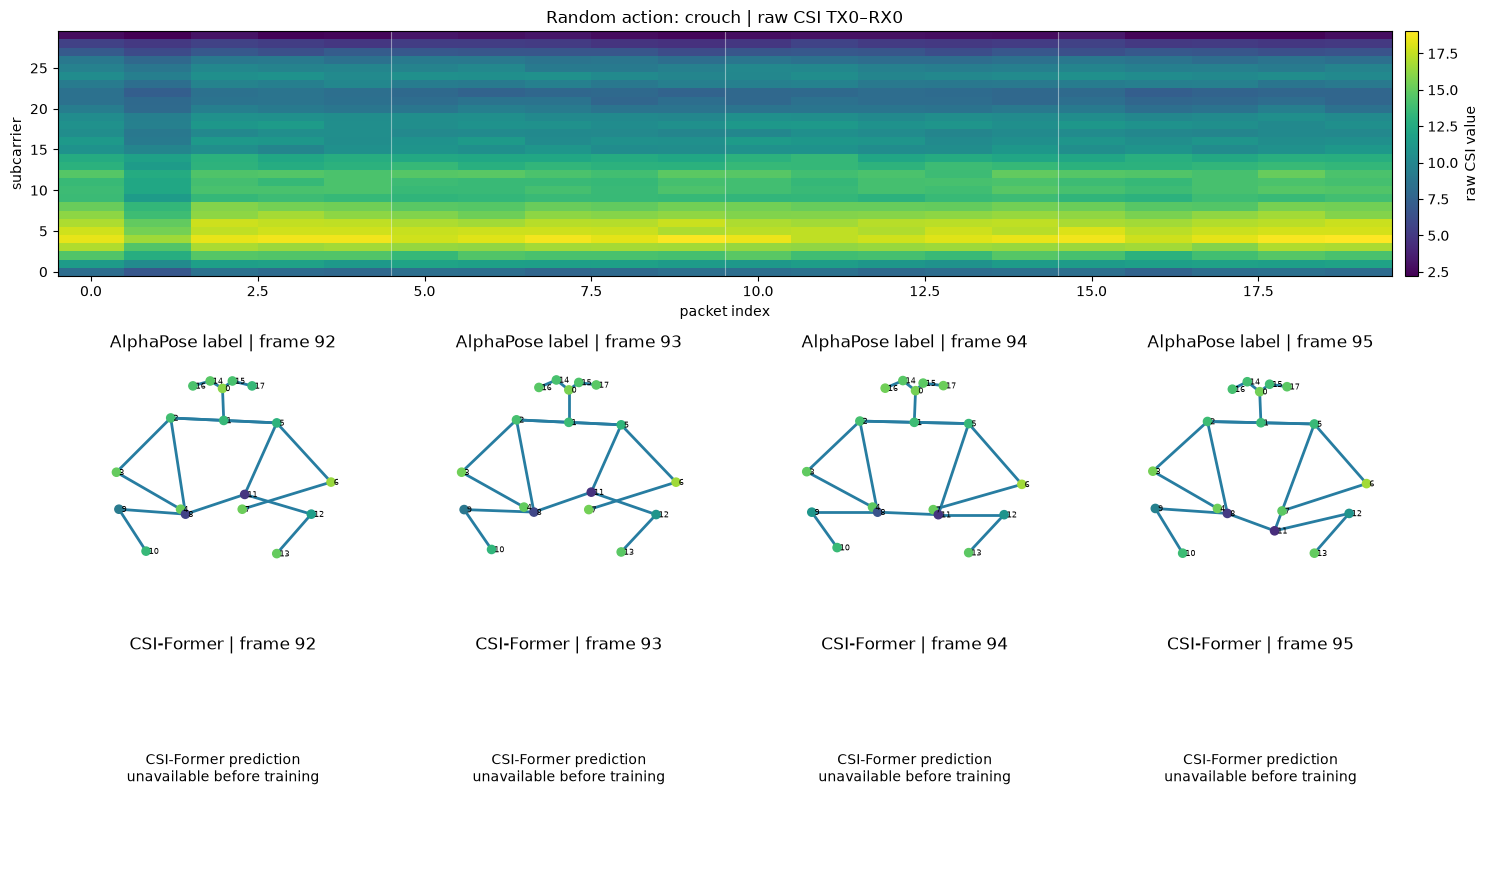

In [9]:
RANDOM_SEED = None  # Use an integer for a repeatable sample.
RANDOM_ACTION = None  # Example: 'run'; None samples any action.
RANDOM_RECORDING = None  # Example: '085'; these IDs represent recordings, not volunteer identity.
RANDOM_SEQUENCE_FRAMES = 4
CSI_FORMER_PREDICTION_FILE = None  # Optional .npz with sample_id [N] and joints [N,18,2].
rng = np.random.default_rng(RANDOM_SEED)
eligible = (wipose_df.groupby(['activity','participant']).size()
            .loc[lambda count: count >= RANDOM_SEQUENCE_FRAMES].reset_index(name='frames'))
if RANDOM_ACTION is not None: eligible=eligible[eligible.activity.eq(RANDOM_ACTION)]
if RANDOM_RECORDING is not None: eligible=eligible[eligible.participant.eq(RANDOM_RECORDING)]
if eligible.empty: raise ValueError('No recording matches RANDOM_ACTION/RANDOM_RECORDING.')
chosen = eligible.iloc[rng.integers(len(eligible))]
random_group = wipose_df[(wipose_df.activity == chosen.activity) &
                          (wipose_df.participant == chosen.participant)].copy()
random_group['frame'] = random_group.sample_id.str.extract(r'-frame(\d+)$')[0].astype(int)
random_group = random_group.sort_values('frame').reset_index(drop=True)
start = int(rng.integers(0, len(random_group)-RANDOM_SEQUENCE_FRAMES+1))
random_rows = random_group.iloc[start:start+RANDOM_SEQUENCE_FRAMES].copy()
random_csi, random_gt, random_conf = [], [], []
for path_text in random_rows.csi_path:
    with h5py.File(path_text,'r') as f:
        raw=np.asarray(f['CSI'][()],dtype=np.float32)
        pose=np.asarray(f['SkeletonPoints'][()],dtype=np.float32).reshape(3,18)
    random_csi.append(raw[TX_INDEX,RX_INDEX].T)
    raw_joints=pose[:2,:].T
    random_gt.append(np.column_stack([480-raw_joints[:,1],raw_joints[:,0]]))
    random_conf.append(pose[2,:])
random_csi=np.concatenate(random_csi); random_gt=np.stack(random_gt); random_conf=np.stack(random_conf)
random_rows['packet_start']=np.arange(len(random_rows))*5; random_rows['packet_end']=random_rows.packet_start+4
display(random_rows[['sample_id','activity','participant','frame','packet_start','packet_end']])
print(f"Action: {chosen.activity} | participant: {chosen.participant} | CSI: {random_csi.shape} | AlphaPose labels: {random_gt.shape}")
prediction_lookup = {}
if CSI_FORMER_PREDICTION_FILE is not None:
    prediction_data=np.load(CSI_FORMER_PREDICTION_FILE,allow_pickle=False)
    prediction_lookup={str(k):v for k,v in zip(prediction_data['sample_id'],prediction_data['joints'])}
fig=plt.figure(figsize=(15,9)); grid=fig.add_gridspec(3,RANDOM_SEQUENCE_FRAMES,height_ratios=[1.1,1,1])
csi_ax=fig.add_subplot(grid[0,:]); heat=csi_ax.imshow(random_csi.T,aspect='auto',origin='lower',cmap='viridis')
for boundary in range(5,len(random_csi),5): csi_ax.axvline(boundary-.5,color='white',alpha=.45,linewidth=.8)
csi_ax.set(title=f"Random action: {chosen.activity} | raw CSI TX{TX_INDEX}–RX{RX_INDEX}",xlabel='packet index',ylabel='subcarrier')
fig.colorbar(heat,ax=csi_ax,label='raw CSI value',fraction=.015,pad=.01)
all_points=[random_gt]
x0,x1=random_gt[:,:,0].min()-25,random_gt[:,:,0].max()+25; y0,y1=random_gt[:,:,1].min()-25,random_gt[:,:,1].max()+25
for column,(row,joints,conf) in enumerate(zip(random_rows.itertuples(),random_gt,random_conf)):
    gt_ax=fig.add_subplot(grid[1,column])
    for a,b in BODY18_EDGES: gt_ax.plot(joints[[a,b],0],joints[[a,b],1],color='#277da1',linewidth=2)
    gt_ax.scatter(joints[:,0],joints[:,1],c=conf,cmap='viridis',vmin=0,vmax=1,s=35,zorder=3)
    for joint_id,(x,y) in enumerate(joints): gt_ax.annotate(str(joint_id),(x,y),xytext=(2,-2),textcoords='offset points',fontsize=6)
    gt_ax.set(title=f'AlphaPose label | frame {row.frame}',xlim=(x0,x1),ylim=(y1,y0),aspect='equal'); gt_ax.axis('off')
    pred_ax=fig.add_subplot(grid[2,column]); prediction=prediction_lookup.get(row.sample_id)
    if prediction is None:
        pred_ax.text(.5,.5,'CSI-Former prediction\nunavailable before training',ha='center',va='center',transform=pred_ax.transAxes)
    else:
        prediction=np.asarray(prediction,dtype=np.float32)
        prediction_display=np.column_stack([480-prediction[:,1],prediction[:,0]])
        for a,b in BODY18_EDGES: pred_ax.plot(prediction_display[[a,b],0],prediction_display[[a,b],1],color='#f3722c',linewidth=2)
        pred_ax.scatter(prediction_display[:,0],prediction_display[:,1],color='#f94144',s=35,zorder=3)
    pred_ax.set(title=f'CSI-Former | frame {row.frame}',xlim=(x0,x1),ylim=(y1,y0),aspect='equal'); pred_ax.axis('off')
plt.tight_layout(); plt.show()

#### Animated random AlphaPose versus CSI-Former comparison
This video uses the same randomly selected recording as the preceding cell, but chooses its highest-motion 40-frame window by default. This avoids clip-level action labels showing only stationary lead-in or recovery frames. AlphaPose camera-derived labels are rendered in blue with confidence-coloured joints. CSI-Former predictions are rendered separately in orange/red only when real predictions are loaded.


Blue denotes AlphaPose labels; orange/red denotes CSI-model predictions. Marker colour and any colour bar must be read using the panel label rather than as ground truth confidence.

In [10]:
from matplotlib import animation
from IPython.display import HTML
RANDOM_VIDEO_FRAMES = min(40, len(random_group))
RANDOM_VIDEO_FPS = 15
RANDOM_VIDEO_WINDOW_MODE = 'most_dynamic'  # Alternatives: 'random'
preview_skeletons=[]
for path_text in random_group.csi_path:
    with h5py.File(path_text,'r') as f: preview_pose=np.asarray(f['SkeletonPoints'][()],dtype=np.float32).reshape(3,18)
    preview_raw=preview_pose[:2,:14].T
    preview_skeletons.append(np.column_stack([480-preview_raw[:,1],preview_raw[:,0]]))
preview_skeletons=np.stack(preview_skeletons)
frame_motion=np.mean(np.linalg.norm(np.diff(preview_skeletons,axis=0),axis=2),axis=1)
if RANDOM_VIDEO_WINDOW_MODE == 'most_dynamic' and RANDOM_VIDEO_FRAMES > 1:
    window_scores=np.convolve(frame_motion,np.ones(RANDOM_VIDEO_FRAMES-1),mode='valid')
    video_start=int(np.argmax(window_scores)); selected_motion=float(window_scores[video_start]/(RANDOM_VIDEO_FRAMES-1))
else:
    video_start=int(rng.integers(0,len(random_group)-RANDOM_VIDEO_FRAMES+1)); selected_motion=float(frame_motion[video_start:video_start+RANDOM_VIDEO_FRAMES-1].mean())
comparison_rows = random_group.iloc[video_start:video_start+RANDOM_VIDEO_FRAMES].copy()
print(f"Video selection: {chosen.activity}, recording {chosen.participant}, frames {comparison_rows.frame.iloc[0]}–{comparison_rows.frame.iloc[-1]}, mean joint motion {selected_motion:.2f} pixels/frame")
comparison_gt, comparison_conf, comparison_csi, comparison_pred = [], [], [], []
for row in comparison_rows.itertuples():
    with h5py.File(row.csi_path,'r') as f:
        raw=np.asarray(f['CSI'][()],dtype=np.float32)
        pose=np.asarray(f['SkeletonPoints'][()],dtype=np.float32).reshape(3,18)
    raw_gt=pose[:2,:].T
    comparison_gt.append(np.column_stack([480-raw_gt[:,1],raw_gt[:,0]]))
    comparison_conf.append(pose[2,:]); comparison_csi.append(raw[TX_INDEX,RX_INDEX].T)
    pred=prediction_lookup.get(row.sample_id)
    comparison_pred.append(None if pred is None else np.column_stack([480-np.asarray(pred)[:,1],np.asarray(pred)[:,0]]))
comparison_gt=np.stack(comparison_gt); comparison_conf=np.stack(comparison_conf); comparison_csi=np.concatenate(comparison_csi)
has_predictions=all(p is not None for p in comparison_pred)
fig,(gt_ax,pred_ax,csi_ax)=plt.subplots(1,3,figsize=(16,5),gridspec_kw={'width_ratios':[1,1,1.7]})
cx0,cx1=comparison_gt[:,:,0].min()-25,comparison_gt[:,:,0].max()+25
cy0,cy1=comparison_gt[:,:,1].min()-25,comparison_gt[:,:,1].max()+25
for axis in (gt_ax,pred_ax): axis.set(xlim=(cx0,cx1),ylim=(cy1,cy0),aspect='equal'); axis.axis('off')
gt_lines=[gt_ax.plot([],[],color='#277da1',linewidth=2.5,label='AlphaPose label' if i==0 else None)[0] for i,_ in enumerate(BODY18_EDGES)]
gt_points=gt_ax.scatter([],[],c=[],cmap='viridis',vmin=0,vmax=1,s=55,zorder=3)
pred_lines=[pred_ax.plot([],[],color='#f3722c',linewidth=2.5,label='CSI-Former' if i==0 else None)[0] for i,_ in enumerate(BODY18_EDGES)]
pred_points=pred_ax.scatter([],[],color='#f94144',s=55,zorder=3)
if not has_predictions: pred_ax.text(.5,.5,'CSI-Former predictions unavailable\nLoad a real prediction file above',ha='center',va='center',transform=pred_ax.transAxes,color='#c1121f',weight='bold')
heat=csi_ax.imshow(comparison_csi.T,aspect='auto',origin='lower',cmap='viridis')
comparison_cursor=csi_ax.axvspan(0,4,color='red',alpha=.25)
csi_ax.set(title=f'Raw CSI TX{TX_INDEX}–RX{RX_INDEX}',xlabel='packet index',ylabel='subcarrier'); fig.colorbar(heat,ax=csi_ax,label='raw CSI value')
def update_random_comparison(i):
    global comparison_cursor
    joints=comparison_gt[i]; conf=comparison_conf[i]; row=comparison_rows.iloc[i]
    for line,(a,b) in zip(gt_lines,BODY18_EDGES): line.set_data(joints[[a,b],0],joints[[a,b],1])
    gt_points.set_offsets(joints); gt_points.set_array(conf)
    gt_ax.set_title(f'AlphaPose camera-derived label\n{row.activity} | frame {row.frame} | mean confidence {conf.mean():.2f}',color='#277da1',weight='bold')
    if has_predictions:
        pred=comparison_pred[i]
        for line,(a,b) in zip(pred_lines,BODY18_EDGES): line.set_data(pred[[a,b],0],pred[[a,b],1])
        pred_points.set_offsets(pred); pred_ax.set_title(f'CSI-Former prediction\n{row.activity} | frame {row.frame}',color='#f3722c',weight='bold')
    else: pred_ax.set_title('CSI-Former prediction',color='#f3722c',weight='bold')
    comparison_cursor.remove(); comparison_cursor=csi_ax.axvspan(i*5,i*5+4,color='red',alpha=.25)
    fig.suptitle(f'Random synchronized comparison | action: {row.activity} | participant: {row.participant}',weight='bold')
    return [*gt_lines,gt_points,*pred_lines,pred_points,comparison_cursor]
random_comparison_video=animation.FuncAnimation(fig,update_random_comparison,frames=len(comparison_rows),interval=1000/RANDOM_VIDEO_FPS,blit=False,repeat=True)
plt.close(fig)
HTML(random_comparison_video.to_html5_video())

Video selection: crouch, recording 018, frames 29–68, mean joint motion 4.98 pixels/frame


## 1.2 WiMANS: unlabelled target-domain dataset
WiMANS contains synchronized CSI, video, and categorical multi-user annotations. It does not contain joint coordinates. For HPE, its CSI can support self-supervised target-domain adaptation, while its videos can later produce confidence-filtered pseudo-skeletons. The annotation audit below distinguishes native ground truth from labels that must be derived.

In [11]:
annotation_path = PROJECT_ROOT / 'data/extracted/wimans/annotation.csv'
wimans = pd.read_csv(annotation_path, encoding='utf-8-sig')
display(wimans.head())
display(pd.DataFrame({
    'rows': [len(wimans)], 'columns': [wimans.shape[1]],
    'unique labels': [wimans.label.nunique()],
    'environments': [wimans.environment.nunique()],
    'bands': [wimans.wifi_band.nunique()]
}))
missing = wimans.isna().sum().sort_values(ascending=False)
display(missing[missing.gt(0)].to_frame('missing values'))

,#,label,environment,wifi_band,number_of_users,user_1_location,user_2_location,user_3_location,user_4_location,user_5_location,user_6_location,user_1_activity,user_2_activity,user_3_activity,user_4_activity,user_5_activity,user_6_activity
0,1,act_1_1,classroom,2.4,1,a,NaN,NaN,NaN,NaN,NaN,nothing,NaN,NaN,NaN,NaN,NaN
1,2,act_1_2,classroom,2.4,1,a,NaN,NaN,NaN,NaN,NaN,walk,NaN,NaN,NaN,NaN,NaN
2,3,act_1_3,classroom,2.4,1,a,NaN,NaN,NaN,NaN,NaN,rotation,NaN,NaN,NaN,NaN,NaN
3,4,act_1_4,classroom,2.4,1,a,NaN,NaN,NaN,NaN,NaN,jump,NaN,NaN,NaN,NaN,NaN
4,5,act_1_5,classroom,2.4,1,a,NaN,NaN,NaN,NaN,NaN,wave,NaN,NaN,NaN,NaN,NaN


,rows,columns,unique labels,environments,bands
0,11286,17,11286,3,2


,missing values
user_4_location,6534
user_3_activity,6534
user_3_location,6534
user_2_location,6534
user_1_location,6534
user_2_activity,6534
user_1_activity,6534
user_6_location,6534
user_5_location,6534
user_5_activity,6534


### WiMANS scene and activity distributions
Environment and band balance determine whether a model can be tested across rooms and frequencies. User-count balance matters because the proposed source task is single-person pose estimation. Blank user slots are expected: a one-user record has five unused location/activity columns. The activity plot therefore stacks only nonblank user annotations.


Bar height encodes recording count. Colours separate categories/panels only and do not represent a continuous measurement.

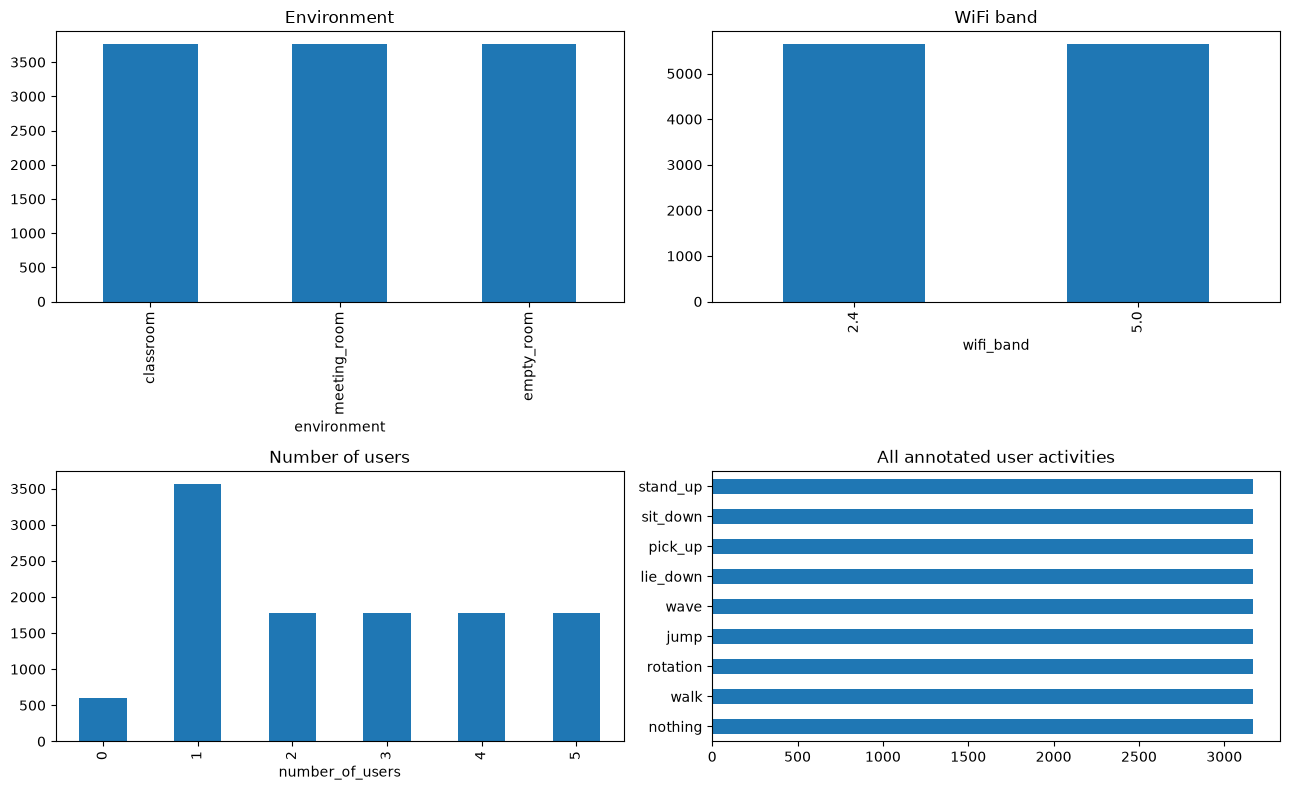

In [12]:
activity_cols = [f'user_{i}_activity' for i in range(1, 7)]
activities = wimans[activity_cols].stack().dropna()
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
wimans.environment.value_counts().plot.bar(ax=axes[0,0], title='Environment')
wimans.wifi_band.astype(str).value_counts().plot.bar(ax=axes[0,1], title='WiFi band')
wimans.number_of_users.value_counts().sort_index().plot.bar(ax=axes[1,0], title='Number of users')
activities.value_counts().sort_values().plot.barh(ax=axes[1,1], title='All annotated user activities')
plt.tight_layout()

### WiMANS modality coverage
Every annotation label should map to CSI amplitude, raw MATLAB CSI, and video by filename stem. This audit reports missing or extra files without loading the 72 GB dataset into memory. The amplitude arrays are the practical input for exploratory statistics; raw MATLAB traces remain available for later phase-aware preprocessing.

In [13]:
wimans_root = PROJECT_ROOT / 'data/extracted/wimans'
labels = set(wimans.label.astype(str))
amp_stems = {p.stem for p in (wimans_root / 'wifi_csi/amp').glob('*.npy')}
mat_stems = {p.stem for p in (wimans_root / 'wifi_csi/mat').glob('*.mat')}
video_stems = {p.stem for p in (wimans_root / 'video').glob('*.mp4')}
coverage = pd.DataFrame({
    'modality': ['annotation', 'amplitude', 'raw MATLAB CSI', 'video'],
    'files/records': [len(labels), len(amp_stems), len(mat_stems), len(video_stems)],
    'missing annotation labels': [0, len(labels-amp_stems), len(labels-mat_stems), len(labels-video_stems)],
    'extra file stems': [0, len(amp_stems-labels), len(mat_stems-labels), len(video_stems-labels)]
})
display(coverage)

,modality,files/records,missing annotation labels,extra file stems
0,annotation,11286,0,0
1,amplitude,11286,0,0
2,raw MATLAB CSI,11286,0,0
3,video,11286,0,0


### WiMANS CSI sample
WiMANS amplitude samples are variable-length arrays shaped `(time, 3, 3, 30)`. The code uses memory mapping for one file, checks finite values, plots one antenna link across time and subcarriers, and records duration in packets. Later preprocessing will crop or pad these sequences to a fixed window without fitting statistics on monitor or test groups.


Heatmap colour encodes CSI amplitude; the labelled colour bar provides the numeric scale.

,value
file,act_10_97.npy
shape,"(2907, 3, 3, 30)"
dtype,float32
minimum,0.0
maximum,179.605118
mean,64.06588
std,28.739796
non-finite values,0


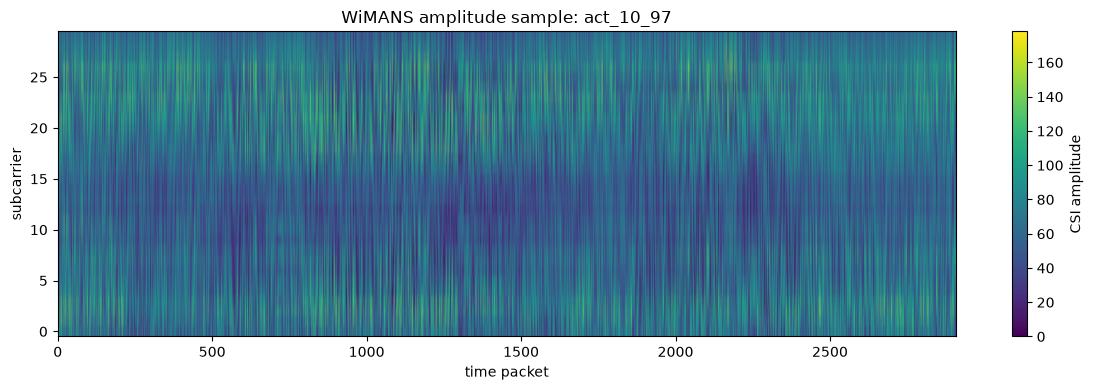

In [14]:
amp_path = next((wimans_root / 'wifi_csi/amp').glob('*.npy'))
amp = np.load(amp_path, mmap_mode='r')
display(pd.Series({
    'file': amp_path.name, 'shape': str(amp.shape), 'dtype': str(amp.dtype),
    'minimum': float(np.nanmin(amp)), 'maximum': float(np.nanmax(amp)),
    'mean': float(np.nanmean(amp)), 'std': float(np.nanstd(amp)),
    'non-finite values': int((~np.isfinite(amp)).sum())
}).to_frame('value'))
plt.figure(figsize=(12, 4))
plt.imshow(amp[:, 0, 0, :].T, aspect='auto', origin='lower')
plt.colorbar(label='CSI amplitude'); plt.xlabel('time packet'); plt.ylabel('subcarrier')
plt.title(f'WiMANS amplitude sample: {amp_path.stem}')
plt.tight_layout()

### WiMANS packet- and link-level CSI exploration

This view makes the four CSI axes explicit. Line colour identifies a Tx–Rx link, heatmap colour encodes amplitude, and bar colour identifies the same nine links. These are native WiMANS amplitude arrays; no pose coordinates are available.

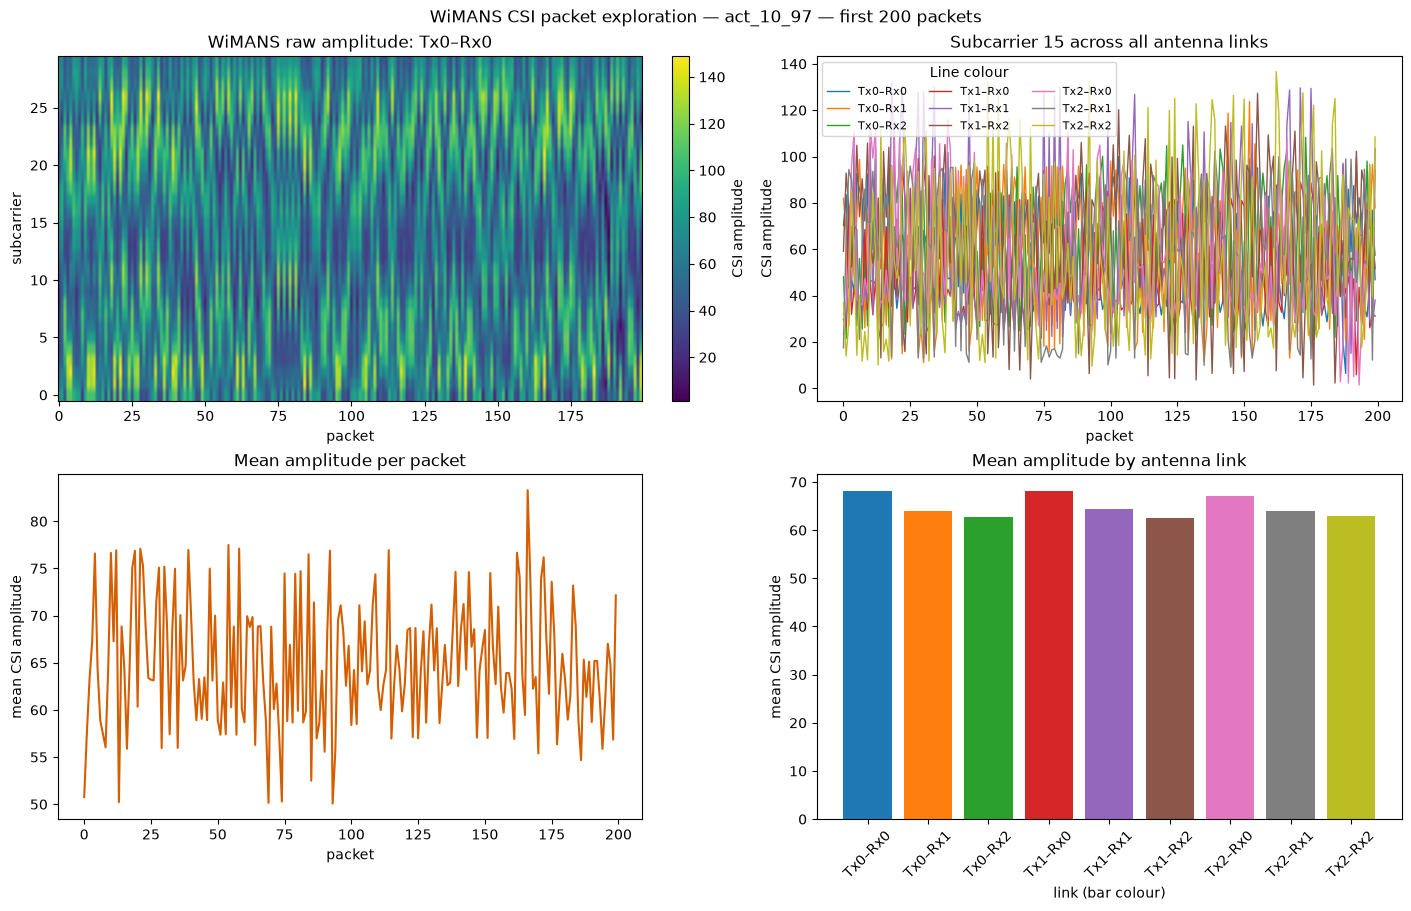

In [15]:
# Inspect packet dynamics without loading the complete dataset into RAM.
preview_packets = min(200, amp.shape[0])
preview = np.asarray(amp[:preview_packets], dtype=np.float32)
assert preview.ndim == 4 and preview.shape[1:] == (3, 3, 30)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
heat = axes[0,0].imshow(preview[:,0,0,:].T, aspect='auto', origin='lower', cmap='viridis')
axes[0,0].set(title='WiMANS raw amplitude: Tx0–Rx0', xlabel='packet', ylabel='subcarrier')
fig.colorbar(heat, ax=axes[0,0], label='CSI amplitude')

for tx in range(3):
    for rx in range(3):
        axes[0,1].plot(preview[:,tx,rx,15], label=f'Tx{tx}–Rx{rx}', linewidth=1)
axes[0,1].set(title='Subcarrier 15 across all antenna links', xlabel='packet', ylabel='CSI amplitude')
axes[0,1].legend(ncol=3, fontsize=8, title='Line colour')

axes[1,0].plot(preview.mean(axis=(1,2,3)), color='#D55E00')
axes[1,0].set(title='Mean amplitude per packet', xlabel='packet', ylabel='mean CSI amplitude')

link_means = preview.mean(axis=(0,3)).reshape(-1)
link_labels = [f'Tx{tx}–Rx{rx}' for tx in range(3) for rx in range(3)]
axes[1,1].bar(link_labels, link_means, color=plt.cm.tab10.colors[:9])
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set(title='Mean amplitude by antenna link', xlabel='link (bar colour)', ylabel='mean CSI amplitude')
fig.suptitle(f'WiMANS CSI packet exploration — {amp_path.stem} — first {preview_packets} packets')
plt.show()

### Exploration conclusion for HPE
Wi-Pose supplies CSI-to-skeleton supervision but is dominated by adjacent frames, so participant grouping is mandatory. WiMANS supplies target-domain CSI across rooms, bands, activities, and user counts, but no native skeleton ground truth. The strict zero-shot condition must freeze the Wi-Pose-trained model before WiMANS inference. The adaptation condition may use unlabelled WiMANS CSI for masked reconstruction. Any video-derived WiMANS skeletons must be reported as pseudo-labels and kept out of strict zero-shot training.

## 2. Preprocessing and data–model alignment

Wi-Pose CSI is converted from `[Tx=3,Rx=3,subcarrier=30,packet=5]` to amplitude and rearranged as `[link=9,packet=5,subcarrier=30]`. Source-training statistics standardize each link/subcarrier. AlphaPose-18 is mapped by joint name to BODY-14, translated to the hip midpoint, and divided by neck-to-hip torso length. Splitting occurs before fitting normalization.

In [16]:
# Section 2 restart cell: load accepted artefacts, never rebuild implicitly.
from pathlib import Path
import inspect, json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Code, display

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'environment.yml').exists()), None)
assert PROJECT_ROOT is not None, 'Open the repository first.'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

from shared.data import preprocessing, preprocess_wipose, prepare_readiness
required = {
    'quality': PROJECT_ROOT / 'data/manifests/quality_report_v1.json',
    'split': PROJECT_ROOT / 'data/manifests/split_v1.json',
    'normalizer': PROJECT_ROOT / 'data/processed/normalization_wipose_train_v1.npz',
}
missing = [name for name, path in required.items() if not path.exists()]
assert not missing, f'Run preprocessing once; missing: {missing}'
quality = json.loads(required['quality'].read_text())
split_info = json.loads(required['split'].read_text())
with np.load(required['normalizer'], allow_pickle=False) as z:
    csi_mean, csi_std = z['mean'], z['std']
assert quality['checks']['split_overlap'] is False and csi_mean.shape == csi_std.shape == (9, 30)
pd.DataFrame({'groups': {p: len(split_info['groups'][p]) for p in ('train','monitor','test')},
              'frames': split_info['sample_counts']})

,groups,frames
train,96,132786
monitor,12,16169
test,12,17645


### 2.1 Implemented data-readiness artefacts

The final Wi-Pose inventory is split by complete recording/participant identifier with seed `31050`: 96 groups for training, 12 for per-epoch monitoring, and 12 for the untouched final test. Because recordings contain different numbers of frames, the achieved frame counts are close to, but not exactly, 80/10/10. CSI normalization is fitted only on the training frames.

WiMANS is restricted to single-person 5 GHz recordings. Classroom and meeting-room recordings form the unlabelled SSL partition; empty-room recordings form the frozen zero-shot partition. WiMANS has activity metadata but no native skeleton ground truth.

In [17]:
# Run the complete data-readiness stage from the ML_31005 kernel.
from shared.data.prepare_readiness import main as prepare_data

prepare_data()  # split, WiMANS partitions, train-only normalization, quality report

normalization: 5000/132786 training samples


normalization: 10000/132786 training samples


normalization: 15000/132786 training samples


normalization: 20000/132786 training samples


normalization: 25000/132786 training samples


...

normalization: 115000/132786 training samples


normalization: 120000/132786 training samples


normalization: 125000/132786 training samples


normalization: 130000/132786 training samples


ready: Wi-Pose=166600, WiMANS=1782


In [18]:
readiness = json.loads((PROJECT_ROOT / 'data/manifests/quality_report_v1.json').read_text())
split_info = json.loads((PROJECT_ROOT / 'data/manifests/split_v1.json').read_text())
with np.load(PROJECT_ROOT / 'data/processed/normalization_wipose_train_v1.npz', allow_pickle=False) as z:
    csi_mean, csi_std = z['mean'], z['std']
    fitted_samples = int(z['fitted_samples'])

assert readiness['checks'] == {
    'split_overlap': False,
    'wimans_partition_overlap': False,
    'normalizer_train_only': True,
    'loader_shape_and_finite': True,
}
assert csi_mean.shape == csi_std.shape == (9, 30) and fitted_samples == 132_786

pd.DataFrame({
    'partition': ['train', 'monitor', 'test'],
    'groups': [len(split_info['groups'][p]) for p in ('train', 'monitor', 'test')],
    'frames': [split_info['sample_counts'][p] for p in ('train', 'monitor', 'test')],
})

,partition,groups,frames
0,train,96,132786
1,monitor,12,16169
2,test,12,17645


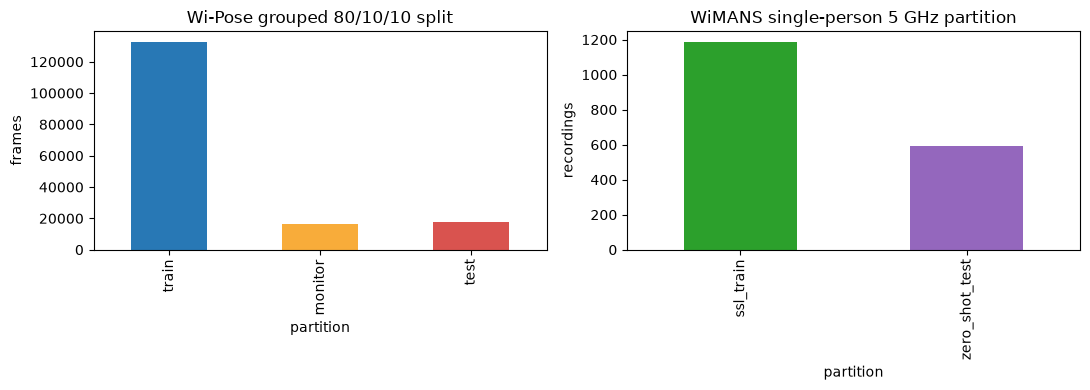

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pd.Series(split_info['sample_counts']).reindex(['train', 'monitor', 'test']).plot.bar(ax=axes[0], color=['#2878B5', '#F8AC3A', '#D9534F'])
axes[0].set(title='Wi-Pose grouped 80/10/10 split', ylabel='frames', xlabel='partition')
pd.Series(readiness['wimans']['partition_counts']).plot.bar(ax=axes[1], color=['#2CA02C', '#9467BD'])
axes[1].set(title='WiMANS single-person 5 GHz partition', ylabel='recordings', xlabel='partition')
plt.tight_layout()
plt.show()

### 2.2 Model-input transformation

Wi-Pose stores each frame's amplitude as five packets × three transmitters × three receivers × 30 subcarriers. The shared loader rearranges this to nine antenna links × five packets × 30 subcarriers and applies the frozen `[9, 30]` training statistics. The `.npz` source remains unchanged.

No additional temporal smoothing is applied in readiness version 1. A five-packet window is too short for the longer Hampel/Savitzky–Golay/band-pass chain used in the earlier WiSe4Car breathing pipeline, and ACF would remove timing information needed for pose regression. Such filtering should be added only after reconstructing continuous Wi-Pose recordings and validating it as an HPE ablation.

For raw amplitude $a_{l,t,s}$ on link $l$, packet $t$, and subcarrier $s$, the source-training normalizer applies

$$x_{l,t,s}=\frac{a_{l,t,s}-\mu_{l,s}}{\max(\sigma_{l,s},\epsilon)},$$

where $\mu_{l,s}$ and $\sigma_{l,s}$ use Wi-Pose training packets only. For BODY-14 joint $j$, the canonical target is

$$\mathbf y_j=\frac{\mathbf p_j-\mathbf h}{d},\qquad
\mathbf h=\frac{\mathbf p_{\mathrm{right\ hip}}+\mathbf p_{\mathrm{left\ hip}}}{2},\qquad
d=\max\!\left(\left\|\mathbf p_{\mathrm{neck}}-\mathbf h\right\|_2,\epsilon\right).$$

This coordinate contract makes errors dimensionless fractions of torso length.

{'sample': 'bend_001-frame001', 'action': 'bend', 'partition': 'monitor', 'raw_csi': (5, 3, 3, 30), 'model_csi': (9, 5, 30), 'source_pose': (18, 2), 'training_pose': (14, 2), 'torso_scale_px': 138.63430786132812}


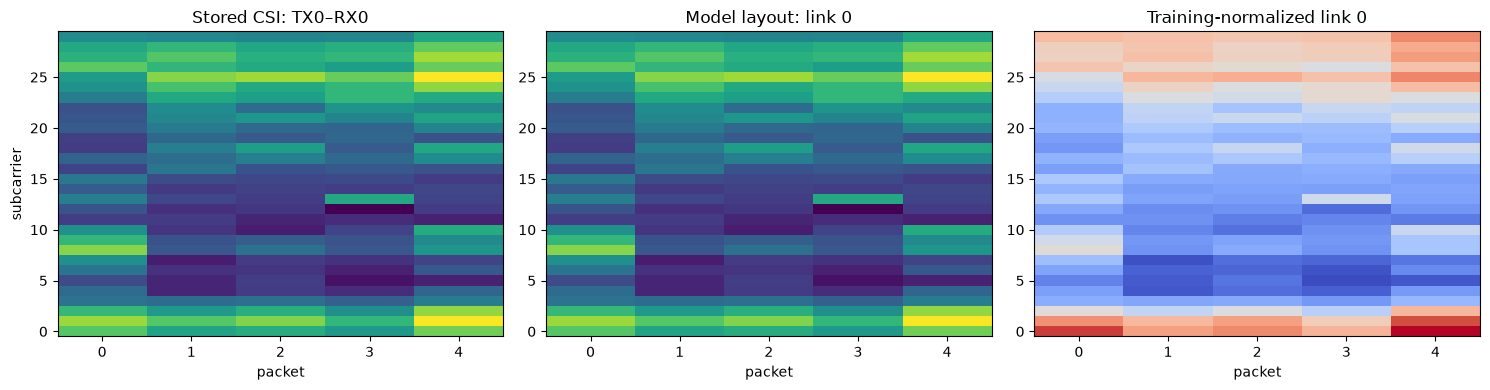

In [20]:
from shared.data.preprocessing import canonicalize_pose, csi_amplitude, reshape_csi_window
from shared.data.skeleton import WIPOSE_TO_BODY_14

# Load one processed sample and reproduce every model-facing transformation.
with (PROJECT_ROOT / 'data/manifests/wipose_split_v1.jsonl').open() as f:
    readiness_sample = json.loads(next(f))
with np.load(readiness_sample['processed_path'], allow_pickle=False) as z:
    raw_csi = z['csi']
    source_joints = z['joints_18_pixel']
    source_confidence = z['confidence_18']
    saved_target = z['joints']

# CSI: [packets, Tx, Rx, subcarriers] -> amplitude -> [links, packets, subcarriers].
model_csi = reshape_csi_window(csi_amplitude(raw_csi))
normalized_csi = (model_csi - csi_mean[:, None, :]) / csi_std[:, None, :]

# Pose: named AlphaPose-18 -> BODY-14 -> hip-centred, torso-normalized target.
indices = list(WIPOSE_TO_BODY_14)
body14_pixels = source_joints[indices]
body14_confidence = source_confidence[indices]
body14_target, torso_scale = canonicalize_pose(body14_pixels, body14_confidence)

assert model_csi.shape == normalized_csi.shape == (9, 5, 30)
assert body14_target.shape == saved_target.shape == (14, 2)
assert np.isfinite(normalized_csi).all() and np.allclose(body14_target, saved_target)
print({
    'sample': readiness_sample['sample_id'],
    'action': readiness_sample['activity'],
    'partition': readiness_sample['partition'],
    'raw_csi': raw_csi.shape,
    'model_csi': model_csi.shape,
    'source_pose': source_joints.shape,
    'training_pose': body14_target.shape,
    'torso_scale_px': float(torso_scale),
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
axes[0].imshow(raw_csi[:, 0, 0, :].T, aspect='auto', origin='lower')
axes[0].set(title='Stored CSI: TX0–RX0', xlabel='packet', ylabel='subcarrier')
axes[1].imshow(model_csi[0].T, aspect='auto', origin='lower')
axes[1].set(title='Model layout: link 0', xlabel='packet')
axes[2].imshow(normalized_csi[0].T, aspect='auto', origin='lower', cmap='coolwarm')
axes[2].set(title='Training-normalized link 0', xlabel='packet')
plt.tight_layout()
plt.show()

### 2.3 Named joint mapping and reusable dataset views

The source skeleton is retained as AlphaPose-18. The training target is selected by the explicit name-based BODY-14 mapping below; eye and ear joints remain available for audit plots. Partition-specific datasets inherit the shared manifest loader so preprocessing stays in one implementation.

In [21]:
from shared.data.skeleton import BODY_14_EDGES, BODY_14_JOINTS

pd.DataFrame({
    'target_index': range(len(BODY_14_JOINTS)),
    'target_joint': BODY_14_JOINTS,
    'alphapose_source_index': WIPOSE_TO_BODY_14,
})

,target_index,target_joint,alphapose_source_index
0,0,nose,0
1,1,neck,1
2,2,right_shoulder,2
3,3,right_elbow,3
4,4,right_wrist,4
5,5,left_shoulder,5
6,6,left_elbow,6
7,7,left_wrist,7
8,8,right_hip,8
9,9,right_knee,9


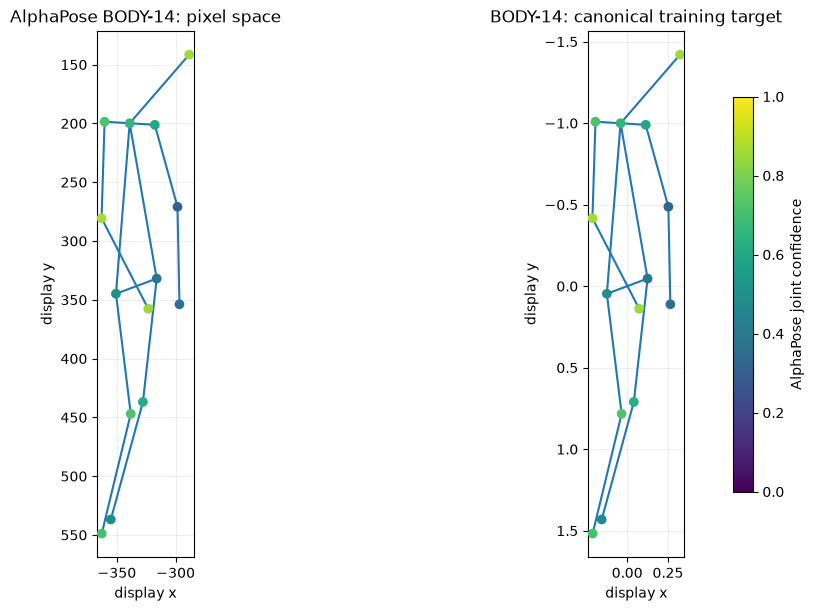

In [22]:
def display_pose(joints):
    # Rotate the released camera frame clockwise for an upright display only.
    return np.column_stack((-joints[:, 1], joints[:, 0]))

def draw_body14(ax, joints, title):
    joints = display_pose(joints)
    for start, end in BODY_14_EDGES:
        ax.plot(joints[[start, end], 0], joints[[start, end], 1], color='tab:blue')
    points = ax.scatter(joints[:, 0], joints[:, 1], c=body14_confidence, cmap='viridis', vmin=0, vmax=1, zorder=3)
    ax.set(title=title, aspect='equal', xlabel='display x', ylabel='display y')
    ax.invert_yaxis()
    ax.grid(alpha=.2)
    return points

fig, axes = plt.subplots(1, 2, figsize=(11, 6), constrained_layout=True)
points = draw_body14(axes[0], body14_pixels, 'AlphaPose BODY-14: pixel space')
draw_body14(axes[1], body14_target, 'BODY-14: canonical training target')
fig.colorbar(points, ax=axes, label='AlphaPose joint confidence', shrink=.75)
plt.show()

**How to read these graphs.** Blue lines connect anatomical neighbours in the BODY-14 skeleton. Marker colour encodes the original AlphaPose confidence: dark purple is low confidence and yellow is high confidence, as shown by the shared colour bar. The left graph retains camera pixel position and scale; the right graph subtracts the hip midpoint and divides by torso length, which is the target supplied to the model. Both graphs are rotated clockwise only for an upright human-readable display—the stored coordinates and training target are unchanged.

In [23]:
from shared.data.datasets import ManifestPoseDataset, load_manifest
from shared.data.preprocessing import CSINormalizer

normalizer = CSINormalizer(csi_mean, csi_std)
split_manifest = PROJECT_ROOT / 'data/manifests/wipose_split_v1.jsonl'
split_records = load_manifest(split_manifest)

class WiPosePartition(ManifestPoseDataset):
    def __init__(self, partition):
        records = [row for row in split_records if row['partition'] == partition]
        if not records:
            raise ValueError(f'No samples in {partition!r}')
        super().__init__(records, normalizer.transform)
        self.partition = partition

datasets = {name: WiPosePartition(name) for name in ('train', 'monitor', 'test')}
dataset_sizes = {name: len(data) for name, data in datasets.items()}
assert dataset_sizes == split_info['sample_counts']
dataset_sizes

{'train': 132786, 'monitor': 16169, 'test': 17645}

In [24]:
import torch
from torch.utils.data import DataLoader

batch = next(iter(DataLoader(datasets['train'], batch_size=32, shuffle=True, num_workers=0)))
assert batch['csi'].shape == (32, 9, 5, 30)
assert batch['joints'].shape == (32, 14, 2)
assert batch['confidence'].shape == (32, 14)
assert torch.isfinite(batch['csi']).all() and torch.isfinite(batch['joints']).all()
{key: tuple(value.shape) for key, value in batch.items() if isinstance(value, torch.Tensor)}

{'csi': (32, 9, 5, 30), 'joints': (32, 14, 2), 'confidence': (32, 14)}

In [25]:
# Exact backend preprocessing code used by this notebook.
display(Code(inspect.getsource(preprocessing), language='python'))
display(Code(inspect.getsource(preprocess_wipose), language='python'))
display(Code(inspect.getsource(prepare_readiness), language='python'))

from __future__ import annotations

from dataclasses import dataclass

import numpy as np


def csi_amplitude(csi: np.ndarray) -> np.ndarray:
    """Convert complex CSI to float32 amplitude without changing axes."""
    return np.abs(csi).astype(np.float32, copy=False)


def reshape_csi_window(csi: np.ndarray) -> np.ndarray:
    """Convert either observed Wi-Pose layout into [links, time, subcarrier]."""
    if csi.shape == (5, 3, 3, 30):
        return csi.transpose(1, 2, 0, 3).reshape(9, 5, 30).astype(np.float32)
    if csi.shape == (5, 30, 3, 3):
        return csi.transpose(2, 3, 0, 1).reshape(9, 5, 30).astype(np.float32)
    raise ValueError(f"Expected CSI shape (5, 3, 3, 30) or (5, 30, 3, 3), received {csi.shape}")


@dataclass(frozen=True)
class CSINormalizer:
    mean: np.ndarray
    std: np.ndarray

    @classmethod
    def fit(cls, training_samples: np.ndarray, epsilon: float = 1e-6) -> "CSINormalizer":
        if training_samples.ndim != 4 or training_samples.shape[1:] != (9, 5, 30):
            raise ValueError("Expected training samples shaped [N, 9, 5, 30]")
        mean = training_samples.mean(axis=(0, 2))
        std = training_samples.std(axis=(0, 2))
        return cls(mean.astype(np.float32), np.maximum(std, epsilon).astype(np.float32))

    def transform(self, sample: np.ndarray) -> np.ndarray:
        return ((sample - self.mean[:, None, :]) / self.std[:, None, :]).astype(np.float32)


def canonicalize_pose(joints: np.ndarray, confidence: np.ndarray | None = None) -> tuple[np.ndarray, float]:
    """Hip-centre and torso-normalize a BODY_14 pose.

    Returns canonical coordinates and the original torso scale. Index 1 is neck;
    indices 8 and 11 are right and left hips.
    """
    joints = np.asarray(joints, dtype=np.float32)
    if joints.shape != (14, 2):
        raise ValueError(f"Expected joints shape (14, 2), received {joints.shape}")
    if confidence is not None and np.asarray(confidence).shape != (14,):
        raise ValueError("Confidence must have shape (14,)")
    hip_midpoint = (joints[8] + joints[11]) * 0.5
    torso = float(np.linalg.norm(joints[1] - hip_midpoint))
    if not np.isfinite(torso) or torso < 1e-6:
        raise ValueError("Cannot canonicalize a pose with zero or invalid torso length")
    return ((joints - hip_midpoint) / torso).astype(np.float32), torso

"""Convert Wi-Pose MATLAB files to traceable NumPy shards and a processed manifest.

The raw AlphaPose layout is retained as 18 named joints.  The 14-joint training
target is selected through a named mapping, never through a paper-figure index.
"""
from pathlib import Path
import argparse
import json, re
import h5py
import numpy as np
from shared.data.skeleton import WIPOSE_TO_BODY_14

ROOT = Path(__file__).resolve().parents[2]
SRC = ROOT / 'data/extracted/wipose/Wi-Pose'
OUT = ROOT / 'data/processed/wipose'

def _is_current(path: Path) -> bool:
    """Return whether an existing shard satisfies the current output contract."""
    if not path.exists():
        return False
    try:
        with np.load(path, allow_pickle=False) as payload:
            return {
                'csi', 'joints', 'joints_pixel', 'confidence', 'joints_18_pixel',
                'confidence_18', 'joint_source_indices',
            }.issubset(payload.files)
    except (OSError, ValueError):
        return False


def main(*, resume: bool = True, limit: int | None = None):
    OUT.mkdir(parents=True, exist_ok=True)
    rows = []
    written = reused = 0
    for split in ('Train', 'Test'):
        for src in sorted((SRC / split).glob('*.mat')):
            if limit is not None and written + reused >= limit:
                break
            out = OUT / split / (src.stem + '.npz')
            activity = re.match(r'(.+?)_\d+-frame\d+', src.stem)
            row = {'sample_id': src.stem, 'processed_path': str(out),
                   'source_path': str(src), 'participant': src.stem.split('_')[-1].split('-')[0],
                   'activity': activity.group(1) if activity else 'unknown', 'split': split,
                   'pose_source': 'AlphaPose_18',
                   'target_joint_source_indices': list(WIPOSE_TO_BODY_14),
                   'csi_shape': [5, 3, 3, 30], 'target_shape': [14, 2]}
            if resume and _is_current(out):
                reused += 1
                rows.append(row)
                continue
            with h5py.File(src, 'r') as f:
                csi = np.asarray(f['CSI'][()], dtype=np.float32).transpose(3, 0, 1, 2)
                points = np.asarray(f['SkeletonPoints'][()], dtype=np.float32).reshape(3, 18)
            # Wi-Pose AlphaPose/OpenPose layout: 18 x coordinates, 18 y coordinates,
            # then 18 confidences.  Camera rotation is a visualization concern only.
            joints_18_pixel = points[:2, :].T.copy()
            confidence_18 = points[2, :].copy()
            joints_pixel = joints_18_pixel[list(WIPOSE_TO_BODY_14)].copy()
            confidence = confidence_18[list(WIPOSE_TO_BODY_14)].copy()
            hip_midpoint = (joints_pixel[8] + joints_pixel[11]) * 0.5
            torso = max(float(np.linalg.norm(joints_pixel[1] - hip_midpoint)), 1.0)
            joints = ((joints_pixel - hip_midpoint) / torso).astype(np.float32)
            out.parent.mkdir(parents=True, exist_ok=True)
            temporary = out.with_suffix('.tmp.npz')
            np.savez_compressed(
                temporary, csi=csi, joints=joints, joints_pixel=joints_pixel,
                confidence=confidence, joints_18_pixel=joints_18_pixel,
                confidence_18=confidence_18,
                joint_source_indices=np.asarray(WIPOSE_TO_BODY_14, dtype=np.int16),
            )
            temporary.replace(out)
            written += 1
            row['csi_shape'] = list(csi.shape)
            rows.append(row)
            if (written + reused) % 1000 == 0:
                print(f'progress: {written + reused} checked; {written} rebuilt; {reused} reused', flush=True)
        if limit is not None and written + reused >= limit:
            break
    manifest = ROOT / 'data/manifests/wipose_processed.jsonl'
    temporary_manifest = manifest.with_suffix('.tmp.jsonl')
    with temporary_manifest.open('w') as f:
        for row in rows: f.write(json.dumps(row) + '\n')
    temporary_manifest.replace(manifest)
    print(f'processed {l

"""Create leakage-safe split, normalization, and WiMANS readiness artefacts."""
from __future__ import annotations

from collections import Counter
import csv
import hashlib
import json
from pathlib import Path

import numpy as np

from .preprocessing import csi_amplitude, reshape_csi_window
from .splits import grouped_split

ROOT = Path(__file__).resolve().parents[2]
MANIFESTS = ROOT / "data/manifests"


def read_jsonl(path: Path) -> list[dict]:
    return [json.loads(line) for line in path.open(encoding="utf-8") if line.strip()]


def write_json(path: Path, value: object) -> None:
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, indent=2) + "\n", encoding="utf-8")
    temporary.replace(path)


def write_jsonl(path: Path, rows: list[dict]) -> None:
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("w", encoding="utf-8") as handle:
        for row in rows:
            handle.write(json.dumps(row, separators=(",", ":")) + "\n")
    temporary.replace(path)


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def build_wipose_split() -> tuple[list[dict], dict]:
    rows = read_jsonl(MANIFESTS / "wipose_processed.jsonl")
    split = grouped_split([row["participant"] for row in rows], seed=31050)
    membership = {
        **{group: "train" for group in split.train_groups},
        **{group: "monitor" for group in split.monitor_groups},
        **{group: "test" for group in split.test_groups},
    }
    output = [{**row, "csi_path": row["processed_path"], "partition": membership[row["participant"]]} for row in rows]
    groups = {name: sorted(group for group, part in membership.items() if part == name) for name in ("train", "monitor", "test")}
    assert not (set(groups["train"]) & set(groups["monitor"]) | set(groups["train"]) & set(groups["test"]) | set(groups["monitor"]) & set(groups["test"]))
    summary = {
        "seed": 31050, "group_field": "participant", "requested_ratios": [0.8, 0.1, 0.1],
        "groups": groups,
        "sample_counts": Counter(row["partition"] for row in output),
        "action_counts": {part: Counter(row["activity"] for row in output if row["partition"] == part) for part in groups},
    }
    return output, summary


def build_wimans_partitions() -> tuple[list[dict], dict]:
    source = ROOT / "data/extracted/wimans"
    rows = []
    with (source / "annotation.csv").open(encoding="utf-8-sig", newline="") as handle:
        for row in csv.DictReader(handle):
            if float(row["wifi_band"]) != 5.0 or int(row["number_of_users"]) != 1:
                continue
            role = "zero_shot_test" if row["environment"] == "empty_room" else "ssl_train"
            path = source / "wifi_csi/amp" / f'{row["label"]}.npy'
            if not path.exists():
                raise FileNotFoundError(path)
            user = next(i for i in range(1, 7) if row[f"user_{i}_activity"])
            rows.append({
                "sample_id": row["label"], "csi_path": str(path), "partition": role,
                "environment": row["environment"], "wifi_band": 5.0, "number_of_users": 1,
                "user_slot": user, "location": row[f"user_{user}_location"],
                "activity": row[f"user_{user}_activity"],
                "pose_labels_available": False,
            })
    summary = {
        "selection": {"wifi_band": 5.0, "number_of_users": 1},
        "partition_counts": Counter(row["partition"] for row in rows),
        "environment_counts": Counter(row["environment"] for row in rows),
        "activity_counts": Counter(row["activity"] for row in rows),
    }
    assert {row["environment"] for row in rows if row["partition"] == "zero_shot_test"} == {"empty_room"}
    assert all(row["activity"] and row["location"] for row in rows)
    assert not {row

### 2.4 Preprocessing decisions and checks

The normalizer is fitted only on the training partition. Complete groups remain disjoint across train, monitor, and test. No long-window filtering is applied independently to five-packet samples because that would be unsupported by the available temporal context. Every accepted tensor must have shape `[9,5,30]` and finite values. The raw 18-joint pose, confidence, canonical target, source path, group, activity, and frame provenance are retained.

### 2.5 Preprocessed Wi-Pose output

The panels below show one labelled source sample after the declared model-input transformation. Viridis colour encodes CSI amplitude or AlphaPose confidence; the diverging blue–white–red scale encodes standardized values around zero. Blue lines connect BODY-14 anatomical neighbours. The display rotation affects only the plot.

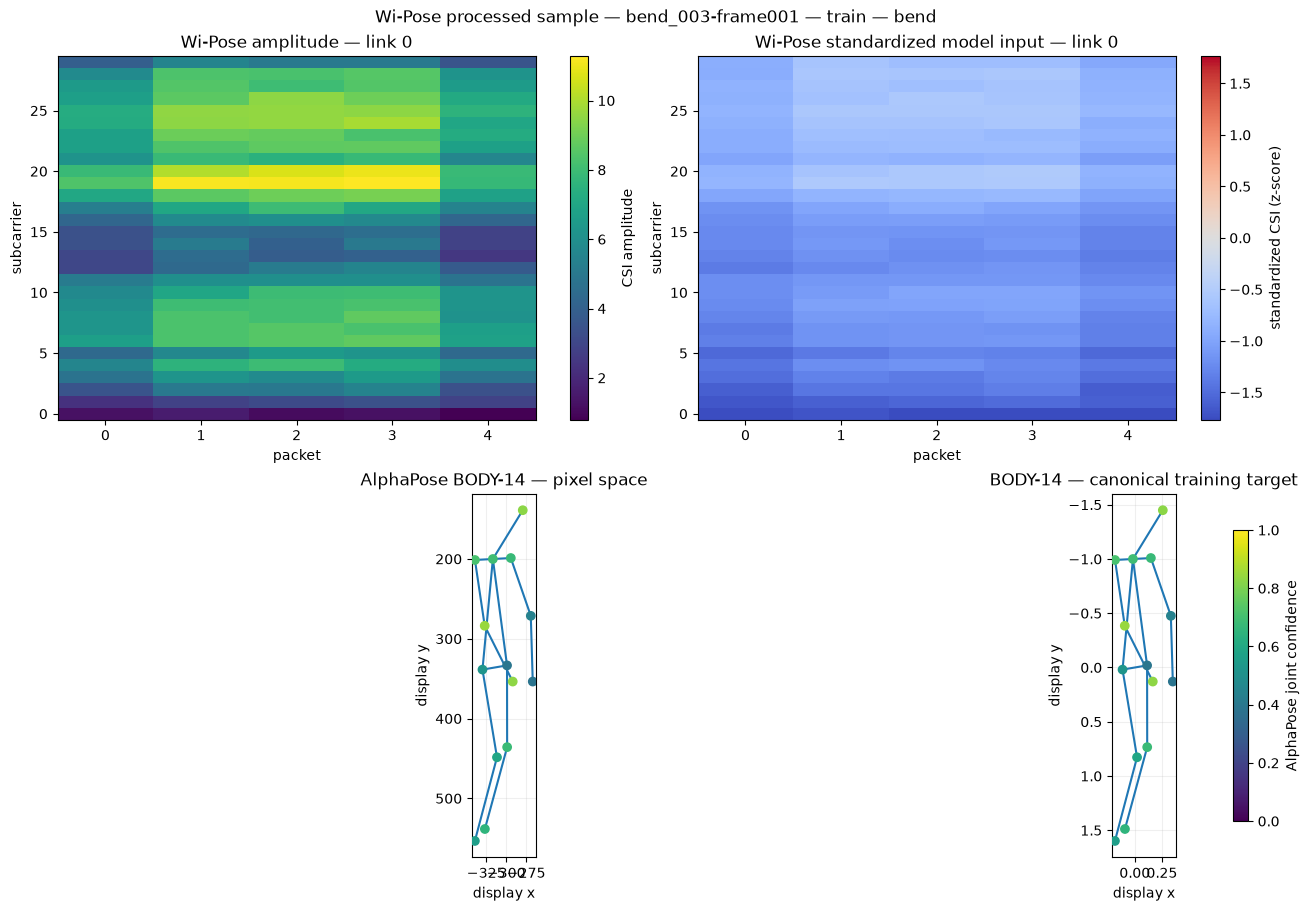

In [26]:
train_row = next(row for row in split_records if row['partition'] == 'train')
with np.load(train_row['processed_path'], allow_pickle=False) as z:
    wp_csi = reshape_csi_window(csi_amplitude(z['csi']))
    wp_norm = normalizer.transform(wp_csi)
    wp_pixel = z['joints_pixel']
    wp_target = z['joints']
    wp_conf = z['confidence']
assert wp_csi.shape == wp_norm.shape == (9,5,30) and wp_target.shape == (14,2)

def upright(joints): return np.column_stack((-joints[:,1], joints[:,0]))
def pose_panel(ax, joints, title):
    shown = upright(joints)
    for a, b in BODY_14_EDGES: ax.plot(shown[[a,b],0], shown[[a,b],1], color='tab:blue')
    points = ax.scatter(shown[:,0], shown[:,1], c=wp_conf, cmap='viridis', vmin=0, vmax=1, zorder=3)
    ax.set(title=title, xlabel='display x', ylabel='display y', aspect='equal'); ax.invert_yaxis(); ax.grid(alpha=.2)
    return points

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
raw = axes[0,0].imshow(wp_csi[0].T, aspect='auto', origin='lower', cmap='viridis')
axes[0,0].set(title='Wi-Pose amplitude — link 0', xlabel='packet', ylabel='subcarrier')
fig.colorbar(raw, ax=axes[0,0], label='CSI amplitude')
limit = max(1., float(np.percentile(np.abs(wp_norm[0]), 99)))
norm = axes[0,1].imshow(wp_norm[0].T, aspect='auto', origin='lower', cmap='coolwarm', vmin=-limit, vmax=limit)
axes[0,1].set(title='Wi-Pose standardized model input — link 0', xlabel='packet', ylabel='subcarrier')
fig.colorbar(norm, ax=axes[0,1], label='standardized CSI (z-score)')
points = pose_panel(axes[1,0], wp_pixel, 'AlphaPose BODY-14 — pixel space')
pose_panel(axes[1,1], wp_target, 'BODY-14 — canonical training target')
fig.colorbar(points, ax=axes[1,:], label='AlphaPose joint confidence', shrink=.8)
fig.suptitle(f"Wi-Pose processed sample — {train_row['sample_id']} — train — {train_row['activity']}")
plt.show()

### 2.6 Preprocessed WiMANS output

WiMANS recordings are variable-length native amplitude arrays. This example takes the first five packets from one permitted SSL recording, rearranges the nine antenna links to `[9,5,30]`, and applies the frozen Wi-Pose-training normalizer. Viridis encodes amplitude; blue–white–red encodes standardized values around zero. There is deliberately no skeleton panel because WiMANS supplies no native pose target.

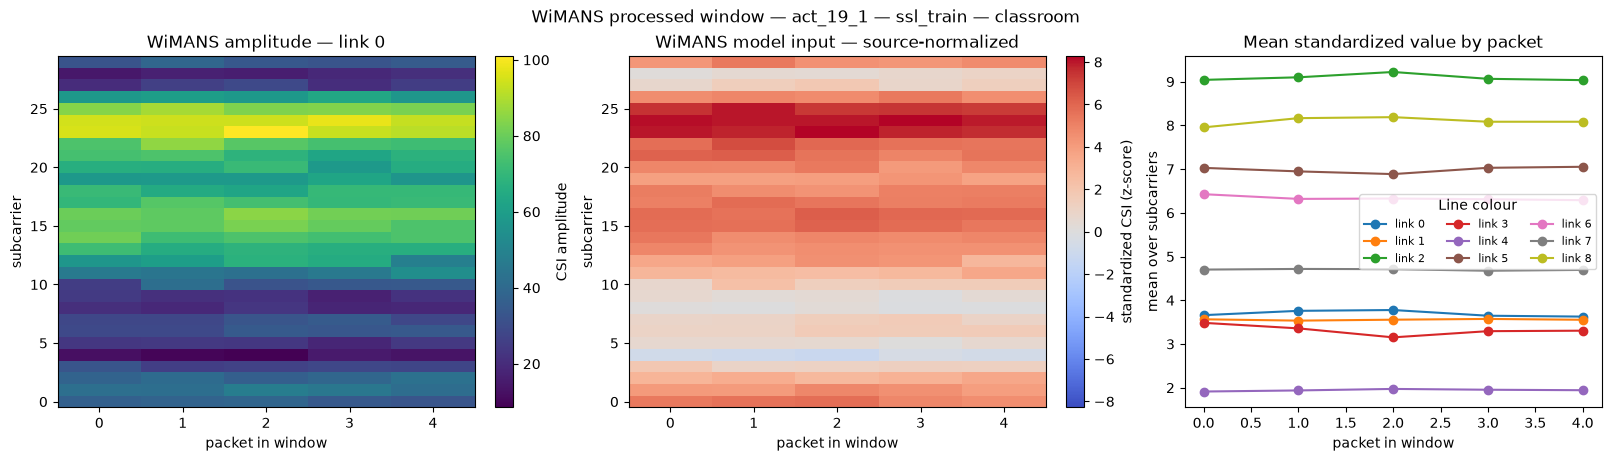

recording shape          (2825, 3, 3, 30)
window shape                (5, 3, 3, 30)
model shape                    (9, 5, 30)
activity metadata                 nothing
pose target available               False
dtype: object

In [27]:
wimans_manifest = PROJECT_ROOT / 'data/manifests/wimans_partitions_v1.jsonl'
wimans_rows = [json.loads(line) for line in wimans_manifest.open() if line.strip()]
wm_row = next(row for row in wimans_rows if row['partition'] == 'ssl_train')
wm_recording = np.load(wm_row['csi_path'], mmap_mode='r')
wm_window = np.asarray(wm_recording[:5], dtype=np.float32)
wm_csi = reshape_csi_window(csi_amplitude(wm_window))
wm_norm = normalizer.transform(wm_csi)
assert wm_csi.shape == wm_norm.shape == (9,5,30) and np.isfinite(wm_norm).all()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
raw = axes[0].imshow(wm_csi[0].T, aspect='auto', origin='lower', cmap='viridis')
axes[0].set(title='WiMANS amplitude — link 0', xlabel='packet in window', ylabel='subcarrier')
fig.colorbar(raw, ax=axes[0], label='CSI amplitude')
limit = max(1., float(np.percentile(np.abs(wm_norm[0]), 99)))
norm = axes[1].imshow(wm_norm[0].T, aspect='auto', origin='lower', cmap='coolwarm', vmin=-limit, vmax=limit)
axes[1].set(title='WiMANS model input — source-normalized', xlabel='packet in window', ylabel='subcarrier')
fig.colorbar(norm, ax=axes[1], label='standardized CSI (z-score)')
for link in range(9): axes[2].plot(wm_norm[link].mean(axis=1), marker='o', label=f'link {link}')
axes[2].set(title='Mean standardized value by packet', xlabel='packet in window', ylabel='mean over subcarriers')
axes[2].legend(ncol=3, fontsize=8, title='Line colour')
fig.suptitle(f"WiMANS processed window — {wm_row['sample_id']} — {wm_row['partition']} — {wm_row['environment']}")
plt.show()
pd.Series({'recording shape': str(wm_recording.shape), 'window shape': str(wm_window.shape),
           'model shape': str(wm_csi.shape), 'activity metadata': wm_row['activity'],
           'pose target available': wm_row['pose_labels_available']})

## 3. Model, hypothesis family, and theory-to-code mapping

The supervised hypothesis is $f_\theta:\mathbb{R}^{9\times5\times30}\rightarrow\mathbb{R}^{14\times2}$. This section prepares data loaders, models, objectives, optimizers, and optional trained-model loading. It performs no epoch training and writes no checkpoint; those condition-specific operations remain in Sections 4 and 5.

### 3.1 Configuration and independent restart

Run the next cell first after restarting the kernel. It resolves both condition configurations and verifies the frozen preprocessing artefacts without depending on Sections 1 or 2.

In [28]:
# Section 3 restart cell
from pathlib import Path
import hashlib, inspect, json, random, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Code, display

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'environment.yml').exists()), None)
assert PROJECT_ROOT is not None, 'Open the repository first.'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

from conditions.ssl_domain_adapted.models import DomainAdaptedPoseModel
from shared.data.datasets import load_manifest
from shared.data.preprocessing import CSINormalizer
from shared.data.skeleton import BODY_14_EDGES
from shared.evaluation.metrics import pose_metrics
from shared.models import MaskedCSIAutoencoder, PoseCNN, ResidualBlock
from shared.training import (SkeletonAwareLoss, build_source_components,
    build_ssl_components, build_wipose_loaders, load_trained_model)
from shared.training import setup as model_setup
from shared.utils import deep_merge, load_yaml

SEED = 31050
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
base_config = load_yaml(PROJECT_ROOT / 'shared/configs/base.yaml')
source_config = deep_merge(base_config, load_yaml(PROJECT_ROOT / 'conditions/source_only_zero_shot/configs/condition.yaml'))
ssl_config = deep_merge(base_config, load_yaml(PROJECT_ROOT / 'conditions/ssl_domain_adapted/configs/condition.yaml'))
split_path = PROJECT_ROOT / 'data/manifests/wipose_split_v1.jsonl'
normalizer_path = PROJECT_ROOT / 'data/processed/normalization_wipose_train_v1.npz'
assert split_path.exists() and normalizer_path.exists(), 'Complete preprocessing before modeling.'
with np.load(normalizer_path, allow_pickle=False) as z:
    normalizer = CSINormalizer(z['mean'], z['std'])
    split_checksum = str(z['split_manifest_sha256'])
normalizer_checksum = hashlib.sha256(normalizer_path.read_bytes()).hexdigest()
assert normalizer.mean.shape == normalizer.std.shape == (9, 30)

training_settings = pd.DataFrame({
    'source-only': {**source_config['training'], **source_config['loss']},
    'SSL-adapted': {**ssl_config['training'], **ssl_config['loss'],
                    'pretraining_epochs': ssl_config['pretraining']['epochs'],
                    'mask_ratio': ssl_config['pretraining']['mask_ratio']},
})
print('Inspection device:', device)
display(training_settings)

Inspection device: cuda:0


,source-only,SSL-adapted
epochs,100,100
learning_rate,0.001,0.001
weight_decay,0.0001,0.0001
early_stopping_patience,15,15
precision,auto,auto
auto_batch_size,True,True
batch_multiple,8,8
memory_reserve_gib,2.0,2.0
memory_reserve_fraction,0.1,0.1
num_workers,auto,auto


### 3.2 Wi-Pose DataLoaders

Section 3 uses batch size 32 and zero workers only for interactive inspection. The training loader shuffles deterministically; monitor and test loaders preserve manifest order. The final-test loader is prepared but must not be consumed for checkpoint selection.

In [29]:
PREVIEW_BATCH = 32
loaders = build_wipose_loaders(PROJECT_ROOT, normalizer.transform, preview_batch=PREVIEW_BATCH, num_workers=0)
records = load_manifest(split_path)
preview = next(iter(loaders['train']))
assert preview['csi'].shape == (PREVIEW_BATCH, 9, 5, 30)
assert preview['joints'].shape == (PREVIEW_BATCH, 14, 2)
assert preview['confidence'].shape == (PREVIEW_BATCH, 14)
assert torch.isfinite(preview['csi']).all() and torch.isfinite(preview['joints']).all()

loader_summary = pd.DataFrame({
    part: {'samples': len(loader.dataset),
           'groups': len({row['participant'] for row in records if row['partition'] == part}),
           'batches_at_32': len(loader), 'shuffled': part == 'train'}
    for part, loader in loaders.items()
}).T
display(loader_summary)
display(pd.DataFrame([
    {'tensor': 'csi', 'dtype': str(preview['csi'].dtype), 'shape': str(tuple(preview['csi'].shape)), 'meaning': 'normalized links × packets × subcarriers'},
    {'tensor': 'joints', 'dtype': str(preview['joints'].dtype), 'shape': str(tuple(preview['joints'].shape)), 'meaning': 'canonical BODY-14 coordinates'},
    {'tensor': 'confidence', 'dtype': str(preview['confidence'].dtype), 'shape': str(tuple(preview['confidence'].shape)), 'meaning': 'AlphaPose label reliability'},
]))

,samples,groups,batches_at_32,shuffled
train,132786,96,4150,True
monitor,16169,12,506,False
test,17645,12,552,False


,tensor,dtype,shape,meaning
0,csi,torch.float32,"(32, 9, 5, 30)",normalized links × packets × subcarriers
1,joints,torch.float32,"(32, 14, 2)",canonical BODY-14 coordinates
2,confidence,torch.float32,"(32, 14)",AlphaPose label reliability


### 3.3 Data-to-model alignment

The left panel is exactly one normalized model input link. Blue–white–red encodes negative, zero, and positive z-scores. The right panel is the corresponding BODY-14 target; blue lines are anatomical edges and viridis marker colour is AlphaPose confidence.

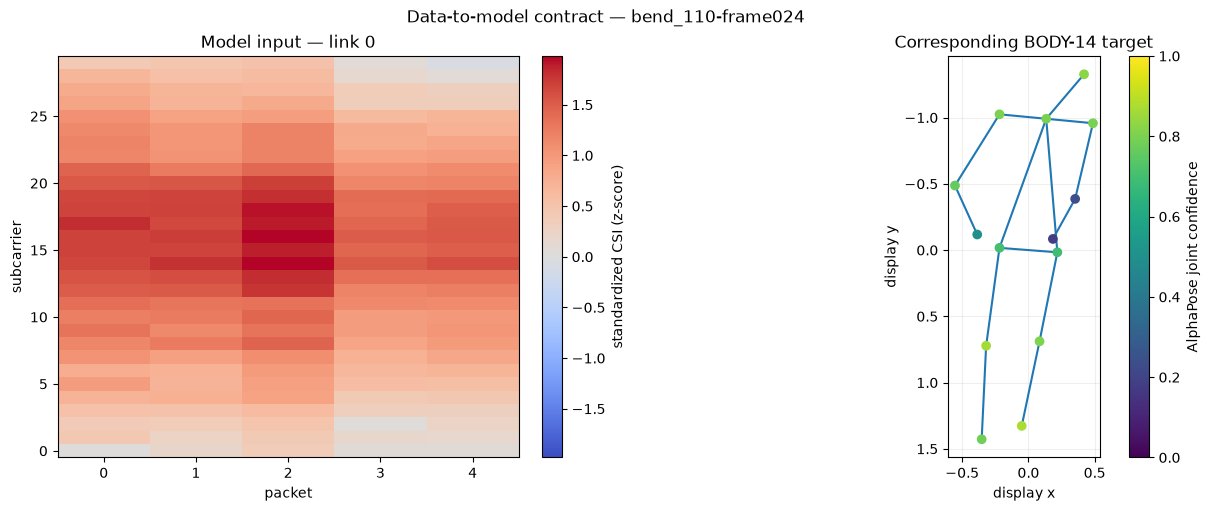

In [30]:
sample_csi = preview['csi'][0].numpy()
sample_pose = preview['joints'][0].numpy()
sample_confidence = preview['confidence'][0].numpy()
shown_pose = np.column_stack((-sample_pose[:,1], sample_pose[:,0]))
limit = max(1., float(np.percentile(np.abs(sample_csi[0]), 99)))
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
image = axes[0].imshow(sample_csi[0].T, origin='lower', aspect='auto', cmap='coolwarm', vmin=-limit, vmax=limit)
axes[0].set(title='Model input — link 0', xlabel='packet', ylabel='subcarrier')
fig.colorbar(image, ax=axes[0], label='standardized CSI (z-score)')
for a, b in BODY_14_EDGES: axes[1].plot(shown_pose[[a,b],0], shown_pose[[a,b],1], color='tab:blue')
points = axes[1].scatter(shown_pose[:,0], shown_pose[:,1], c=sample_confidence, cmap='viridis', vmin=0, vmax=1, zorder=3)
axes[1].set(title='Corresponding BODY-14 target', xlabel='display x', ylabel='display y', aspect='equal')
axes[1].invert_yaxis(); axes[1].grid(alpha=.2)
fig.colorbar(points, ax=axes[1], label='AlphaPose joint confidence')
fig.suptitle(f"Data-to-model contract — {preview['sample_id'][0]}")
plt.show()

### 3.4 Supervised PoseCNN

This project-designed baseline treats nine antenna links as channels, preserves all five packet positions, and downsamples only the subcarrier axis. Adaptive pooling produces a fixed representation and the head emits 28 values reshaped to fourteen 2D joints. It is not a reproduction of CSI-Former.

In [31]:
source_model, source_criterion, source_optimizer = build_source_components(source_config)
source_model = source_model.to(device)
layer_shapes, hooks = [], []
for index, block in enumerate(source_model.encoder):
    hooks.append(block.register_forward_hook(lambda module, inputs, output, i=index: layer_shapes.append((f'encoder.{i}', tuple(output.shape)))))
hooks.append(source_model.head.register_forward_hook(lambda module, inputs, output: layer_shapes.append(('head', tuple(output.shape)))))
with torch.no_grad(): source_prediction = source_model(preview['csi'].to(device))
for hook in hooks: hook.remove()
assert source_prediction.shape == (PREVIEW_BATCH, 14, 2)
display(pd.DataFrame(layer_shapes, columns=['stage', 'output shape']))
print(source_model)
print('Trainable parameters:', sum(p.numel() for p in source_model.parameters() if p.requires_grad))
print('Input -> output:', tuple(preview['csi'].shape), '->', tuple(source_prediction.shape))

,stage,output shape
0,encoder.0,"(32, 32, 5, 30)"
1,encoder.1,"(32, 64, 5, 15)"
2,encoder.2,"(32, 128, 5, 8)"
3,encoder.3,"(32, 192, 5, 4)"
4,head,"(32, 28)"


SourceOnlyPoseModel(
  (encoder): Sequential(
    (0): ResidualBlock(
      (main): Sequential(
        (0): Conv2d(9, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): GELU(approximate='none')
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (skip): Sequential(
        (0): Conv2d(9, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (activation): GELU(approximate='none')
    )
    (1): ResidualBlock(
      (main): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

In [32]:
display(Code(inspect.getsource(ResidualBlock), language='python'))
display(Code(inspect.getsource(PoseCNN), language='python'))

class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: tuple[int, int] = (1, 1)) -> None:
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels), nn.GELU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.skip = (
            nn.Identity() if in_channels == out_channels and stride == (1, 1)
            else nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        )
        self.activation = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.activation(self.main(x) + self.skip(x))

class PoseCNN(nn.Module):
    def __init__(self, channels: tuple[int, ...] = (32, 64, 128, 192), num_joints: int = 14, dropout: float = 0.2) -> None:
        super().__init__()
        blocks: list[nn.Module] = []
        in_channels = 9
        for index, out_channels in enumerate(channels):
            stride = (1, 1) if index == 0 else (1, 2)
            blocks.append(ResidualBlock(in_channels, out_channels, stride))
            in_channels = out_channels
        self.encoder = nn.Sequential(*blocks)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout),
            nn.Linear(channels[-1], channels[-1]), nn.GELU(),
            nn.Linear(channels[-1], num_joints * 2),
        )
        self.num_joints = num_joints

    def forward(self, csi: torch.Tensor) -> torch.Tensor:
        if csi.ndim != 4 or tuple(csi.shape[1:]) != (9, 5, 30):
            raise ValueError(f"Expected [B, 9, 5, 30], received {tuple(csi.shape)}")
        return self.head(self.encoder(csi)).reshape(csi.shape[0], self.num_joints, 2)

### 3.5 SSL and domain-adapted architectures

The autoencoder masks 30% of packet/subcarrier positions and reconstructs the complete CSI tensor. Marker/heatmap colour below is numeric: viridis is normalized input/reconstruction, while white means visible and black means masked. The current SSL encoder has three non-downsampling blocks; PoseCNN has four blocks with frequency downsampling, so complete encoder transfer must not be claimed until Section 5 resolves that mismatch.

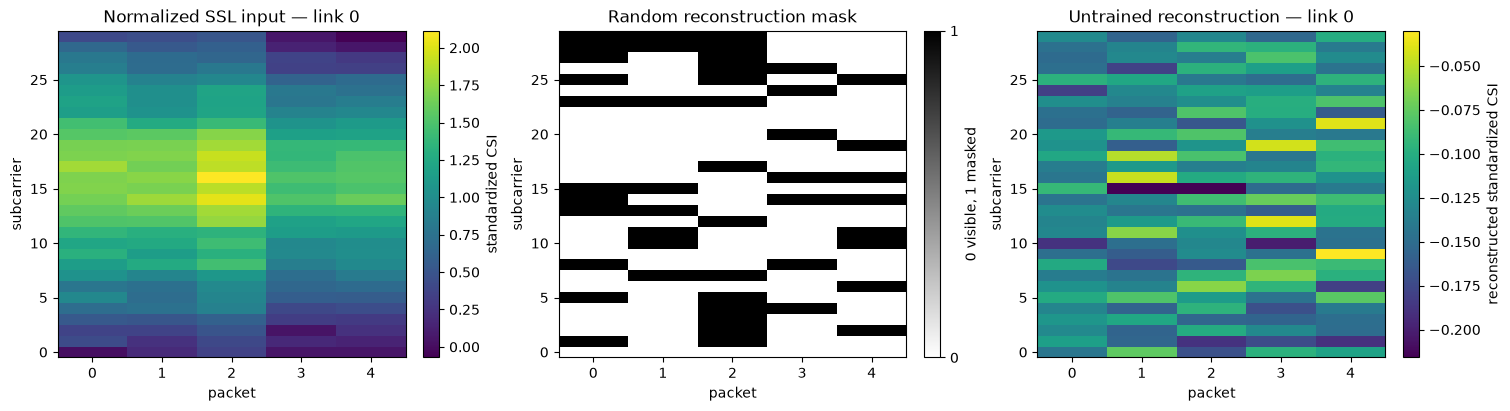

Autoencoder: (4, 9, 5, 30) -> (4, 9, 5, 30)
Domain-adapted pose model output: (4, 14, 2)


In [33]:
ssl_pretrainer, adapted_model, adapted_criterion, ssl_optimizer, adapted_optimizer = build_ssl_components(ssl_config)
ssl_pretrainer = ssl_pretrainer.to(device)
adapted_model = adapted_model.to(device)
ssl_input = preview['csi'][:4].to(device)
with torch.no_grad(): reconstruction, mask = ssl_pretrainer(ssl_input, ssl_config['pretraining']['mask_ratio'])
assert reconstruction.shape == ssl_input.shape and mask.shape == (4,1,5,30)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
original = axes[0].imshow(ssl_input[0,0].cpu().T, origin='lower', aspect='auto', cmap='viridis')
axes[0].set(title='Normalized SSL input — link 0', xlabel='packet', ylabel='subcarrier')
fig.colorbar(original, ax=axes[0], label='standardized CSI')
masked = axes[1].imshow(mask[0,0].cpu().T, origin='lower', aspect='auto', cmap='gray_r', vmin=0, vmax=1)
axes[1].set(title='Random reconstruction mask', xlabel='packet', ylabel='subcarrier')
fig.colorbar(masked, ax=axes[1], ticks=[0,1], label='0 visible, 1 masked')
recon = axes[2].imshow(reconstruction[0,0].cpu().T, origin='lower', aspect='auto', cmap='viridis')
axes[2].set(title='Untrained reconstruction — link 0', xlabel='packet', ylabel='subcarrier')
fig.colorbar(recon, ax=axes[2], label='reconstructed standardized CSI')
plt.show()
print('Autoencoder:', tuple(ssl_input.shape), '->', tuple(reconstruction.shape))
print('Domain-adapted pose model output:', tuple(adapted_model(ssl_input).shape))

In [34]:
display(Code(inspect.getsource(MaskedCSIAutoencoder), language='python'))
display(Code(inspect.getsource(DomainAdaptedPoseModel), language='python'))

class MaskedCSIAutoencoder(nn.Module):
    """Compact masked-reconstruction pretrainer for common CSI tensors."""

    def __init__(self, latent_channels: int = 128) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            ResidualBlock(9, 32), ResidualBlock(32, 64), ResidualBlock(64, latent_channels),
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(latent_channels, 64, 3, padding=1), nn.GELU(),
            nn.Conv2d(64, 32, 3, padding=1), nn.GELU(), nn.Conv2d(32, 9, 1),
        )

    @staticmethod
    def make_mask(x: torch.Tensor, ratio: float = 0.30) -> torch.Tensor:
        if not 0.0 < ratio < 1.0:
            raise ValueError("Mask ratio must be between zero and one")
        return torch.rand_like(x[:, :1]) < ratio

    def forward(self, x: torch.Tensor, mask_ratio: float = 0.30) -> tuple[torch.Tensor, torch.Tensor]:
        mask = self.make_mask(x, mask_ratio)
        encoded = self.encoder(x.masked_fill(mask, 0.0))
        return self.decoder(encoded), mask

class DomainAdaptedPoseModel(PoseCNN):
    """PoseCNN whose compatible encoder weights may come from masked pretraining."""

    def load_pretrained_encoder(self, checkpoint: str | Path) -> None:
        payload = torch.load(checkpoint, map_location="cpu", weights_only=True)
        state = payload.get("encoder", payload)
        missing, unexpected = self.encoder.load_state_dict(state, strict=False)
        if unexpected:
            raise ValueError(f"Unexpected pretrained encoder keys: {unexpected}")
        if len(missing) == len(self.encoder.state_dict()):
            raise ValueError("No compatible pretrained encoder parameters were loaded")

### 3.6 Supervised loss, metrics, and optimizer initialization

Let $\hat{\mathbf y}_{n,j}\in\mathbb R^2$ and $\mathbf y_{n,j}\in\mathbb R^2$ denote the predicted and target coordinates for joint $j$ in sample $n$, and let $c_{n,j}\geq0$ denote AlphaPose confidence. PyTorch's default Smooth-L1 function is

$$h(r)=\begin{cases}\tfrac12r^2,&|r|<1,\\|r|-\tfrac12,&|r|\geq1.\end{cases}$$

The confidence-weighted coordinate loss is

$$L_{\mathrm{coord}}=
\frac{\sum_{n,j}c_{n,j}\sum_{k\in\{x,y\}}h(\hat y_{n,j,k}-y_{n,j,k})}
{\max(\sum_{n,j}c_{n,j},1)}.$$

For skeleton edge $e=(a,b)\in\mathcal E$, define the predicted and target bone vectors as $\hat{\mathbf v}_{n,e}=\hat{\mathbf y}_{n,b}-\hat{\mathbf y}_{n,a}$ and $\mathbf v_{n,e}=\mathbf y_{n,b}-\mathbf y_{n,a}$. The bone-vector loss averages Smooth-L1 over samples, edges, and coordinates:

$$L_{\mathrm{bone}}=\operatorname{mean}_{n,e,k}h(\hat v_{n,e,k}-v_{n,e,k}).$$

For each paired left/right bone $(e_L,e_R)\in\mathcal S$, the symmetry penalty is

$$L_{\mathrm{sym}}=\operatorname{mean}_{n,(e_L,e_R)\in\mathcal S}
\left|\|\hat{\mathbf v}_{n,e_L}\|_2-\|\hat{\mathbf v}_{n,e_R}\|_2\right|.$$

Both supervised conditions minimize the same objective:

$$\boxed{L_{\mathrm{pose}}=1.00L_{\mathrm{coord}}+0.25L_{\mathrm{bone}}+0.05L_{\mathrm{sym}}.}$$

AdamW minimizes this objective with learning rate $10^{-3}$ and weight decay $10^{-4}$. The monitor split selects the checkpoint with the lowest NME. The code below uses an untrained model to verify the computation contract; it does not report performance.

In [35]:
target = preview['joints'].to(device)
confidence = preview['confidence'].to(device)
source_prediction = source_model(preview['csi'].to(device))
losses = source_criterion(source_prediction, target, confidence)
metrics = pose_metrics(source_prediction.detach(), target, confidence)
source_optimizer.zero_grad(set_to_none=True)
losses['total'].backward()
grad_norm = torch.sqrt(sum(p.grad.detach().square().sum() for p in source_model.parameters() if p.grad is not None))
assert all(torch.isfinite(value) for value in losses.values()) and torch.isfinite(grad_norm)
display(pd.Series({**{f'loss_{k}': float(v.detach()) for k,v in losses.items()}, **metrics, 'gradient_l2_norm': float(grad_norm)}))
display(pd.DataFrame({
    'source pose': {'optimizer': type(source_optimizer).__name__, 'learning_rate': source_optimizer.param_groups[0]['lr'], 'weight_decay': source_optimizer.param_groups[0]['weight_decay']},
    'SSL reconstruction': {'optimizer': type(ssl_optimizer).__name__, 'learning_rate': ssl_optimizer.param_groups[0]['lr'], 'weight_decay': ssl_optimizer.param_groups[0]['weight_decay']},
    'SSL pose fine-tune': {'optimizer': type(adapted_optimizer).__name__, 'learning_rate': adapted_optimizer.param_groups[0]['lr'], 'weight_decay': adapted_optimizer.param_groups[0]['weight_decay']},
}).T)

loss_total           0.532694
loss_coordinate      0.498874
loss_bone            0.112455
loss_symmetry        0.114134
nme                  0.866689
pck_0.05             0.013393
pck_0.10             0.053571
pck_0.20             0.107143
bone_length_error    0.424414
gradient_l2_norm     0.745847
dtype: float64

,optimizer,learning_rate,weight_decay
source pose,AdamW,0.001,0.0001
SSL reconstruction,AdamW,0.001,0.0001
SSL pose fine-tune,AdamW,0.001,0.0001


In [36]:
parameter_table = pd.DataFrame([{'parameter': name, 'shape': str(tuple(value.shape)), 'count': value.numel()} for name, value in source_model.named_parameters()])
display(parameter_table)
print('Total trainable parameters:', parameter_table['count'].sum())
display(Code(inspect.getsource(SkeletonAwareLoss), language='python'))

,parameter,shape,count
0,encoder.0.main.0.weight,"(32, 9, 3, 3)",2592
1,encoder.0.main.1.weight,"(32,)",32
2,encoder.0.main.1.bias,"(32,)",32
3,encoder.0.main.3.weight,"(32, 32, 3, 3)",9216
4,encoder.0.main.4.weight,"(32,)",32
5,encoder.0.main.4.bias,"(32,)",32
6,encoder.0.skip.0.weight,"(32, 9, 1, 1)",288
7,encoder.0.skip.1.weight,"(32,)",32
8,encoder.0.skip.1.bias,"(32,)",32
9,encoder.1.main.0.weight,"(64, 32, 3, 3)",18432


Total trainable parameters: 921308


class SkeletonAwareLoss(nn.Module):
    def __init__(self, coordinate_weight: float = 1.0, bone_weight: float = 0.25, symmetry_weight: float = 0.05) -> None:
        super().__init__()
        self.coordinate_weight = coordinate_weight
        self.bone_weight = bone_weight
        self.symmetry_weight = symmetry_weight

    def forward(self, prediction: torch.Tensor, target: torch.Tensor, confidence: torch.Tensor) -> dict[str, torch.Tensor]:
        weights = confidence.clamp_min(0).unsqueeze(-1)
        coordinate = (F.smooth_l1_loss(prediction, target, reduction="none") * weights).sum() / weights.sum().clamp_min(1.0)
        pred_bones = torch.stack([prediction[:, b] - prediction[:, a] for a, b in BODY_14_EDGES], dim=1)
        target_bones = torch.stack([target[:, b] - target[:, a] for a, b in BODY_14_EDGES], dim=1)
        bone = F.smooth_l1_loss(pred_bones, target_bones)
        symmetry_terms = []
        for (la, lb), (ra, rb) in SYMMETRIC_BONE_PAIRS:
            left = torch.linalg.vector_norm(prediction[:, lb] - prediction[:, la], dim=-1)
            right = torch.linalg.vector_norm(prediction[:, rb] - prediction[:, ra], dim=-1)
            symmetry_terms.append((left - right).abs())
        symmetry = torch.stack(symmetry_terms, dim=1).mean()
        total = self.coordinate_weight * coordinate + self.bone_weight * bone + self.symmetry_weight * symmetry
        return {"total": total, "coordinate": coordinate, "bone": bone, "symmetry": symmetry}

### 3.7 Fresh versus trained model loading

Fresh models are returned in training mode with new optimizers. A monitor-selected `best.pt` is loaded only for inference/evaluation. Missing checkpoints report `not trained yet`; `last.pt` and optimizer/scaler restoration remain Section 4/5 responsibilities.

In [37]:
# Fresh source model for later training in Section 4.
fresh_source_model, fresh_source_loss, fresh_source_optimizer = build_source_components(source_config)
fresh_source_model = fresh_source_model.to(device)

checkpoint_paths = {
    'source_only_zero_shot': PROJECT_ROOT / 'conditions/source_only_zero_shot/results/checkpoints/best.pt',
    'ssl_domain_adapted': PROJECT_ROOT / 'conditions/ssl_domain_adapted/results/checkpoints/best.pt',
}
loaded_models = {}
for condition, path in checkpoint_paths.items():
    if not path.exists():
        print(f'{condition}: not trained yet ({path})')
        continue
    candidate = (build_source_components(source_config)[0] if condition == 'source_only_zero_shot'
                 else build_ssl_components(ssl_config)[1])
    candidate, metadata = load_trained_model(candidate, path, condition, {
        'split_checksum': split_checksum, 'normalizer_checksum': normalizer_checksum})
    loaded_models[condition] = candidate.to(device)
    print(f"{condition}: loaded best epoch {metadata['epoch']}, monitor NME {metadata['best_monitor_nme']:.6f}")

source_only_zero_shot: not trained yet (/data/axnguyen/31050_ML/wifi_csi_hpe/conditions/source_only_zero_shot/results/checkpoints/best.pt)
ssl_domain_adapted: not trained yet (/data/axnguyen/31050_ML/wifi_csi_hpe/conditions/ssl_domain_adapted/results/checkpoints/best.pt)


In [38]:
# Exact shared setup and checkpoint-validation implementation used above.
display(Code(inspect.getsource(model_setup), language='python'))

from __future__ import annotations

from pathlib import Path
from typing import Any, Callable

import torch
from torch.utils.data import DataLoader

from conditions.source_only_zero_shot.training.train import build_components
from conditions.ssl_domain_adapted.training.train import build_finetuner, build_pretrainer
from shared.data.datasets import ManifestPoseDataset, load_manifest


def build_wipose_loaders(
    project_root: str | Path,
    normalizer: Callable,
    preview_batch: int = 32,
    num_workers: int = 0,
) -> dict[str, DataLoader]:
    records = load_manifest(Path(project_root) / "data/manifests/wipose_split_v1.jsonl")
    generator = torch.Generator().manual_seed(31050)
    loaders = {}
    for partition in ("train", "monitor", "test"):
        rows = [row for row in records if row["partition"] == partition]
        if not rows:
            raise ValueError(f"No Wi-Pose records in partition {partition!r}")
        loaders[partition] = DataLoader(
            ManifestPoseDataset(rows, normalizer),
            batch_size=preview_batch,
            shuffle=partition == "train",
            num_workers=num_workers,
            generator=generator if partition == "train" else None,
        )
    return loaders


def build_source_components(config: dict) -> tuple[torch.nn.Module, torch.nn.Module, torch.optim.Optimizer]:
    return build_components(config)


def build_ssl_components(config: dict) -> tuple[
    torch.nn.Module,
    torch.nn.Module,
    torch.nn.Module,
    torch.optim.Optimizer,
    torch.optim.Optimizer,
]:
    pretrainer = build_pretrainer()
    pose_model, criterion, finetune_optimizer = build_finetuner(config)
    pretrain_optimizer = torch.optim.AdamW(
        pretrainer.parameters(),
        lr=config["pretraining"]["learning_rate"],
        weight_decay=config["training"]["weight_decay"],
    )
    return pretrainer, pose_model, criterion, pretrain_optimizer, finetune_optimizer


def load_trained_model(
    model: torch.nn.Module,
    checkpoint_path: str | Path,
    expected_condition: str,
    expected_checksums: dict[str, str],
) -> tuple[torch.nn.Module, dict[str, Any]]:
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
    required = {
        "epoch", "condition", "model", "optimizer", "scaler", "best_monitor_nme",
        "epochs_without_improvement", "config", "split_checksum", "normalizer_checksum",
    }
    missing = required - checkpoint.keys()
    if missing:
        raise ValueError(f"Checkpoint is missing fields: {sorted(missing)}")
    if checkpoint["condition"] != expected_condition:
        raise ValueError(
            f"Expected condition {expected_condition!r}, received {checkpoint['condition']!r}"
        )
    for name, expected in expected_checksums.items():
        if checkpoint.get(name) != expected:
            raise ValueError(f"Checkpoint {name} does not match the current artefact")
    model.load_state_dict(checkpoint["model"])
    return model.eval(), checkpoint

### 3.8 Modeling/training boundary

| Section 3 prepares | Sections 4–5 execute |
|---|---|
| DataLoaders | Epoch loops |
| Model initialization | Backpropagation across epochs |
| Loss and optimizer objects | Early stopping |
| Optional `best.pt` loading | Checkpoint saving and `last.pt` resumption |
| Shape and gradient smoke tests | Experiment logs and final predictions |
| Architecture/source explanation | Condition-specific training curves |

## 4. Condition A — source-only strict zero-shot

Condition A trains PoseCNN using only labelled Wi-Pose training participants. The Wi-Pose monitor participant controls early stopping and `best.pt`; neither the final-test participant nor any WiMANS sample is loaded here. Run Section 4 from **4.1 onward** after a kernel restart—Section 3 is not required.

### 4.1 Independent restart, artefact checks, and training parameters

This cell reconstructs the complete training state from saved configuration and preprocessing artefacts. The split checksum proves that the normalizer belongs to the current participant split. Committed training requires GPU 0; the later smoke tests remain CPU-compatible.

In [1]:
# Section 4 restart cell — run this first in a fresh kernel.
from pathlib import Path
from datetime import datetime
import hashlib, inspect, json, random, shutil, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Code, display
from tqdm.auto import tqdm

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'environment.yml').exists()), None)
assert PROJECT_ROOT is not None, 'Open the repository first.'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

from shared.data.preprocessing import CSINormalizer
from shared.training import (AutoBatchSizer, CheckpointManager, EpochLogger, Trainer,
    build_source_components, build_wipose_loaders, load_trained_model, resume_training)
from shared.training import checkpoints as checkpoint_source
from shared.training import engine as trainer_source
from shared.training import logging_utils as logger_source
from shared.utils import deep_merge, load_yaml

SEED = 31050
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
assert torch.cuda.is_available(), 'Section 4 committed training requires CUDA; use the tests for CPU smoke checks.'
device = torch.device('cuda:0'); torch.cuda.set_device(device)

source_config = deep_merge(
    load_yaml(PROJECT_ROOT/'shared/configs/base.yaml'),
    load_yaml(PROJECT_ROOT/'conditions/source_only_zero_shot/configs/condition.yaml'))
split_path = PROJECT_ROOT/'data/manifests/wipose_split_v1.jsonl'
normalizer_path = PROJECT_ROOT/'data/processed/normalization_wipose_train_v1.npz'
assert split_path.exists() and normalizer_path.exists(), 'Complete Section 2 preprocessing first.'
with np.load(normalizer_path, allow_pickle=False) as saved:
    normalizer = CSINormalizer(saved['mean'], saved['std'])
    split_checksum = str(saved['split_manifest_sha256'])
assert hashlib.sha256(split_path.read_bytes()).hexdigest() == split_checksum
normalizer_checksum = hashlib.sha256(normalizer_path.read_bytes()).hexdigest()

condition_root = PROJECT_ROOT/'conditions/source_only_zero_shot'
log_dir = condition_root/'logs'; result_dir = condition_root/'results'
last_path = result_dir/'checkpoints/last.pt'; best_path = result_dir/'checkpoints/best.pt'
RESTART_TRAINING = False  # True archives the current run before starting again at epoch 1.
print('Training device:', torch.cuda.get_device_name(device))
print('Resume checkpoint:', last_path if last_path.exists() else 'none — fresh model')

/data/axnguyen/Env/Anaconda/envs/ML_31005/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training device: NVIDIA RTX A5500
Resume checkpoint: none — fresh model


### 4.2 Automatic batch selection and train/monitor DataLoaders

The probe finds the largest per-GPU batch divisible by eight while retaining the configured memory reserve. It performs trial forward/backward passes, then the probe model is discarded. Only `train` and `monitor` are constructed: the final-test split cannot accidentally influence fitting or model selection.

In [2]:
probe_model, probe_criterion, _ = build_source_components(source_config)
probe_model = probe_model.to(device)
probe_sample = build_wipose_loaders(
    PROJECT_ROOT, normalizer.transform, preview_batch=1, num_workers=0,
    partitions=('train',))['train'].dataset[0]

def trial_step(batch_size):
    probe_model.zero_grad(set_to_none=True)
    csi = probe_sample['csi'].unsqueeze(0).expand(batch_size, -1, -1, -1).to(device)
    joints = probe_sample['joints'].unsqueeze(0).expand(batch_size, -1, -1).to(device)
    confidence = probe_sample['confidence'].unsqueeze(0).expand(batch_size, -1).to(device)
    probe_criterion(probe_model(csi), joints, confidence)['total'].backward()

batch_probe = AutoBatchSizer(
    multiple=source_config['training']['batch_multiple'],
    reserve_gib=source_config['training']['memory_reserve_gib'],
    reserve_fraction=source_config['training']['memory_reserve_fraction']).probe(trial_step)
BATCH_SIZE = batch_probe.per_gpu_batch
del probe_model, probe_criterion, probe_sample
torch.cuda.empty_cache()

loaders = build_wipose_loaders(
    PROJECT_ROOT, normalizer.transform, preview_batch=BATCH_SIZE,
    num_workers=0, partitions=('train', 'monitor'))
assert set(loaders) == {'train', 'monitor'}
parameter_table = pd.Series({
    'maximum epochs': source_config['training']['epochs'],
    'batch size (auto-probed)': BATCH_SIZE,
    'train samples': len(loaders['train'].dataset),
    'monitor samples': len(loaders['monitor'].dataset),
    'optimizer': 'AdamW',
    'learning rate': source_config['training']['learning_rate'],
    'weight decay': source_config['training']['weight_decay'],
    'early-stopping patience': source_config['training']['early_stopping_patience'],
    'coordinate / bone / symmetry weights': '1.0 / 0.25 / 0.05',
    'precision': 'BF16' if torch.cuda.is_bf16_supported() else 'FP16',
    'selection metric': source_config['evaluation']['selection_metric'],
    'seed / workers / device': f'{SEED} / 0 / {device}',
})
display(parameter_table.to_frame('resolved value'))

,resolved value
maximum epochs,100
batch size (auto-probed),8192
train samples,132786
monitor samples,16169
optimizer,AdamW
learning rate,0.001
weight decay,0.0001
early-stopping patience,15
coordinate / bone / symmetry weights,1.0 / 0.25 / 0.05
precision,BF16


### 4.3 Fresh initialization or safe resumption

By default, `last.pt` restores the model, AdamW state, mixed-precision scaler, completed epoch, best monitor NME, and patience counter. `best.pt` is never used for continuation. Setting `RESTART_TRAINING=True` moves existing logs/results into a timestamped archive first, preventing silent data loss.

In [3]:
if RESTART_TRAINING and (log_dir.exists() or result_dir.exists()):
    archive = condition_root/'archive'/datetime.now().strftime('%Y%m%d_%H%M%S')
    archive.mkdir(parents=True)
    for existing in (log_dir, result_dir):
        if existing.exists(): shutil.move(existing, archive/existing.name)
    print('Previous run archived at:', archive)

model, criterion, optimizer = build_source_components(source_config)
model = model.to(device)
trainer = Trainer(model, optimizer, criterion, device, source_config['training']['precision'])
start_epoch, best_monitor_nme, epochs_without_improvement = 1, float('inf'), 0

if last_path.exists() and not RESTART_TRAINING:
    resumed = resume_training(model, optimizer, trainer.scaler, last_path,
        source_config['condition'], source_config,
        {'split_checksum': split_checksum, 'normalizer_checksum': normalizer_checksum})
    start_epoch = resumed['epoch'] + 1
    best_monitor_nme = resumed['best_monitor_nme']
    epochs_without_improvement = resumed['epochs_without_improvement']
    print(f"Resuming after epoch {resumed['epoch']} (best monitor NME={best_monitor_nme:.6f})")
else:
    print('Starting a fresh randomly initialized PoseCNN.')

logger = EpochLogger(log_dir)
checkpoints = CheckpointManager(result_dir, mode='min', best=best_monitor_nme)
existing_history = pd.read_csv(logger.csv_path) if logger.csv_path.exists() else pd.DataFrame()
best_epoch = (int(existing_history.loc[existing_history['monitor_nme'].idxmin(), 'epoch'])
              if not existing_history.empty else 0)
display(Code(inspect.getsource(resume_training), language='python'))
display(Code(inspect.getsource(Trainer), language='python'))

Starting a fresh randomly initialized PoseCNN.


def resume_training(
    model: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler: torch.amp.GradScaler,
    checkpoint_path: str | Path,
    expected_condition: str,
    expected_config: dict,
    expected_checksums: dict[str, str],
) -> dict[str, Any]:
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
    required = {
        "epoch", "condition", "model", "optimizer", "scaler", "best_monitor_nme",
        "epochs_without_improvement", "config", "split_checksum", "normalizer_checksum",
    }
    missing = required - checkpoint.keys()
    if missing:
        raise ValueError(f"Checkpoint is missing fields: {sorted(missing)}")
    if checkpoint["condition"] != expected_condition:
        raise ValueError(f"Expected condition {expected_condition!r}, received {checkpoint['condition']!r}")
    if checkpoint["config"].get("model") != expected_config.get("model"):
        raise ValueError("Checkpoint model configuration does not match the resolved configuration")
    for name, expected in expected_checksums.items():
        if checkpoint.get(name) != expected:
            raise ValueError(f"Checkpoint {name} does not match the current artefact")
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    scaler.load_state_dict(checkpoint["scaler"])
    return checkpoint

class Trainer:
    """Shared per-epoch trainer; final-test evaluation is intentionally separate."""

    def __init__(self, model: torch.nn.Module, optimizer: torch.optim.Optimizer, criterion: torch.nn.Module, device: torch.device, precision: str = "auto") -> None:
        self.model, self.optimizer, self.criterion, self.device = model, optimizer, criterion, device
        self.cuda = device.type == "cuda"
        self.use_bf16 = self.cuda and (precision == "bf16" or (precision == "auto" and torch.cuda.is_bf16_supported()))
        self.autocast_dtype = torch.bfloat16 if self.use_bf16 else torch.float16
        self.scaler = torch.amp.GradScaler("cuda", enabled=self.cuda and not self.use_bf16)

    def run_epoch(self, loader: Any, training: bool) -> dict[str, float]:
        self.model.train(training)
        totals: dict[str, float] = {}
        sample_count = 0
        started = time.perf_counter()
        for batch in loader:
            csi = batch["csi"].to(self.device, non_blocking=True)
            target = batch["joints"].to(self.device, non_blocking=True)
            confidence = batch["confidence"].to(self.device, non_blocking=True)
            if training:
                self.optimizer.zero_grad(set_to_none=True)
            with torch.set_grad_enabled(training), torch.autocast("cuda", dtype=self.autocast_dtype, enabled=self.cuda):
                prediction = self.model(csi)
                losses = self.criterion(prediction, target, confidence)
            if training:
                self.scaler.scale(losses["total"]).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()
            metrics = pose_metrics(prediction.detach(), target, confidence)
            values = {**{f"loss_{k}": float(v.detach()) for k, v in losses.items()}, **metrics}
            batch_size = csi.shape[0]
            sample_count += batch_size
            for key, value in values.items():
                totals[key] = totals.get(key, 0.0) + value * batch_size
        if sample_count == 0:
            raise RuntimeError("Cannot run an epoch on an empty loader")
        return {**{k: v / sample_count for k, v in totals.items()}, "seconds": time.perf_counter() - started}

### 4.4 Source-only training with live progress and automatic persistence

Each epoch performs optimizer updates on `train`, then a gradient-free pass on `monitor`. Lower monitor NME replaces `best.pt`; failure to improve increases the patience counter. The progress bar reports intermediate diagnostics—not final-test performance. CSV, JSONL, and `last.pt` are updated after every completed epoch, so an interrupted kernel can resume.

In [4]:
RUN_TRAINING = True  # Set False only when inspecting already-saved results.
max_epochs = source_config['training']['epochs']
patience = source_config['training']['early_stopping_patience']

if RUN_TRAINING and start_epoch <= max_epochs:
    progress = tqdm(range(start_epoch, max_epochs + 1), desc='Source-only PoseCNN', unit='epoch')
    for epoch in progress:
        train_metrics = trainer.run_epoch(loaders['train'], training=True)
        monitor_metrics = trainer.run_epoch(loaders['monitor'], training=False)
        improved = monitor_metrics['nme'] < best_monitor_nme
        best_monitor_nme = min(best_monitor_nme, monitor_metrics['nme'])
        epochs_without_improvement = 0 if improved else epochs_without_improvement + 1
        if improved: best_epoch = epoch

        record = {
            'epoch': epoch,
            **{f'train_{k}': v for k, v in train_metrics.items()},
            **{f'monitor_{k}': v for k, v in monitor_metrics.items()},
            'learning_rate': optimizer.param_groups[0]['lr'],
            'batch_size': BATCH_SIZE,
            'best_epoch': best_epoch,
            'best_monitor_nme': best_monitor_nme,
            'epochs_without_improvement': epochs_without_improvement,
        }
        state = {
            'epoch': epoch, 'condition': source_config['condition'],
            'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
            'scaler': trainer.scaler.state_dict(), 'best_monitor_nme': best_monitor_nme,
            'epochs_without_improvement': epochs_without_improvement,
            'config': source_config, 'split_checksum': split_checksum,
            'normalizer_checksum': normalizer_checksum,
        }
        checkpoints.save(state, monitor_metrics['nme'])
        logger.log(record)
        progress.set_postfix(
            train=f"{train_metrics['loss_total']:.4f}", monitor=f"{monitor_metrics['loss_total']:.4f}",
            nme=f"{monitor_metrics['nme']:.4f}", pck05=f"{monitor_metrics['pck_0.05']:.3f}",
            pck10=f"{monitor_metrics['pck_0.10']:.3f}", pck20=f"{monitor_metrics['pck_0.20']:.3f}",
            lr=f"{optimizer.param_groups[0]['lr']:.1e}", seconds=f"{train_metrics['seconds'] + monitor_metrics['seconds']:.1f}",
            best=best_epoch, patience_left=patience - epochs_without_improvement)
        if epochs_without_improvement >= patience:
            print(f'Early stopping at epoch {epoch}; best epoch was {best_epoch}.')
            break
elif start_epoch > max_epochs:
    print(f'Training already completed through epoch {start_epoch - 1}.')
else:
    print('Training skipped; displaying saved artefacts below.')


Source-only PoseCNN:   0%|          | 0/100 [00:00<?, ?epoch/s]


Source-only PoseCNN:   0%|          | 0/100 [03:04<?, ?epoch/s, best=1, lr=1.0e-03, monitor=0.1563, nme=0.4461, patience_left=15, pck05=0.025, pck10=0.079, pck20=0.204, seconds=183.9, train=0.2162]


Source-only PoseCNN:   1%|          | 1/100 [03:04<5:03:40, 184.05s/epoch, best=1, lr=1.0e-03, monitor=0.1563, nme=0.4461, patience_left=15, pck05=0.025, pck10=0.079, pck20=0.204, seconds=183.9, train=0.2162]


Source-only PoseCNN:   1%|          | 1/100 [04:31<5:03:40, 184.05s/epoch, best=2, lr=1.0e-03, monitor=0.0998, nme=0.3327, patience_left=15, pck05=0.056, pck10=0.178, pck20=0.429, seconds=86.9, train=0.1015] 


Source-only PoseCNN:   2%|▏         | 2/100 [04:31<3:27:24, 126.99s/epoch, best=2, lr=1.0e-03, monitor=0.0998, nme=0.3327, patience_left=15, pck05=0.056, pck10=0.178, pck20=0.429, seconds=86.9, train=0.1015]

...


Source-only PoseCNN:  76%|███████▌  | 76/100 [2:03:17<32:36, 81.54s/epoch, best=63, lr=1.0e-03, monitor=0.0503, nme=0.2151, patience_left=1, pck05=0.209, pck10=0.417, pck20=0.656, seconds=81.9, train=0.0109]


Source-only PoseCNN:  77%|███████▋  | 77/100 [2:03:17<31:18, 81.68s/epoch, best=63, lr=1.0e-03, monitor=0.0503, nme=0.2151, patience_left=1, pck05=0.209, pck10=0.417, pck20=0.656, seconds=81.9, train=0.0109]


Source-only PoseCNN:  77%|███████▋  | 77/100 [2:04:47<31:18, 81.68s/epoch, best=63, lr=1.0e-03, monitor=0.0499, nme=0.2145, patience_left=0, pck05=0.213, pck10=0.421, pck20=0.658, seconds=89.7, train=0.0108]


Source-only PoseCNN:  77%|███████▋  | 77/100 [2:04:47<37:16, 97.23s/epoch, best=63, lr=1.0e-03, monitor=0.0499, nme=0.2145, patience_left=0, pck05=0.213, pck10=0.421, pck20=0.658, seconds=89.7, train=0.0108]

Early stopping at epoch 78; best epoch was 63.


### 4.5 Saved log, training curves, and reloaded best model

The plots are rebuilt from `epochs.csv`, proving that the displayed history survives a kernel restart. Blue/orange distinguish training and monitor loss; purple is monitor NME; green shades are PCK thresholds; the red marker identifies the checkpoint-selection epoch. The freshly reconstructed model below loads `best.pt` from the same checkpoint directory and performs one monitor-only shape check.

,epoch,train_loss_total,train_loss_coordinate,train_loss_bone,train_loss_symmetry,train_nme,train_pck_0.05,train_pck_0.10,train_pck_0.20,train_bone_length_error,...,monitor_pck_0.05,monitor_pck_0.10,monitor_pck_0.20,monitor_bone_length_error,monitor_seconds,learning_rate,batch_size,best_epoch,best_monitor_nme,epochs_without_improvement
0,1,0.216214,0.194725,0.060606,0.126749,0.494339,0.023113,0.084760,0.257788,0.239820,...,0.025225,0.079477,0.204289,0.252285,21.311145,0.001,8192,1,0.446073,0
1,2,0.101455,0.089374,0.032275,0.080251,0.328364,0.049527,0.168500,0.433365,0.146901,...,0.056228,0.178335,0.428691,0.162268,18.587898,0.001,8192,2,0.332661,0
2,3,0.081845,0.071823,0.027252,0.064183,0.295337,0.066462,0.210142,0.484699,0.131420,...,0.078939,0.228086,0.477912,0.127658,8.415243,0.001,8192,3,0.302162,0
3,4,0.067057,0.058299,0.023572,0.057310,0.268401,0.079767,0.241368,0.525588,0.121820,...,0.089081,0.248085,0.519473,0.123361,7.314239,0.001,8192,4,0.283042,0
4,5,0.055833,0.048068,0.020724,0.051678,0.245039,0.092400,0.272068,0.568741,0.113887,...,0.080798,0.236926,0.518885,0.125834,10.580281,0.001,8192,5,0.278069,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,74,0.011041,0.008123,0.008432,0.016213,0.107390,0.347160,0.658770,0.892037,0.064891,...,0.214732,0.426000,0.663514,0.093083,8.393611,0.001,8192,63,0.211997,11
74,75,0.011052,0.008135,0.008426,0.016210,0.107319,0.347531,0.659114,0.892434,0.064732,...,0.210328,0.419449,0.657970,0.095291,7.051639,0.001,8192,63,0.211997,12
75,76,0.010931,0.008030,0.008388,0.016068,0.106831,0.348937,0.660878,0.893576,0.064674,...,0.210880,0.421936,0.659180,0.094525,8.631503,0.001,8192,63,0.211997,13
76,77,0.010862,0.007993,0.008361,0.015575,0.106612,0.349722,0.661656,0.894137,0.064592,...,0.208896,0.417368,0.656225,0.095504,9.263360,0.001,8192,63,0.211997,14


epochs completed                                                   78
selected epoch                                                     63
best monitor NME                                             0.211997
stopped early                                                    True
CSV log             /data/axnguyen/31050_ML/wifi_csi_hpe/condition...
JSONL log           /data/axnguyen/31050_ML/wifi_csi_hpe/condition...
Name: saved run summary, dtype: object

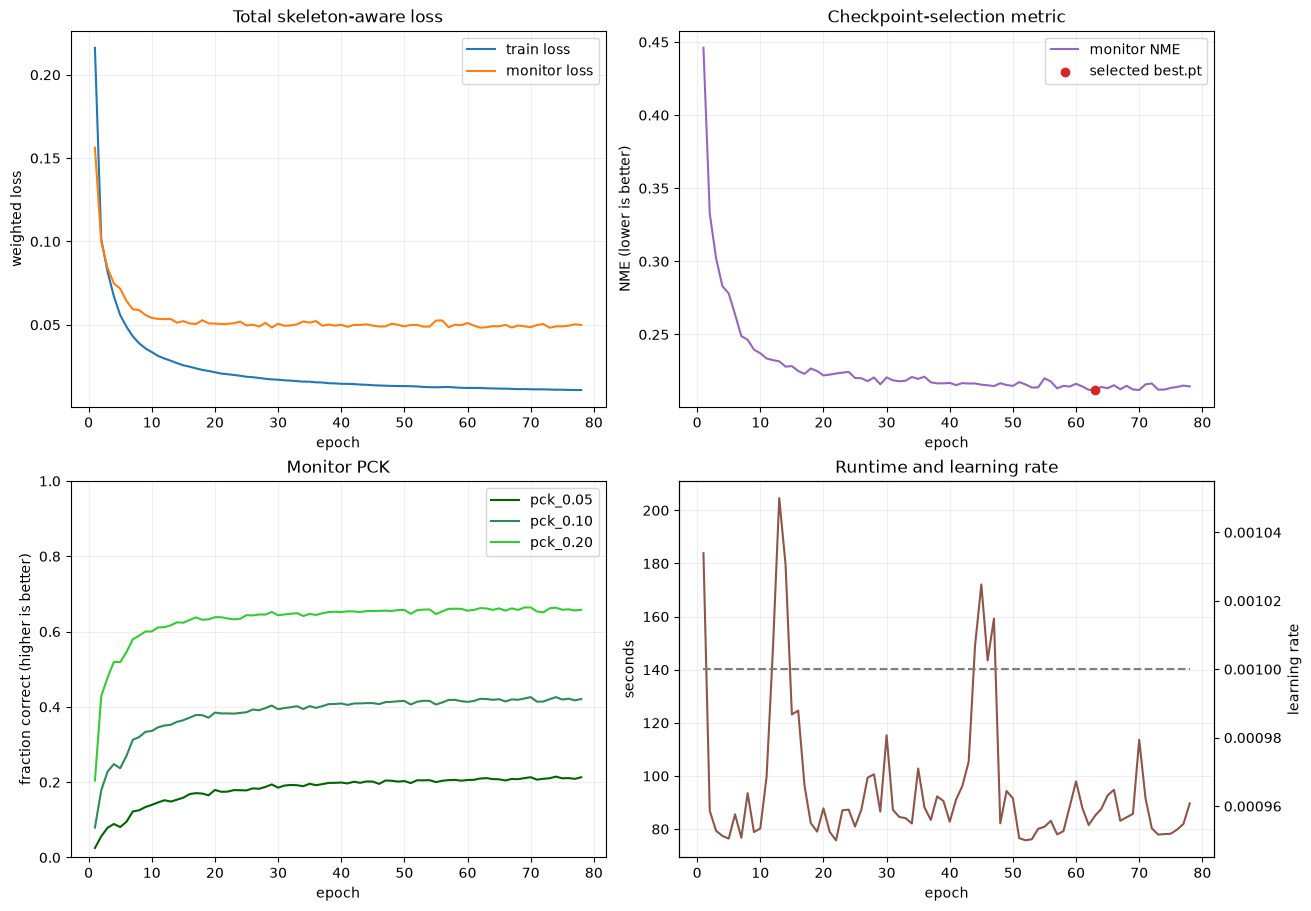

checkpoint directory    /data/axnguyen/31050_ML/wifi_csi_hpe/condition...
reloaded file                                                     best.pt
selected epoch                                                         63
best monitor NME                                                 0.211997
checkpoint MiB                                                  10.602373
inference shape                                             (8192, 14, 2)
model mode                                                     evaluation
Name: trained_model reload, dtype: object

In [5]:
if not logger.csv_path.exists() or not best_path.exists():
    print('No completed epoch yet. Run Section 4.4 first.')
else:
    history = pd.read_csv(logger.csv_path)
    display(history)
    selected = history.loc[history['monitor_nme'].idxmin()]
    display(pd.Series({
        'epochs completed': int(history['epoch'].max()),
        'selected epoch': int(selected['epoch']),
        'best monitor NME': selected['monitor_nme'],
        'stopped early': int(history['epoch'].max()) < max_epochs,
        'CSV log': str(logger.csv_path), 'JSONL log': str(logger.jsonl_path),
    }, name='saved run summary'))

    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
    axes[0,0].plot(history.epoch, history.train_loss_total, color='tab:blue', label='train loss')
    axes[0,0].plot(history.epoch, history.monitor_loss_total, color='tab:orange', label='monitor loss')
    axes[0,0].set(title='Total skeleton-aware loss', xlabel='epoch', ylabel='weighted loss'); axes[0,0].legend()
    axes[0,1].plot(history.epoch, history.monitor_nme, color='tab:purple', label='monitor NME')
    axes[0,1].scatter([selected.epoch], [selected.monitor_nme], color='tab:red', zorder=3, label='selected best.pt')
    axes[0,1].set(title='Checkpoint-selection metric', xlabel='epoch', ylabel='NME (lower is better)'); axes[0,1].legend()
    for column, colour in [('monitor_pck_0.05','darkgreen'), ('monitor_pck_0.10','seagreen'), ('monitor_pck_0.20','limegreen')]:
        axes[1,0].plot(history.epoch, history[column], color=colour, label=column.removeprefix('monitor_'))
    axes[1,0].set(title='Monitor PCK', xlabel='epoch', ylabel='fraction correct (higher is better)', ylim=(0,1)); axes[1,0].legend()
    axes[1,1].plot(history.epoch, history.train_seconds + history.monitor_seconds, color='tab:brown', label='epoch seconds')
    learning_axis = axes[1,1].twinx(); learning_axis.plot(history.epoch, history.learning_rate, color='tab:gray', linestyle='--', label='learning rate')
    axes[1,1].set(title='Runtime and learning rate', xlabel='epoch', ylabel='seconds', yscale='linear'); learning_axis.set_ylabel('learning rate')
    for axis in axes.flat: axis.grid(alpha=.2)
    plt.show()

    trained_model, _, _ = build_source_components(source_config)
    trained_model, best_checkpoint = load_trained_model(trained_model, best_path,
        source_config['condition'], {'split_checksum': split_checksum, 'normalizer_checksum': normalizer_checksum},
        expected_config=source_config)
    trained_model = trained_model.to(device).eval()
    monitor_batch = next(iter(loaders['monitor']))
    with torch.inference_mode(): prediction = trained_model(monitor_batch['csi'].to(device))
    assert prediction.shape == (monitor_batch['csi'].shape[0], 14, 2)
    display(pd.Series({
        'checkpoint directory': str(best_path.parent), 'reloaded file': best_path.name,
        'selected epoch': best_checkpoint['epoch'],
        'best monitor NME': best_checkpoint['best_monitor_nme'],
        'checkpoint MiB': best_path.stat().st_size / 2**20,
        'inference shape': str(tuple(prediction.shape)), 'model mode': 'evaluation',
    }, name='trained_model reload'))

### 4.6 Training boundary

Section 4 ends after monitor-selected checkpoint loading. It does **not** evaluate the Wi-Pose final-test participant and does not access WiMANS. Those one-time evaluations belong to Section 6 after both experimental conditions are frozen.

The exact shared logger and checkpoint implementations used above are displayed below for assessment transparency.

In [6]:
display(Code(inspect.getsource(EpochLogger), language='python'))
display(Code(inspect.getsource(CheckpointManager), language='python'))

class EpochLogger:
    def __init__(self, log_dir: str | Path) -> None:
        self.log_dir = Path(log_dir)
        self.log_dir.mkdir(parents=True, exist_ok=True)
        self.csv_path = self.log_dir / "epochs.csv"
        self.jsonl_path = self.log_dir / "epochs.jsonl"

    def log(self, record: dict[str, Any]) -> None:
        write_header = not self.csv_path.exists()
        with self.csv_path.open("a", newline="", encoding="utf-8") as handle:
            writer = csv.DictWriter(handle, fieldnames=list(record))
            if write_header:
                writer.writeheader()
            writer.writerow(record)
        with self.jsonl_path.open("a", encoding="utf-8") as handle:
            handle.write(json.dumps(record, sort_keys=True) + "\n")

class CheckpointManager:
    def __init__(self, result_dir: str | Path, mode: str = "min", best: float | None = None) -> None:
        self.directory = Path(result_dir) / "checkpoints"
        self.directory.mkdir(parents=True, exist_ok=True)
        self.mode = mode
        self.best = best if best is not None else (float("inf") if mode == "min" else -float("inf"))

    def _improved(self, metric: float) -> bool:
        return metric < self.best if self.mode == "min" else metric > self.best

    def save(self, state: dict[str, Any], metric: float) -> bool:
        torch.save(state, self.directory / "last.pt")
        if self._improved(metric):
            self.best = metric
            torch.save(state, self.directory / "best.pt")
            return True
        return False

## 5. Condition B — label-free target-domain adaptation

Condition B first learns CSI structure without pose labels, then fine-tunes the same encoder for BODY-14 regression. SSL uses balanced Wi-Pose training windows and permitted WiMANS classroom/meeting-room recordings; empty-room CSI and every WiMANS label remain excluded. Run Section 5 from **5.1 onward** after restarting the kernel—Sections 3 and 4 are not required.

### 5.1 Independent restart and protocol verification

This cell reconstructs configuration and artefact state, fixes all random generators, and verifies that the frozen Wi-Pose normalizer belongs to the current participant split. Pretraining and fine-tuning have separate logs/checkpoints so either stage can resume safely.

In [1]:
# Section 5 restart cell — run first in a fresh kernel.
from pathlib import Path
from datetime import datetime
import hashlib, inspect, random, shutil, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Code, display
from tqdm.auto import tqdm

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'environment.yml').exists()), None)
assert PROJECT_ROOT is not None, 'Open the repository first.'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

from conditions.ssl_domain_adapted.models import DomainAdaptedPoseModel
from shared.data.preprocessing import CSINormalizer
from shared.models import MaskedCSIAutoencoder
from shared.training import (AutoBatchSizer, CheckpointManager, EpochLogger, MaskedReconstructionTrainer,
    Trainer, build_source_components, build_ssl_components, build_ssl_loaders, build_wipose_loaders,
    load_trained_model, resume_pretraining, resume_training)
from shared.utils import deep_merge, load_yaml

SEED=31050
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
assert torch.cuda.is_available(), 'Committed Condition B training requires CUDA.'
device=torch.device('cuda:0'); torch.cuda.set_device(device)
ssl_config=deep_merge(load_yaml(PROJECT_ROOT/'shared/configs/base.yaml'), load_yaml(PROJECT_ROOT/'conditions/ssl_domain_adapted/configs/condition.yaml'))
split_path=PROJECT_ROOT/'data/manifests/wipose_split_v1.jsonl'
normalizer_path=PROJECT_ROOT/'data/processed/normalization_wipose_train_v1.npz'
wimans_manifest=PROJECT_ROOT/'data/manifests/wimans_partitions_v1.jsonl'
with np.load(normalizer_path, allow_pickle=False) as saved:
    normalizer=CSINormalizer(saved['mean'], saved['std']); split_checksum=str(saved['split_manifest_sha256'])
assert hashlib.sha256(split_path.read_bytes()).hexdigest()==split_checksum
normalizer_checksum=hashlib.sha256(normalizer_path.read_bytes()).hexdigest()
source_manifest_checksum=hashlib.sha256(wimans_manifest.read_bytes()).hexdigest()

root=PROJECT_ROOT/'conditions/ssl_domain_adapted'; log_dir=root/'logs'; result_dir=root/'results'
pre_last=result_dir/'pretraining_checkpoints/last.pt'; pre_best=result_dir/'pretraining_checkpoints/best.pt'
fine_last=result_dir/'checkpoints/last.pt'; fine_best=result_dir/'checkpoints/best.pt'
RESTART_PRETRAINING=False  # Archives both stages because fine-tuning depends on SSL.
RESTART_FINETUNING=False   # Archives only the pose fine-tuning stage.
print('Device:',torch.cuda.get_device_name(device)); print('SSL checkpoint:',pre_last if pre_last.exists() else 'fresh')

/data/axnguyen/Env/Anaconda/envs/ML_31005/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: NVIDIA RTX A5500
SSL checkpoint: /data/axnguyen/31050_ML/wifi_csi_hpe/conditions/ssl_domain_adapted/results/pretraining_checkpoints/last.pt


### 5.2 Balanced unlabelled SSL data and compatible encoder

A seeded hash reserves 10% of each permitted source for reconstruction monitoring. Each training epoch uses every remaining WiMANS recording once and an equally sized, epoch-varying Wi-Pose subset. A deterministic five-packet window is selected from each WiMANS recording. Both datasets use the frozen Wi-Pose normalizer.

The autoencoder contains the exact four PoseCNN residual blocks (`30→15→8→4` subcarriers while all five packets remain). Its temporary decoder expands to width 32 and crops to 30. Therefore all encoder tensors—not merely compatible fragments—transfer strictly.

In [2]:
preview_loaders, ssl_counts=build_ssl_loaders(PROJECT_ROOT, normalizer.transform, batch_size=2,
    num_workers=0, seed=SEED, monitor_fraction=ssl_config['pretraining']['monitor_fraction'])
preview_pair=[preview_loaders['train'].dataset[0],preview_loaders['train'].dataset[1]]
assert {x['source'] for x in preview_pair}=={'wipose','wimans'}
assert all(set(x)=={'csi','source','sample_id'} for x in preview_pair)
assert ssl_counts['excluded_empty_room_recordings']==594
display(pd.Series(ssl_counts,name='SSL protocol counts').to_frame())

pretrainer,_,_,pre_optimizer,_=build_ssl_components(ssl_config); pretrainer=pretrainer.to(device)
probe_sample=preview_pair[0]['csi'].to(device)
def ssl_trial(batch_size):
    pretrainer.zero_grad(set_to_none=True)
    x=probe_sample.unsqueeze(0).expand(batch_size,-1,-1,-1)
    reconstruction,mask=pretrainer(x,ssl_config['pretraining']['mask_ratio'])
    (((reconstruction-x).square()*mask).sum()/(mask.sum()*x.shape[1]).clamp_min(1)).backward()
ssl_probe=AutoBatchSizer(multiple=ssl_config['training']['batch_multiple'],
    reserve_gib=ssl_config['training']['memory_reserve_gib'],
    reserve_fraction=ssl_config['training']['memory_reserve_fraction']).probe(ssl_trial)
SSL_BATCH_SIZE=ssl_probe.per_gpu_batch
del pretrainer,pre_optimizer,probe_sample; torch.cuda.empty_cache()
ssl_loaders,ssl_counts=build_ssl_loaders(PROJECT_ROOT,normalizer.transform,SSL_BATCH_SIZE,0,SEED,
    ssl_config['pretraining']['monitor_fraction'])
display(pd.Series({'SSL batch size':SSL_BATCH_SIZE,'mask ratio':ssl_config['pretraining']['mask_ratio'],
    'maximum epochs':ssl_config['pretraining']['epochs'],'patience':ssl_config['training']['early_stopping_patience'],
    'learning rate':ssl_config['pretraining']['learning_rate'],'source balance':'50% Wi-Pose / 50% WiMANS'}).to_frame('resolved value'))
display(Code(inspect.getsource(MaskedCSIAutoencoder),language='python'))

,SSL protocol counts
wipose_train_pool,119401
wimans_train_recordings,1064
balanced_train_windows,2128
monitor_windows,248
excluded_empty_room_recordings,594


,resolved value
SSL batch size,8192
mask ratio,0.3
maximum epochs,50
patience,15
learning rate,0.001
source balance,50% Wi-Pose / 50% WiMANS


class MaskedCSIAutoencoder(nn.Module):
    """Compact masked-reconstruction pretrainer for common CSI tensors."""

    def __init__(self, channels: tuple[int, ...] = (32, 64, 128, 192)) -> None:
        super().__init__()
        blocks, in_channels = [], 9
        for index, out_channels in enumerate(channels):
            blocks.append(ResidualBlock(in_channels, out_channels, (1, 1) if index == 0 else (1, 2)))
            in_channels = out_channels
        self.encoder = nn.Sequential(*blocks)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(channels[3], channels[2], 3, stride=(1, 2), padding=1, output_padding=(0, 1)), nn.GELU(),
            nn.ConvTranspose2d(channels[2], channels[1], 3, stride=(1, 2), padding=1, output_padding=(0, 1)), nn.GELU(),
            nn.ConvTranspose2d(channels[1], channels[0], 3, stride=(1, 2), padding=1, output_padding=(0, 1)), nn.GELU(),
            nn.Conv2d(channels[0], 9, 1),
        )

    @staticmethod
    def make_mask(x: torch.Tensor, ratio: float = 0.30) -> torch.Tensor:
        if not 0.0 < ratio < 1.0:
            raise ValueError("Mask ratio must be between zero and one")
        return torch.rand_like(x[:, :1]) < ratio

    def forward(self, x: torch.Tensor, mask_ratio: float = 0.30) -> tuple[torch.Tensor, torch.Tensor]:
        mask = self.make_mask(x, mask_ratio)
        encoded = self.encoder(x.masked_fill(mask, 0.0))
        return self.decoder(encoded)[..., :30], mask

### 5.3 Stage 1 — masked CSI reconstruction

Let $x_{n,l,t,s}$ be standardized CSI, $\hat x_{n,l,t,s}$ its reconstruction, and $m_{n,t,s}\in\{0,1\}$ the mask shared across the nine links. With $L=9$ links, the pretraining objective is

$$\boxed{L_{\mathrm{SSL}}=
\frac{\sum_{n,l,t,s}m_{n,t,s}(\hat x_{n,l,t,s}-x_{n,l,t,s})^2}
{L\sum_{n,t,s}m_{n,t,s}}.}$$

The loss scores the blacked-out 30% of packet/subcarrier positions. `last.pt` restores interrupted optimization, and the lowest monitor masked MSE selects `best.pt` for encoder transfer. Setting `RESTART_PRETRAINING=True` archives existing Condition B logs and results before rebuilding both dependent stages.

In [3]:
if RESTART_PRETRAINING and (log_dir.exists() or result_dir.exists()):
    archive=root/'archive'/datetime.now().strftime('%Y%m%d_%H%M%S'); archive.mkdir(parents=True)
    for path in (log_dir,result_dir):
        if path.exists(): shutil.move(path,archive/path.name)

pretrainer,_,_,pre_optimizer,_=build_ssl_components(ssl_config); pretrainer=pretrainer.to(device)
pre_engine=MaskedReconstructionTrainer(pretrainer,pre_optimizer,device,ssl_config['pretraining']['mask_ratio'],ssl_config['training']['precision'])
pre_start,pre_best_loss,pre_wait=1,float('inf'),0
checks={'source_manifest_checksum':source_manifest_checksum,'split_checksum':split_checksum,'normalizer_checksum':normalizer_checksum}
if pre_last.exists() and not RESTART_PRETRAINING:
    state=resume_pretraining(pretrainer,pre_optimizer,pre_engine.scaler,pre_last,ssl_config,checks)
    pre_start,pre_best_loss,pre_wait=state['epoch']+1,state['best_monitor_reconstruction'],state['epochs_without_improvement']
    print(f"Resuming SSL after epoch {state['epoch']}")
pre_logger=EpochLogger(log_dir,'pretraining_epochs')
pre_saver=CheckpointManager(result_dir,best=pre_best_loss,directory_name='pretraining_checkpoints')
pre_history=pd.read_csv(pre_logger.csv_path) if pre_logger.csv_path.exists() else pd.DataFrame()
pre_best_epoch=int(pre_history.loc[pre_history.monitor_masked_mse.idxmin(),'epoch']) if not pre_history.empty else 0

RUN_PRETRAINING=True
if RUN_PRETRAINING and pre_start<=ssl_config['pretraining']['epochs']:
    progress=tqdm(range(pre_start,ssl_config['pretraining']['epochs']+1),desc='Condition B — SSL',unit='epoch')
    for epoch in progress:
        ssl_loaders['train'].dataset.set_epoch(epoch)
        train=pre_engine.run_epoch(ssl_loaders['train'],True); monitor=pre_engine.run_epoch(ssl_loaders['monitor'],False)
        improved=monitor['masked_mse']<pre_best_loss; pre_best_loss=min(pre_best_loss,monitor['masked_mse'])
        pre_wait=0 if improved else pre_wait+1
        if improved: pre_best_epoch=epoch
        record={'epoch':epoch,'train_masked_mse':train['masked_mse'],'monitor_masked_mse':monitor['masked_mse'],
            'train_seconds':train['seconds'],'monitor_seconds':monitor['seconds'],'learning_rate':pre_optimizer.param_groups[0]['lr'],
            'batch_size':SSL_BATCH_SIZE,'best_epoch':pre_best_epoch,'best_monitor_reconstruction':pre_best_loss,
            'epochs_without_improvement':pre_wait}
        state={'epoch':epoch,'condition':ssl_config['condition'],'stage':'pretraining','model':pretrainer.state_dict(),
            'optimizer':pre_optimizer.state_dict(),'scaler':pre_engine.scaler.state_dict(),
            'best_monitor_reconstruction':pre_best_loss,'epochs_without_improvement':pre_wait,'config':ssl_config,**checks}
        pre_saver.save(state,monitor['masked_mse']); pre_logger.log(record)
        progress.set_postfix(train=f"{train['masked_mse']:.4f}",monitor=f"{monitor['masked_mse']:.4f}",
            best=pre_best_epoch,patience_left=ssl_config['training']['early_stopping_patience']-pre_wait)
        if pre_wait>=ssl_config['training']['early_stopping_patience']:
            print(f'SSL early stopping at epoch {epoch}; best epoch {pre_best_epoch}.'); break
elif pre_start>ssl_config['pretraining']['epochs']: print('SSL pretraining already complete.')
else: print('SSL pretraining skipped.')

Resuming SSL after epoch 50
SSL pretraining already complete.


### 5.4 Stage 2 — strict transfer and supervised pose fine-tuning

`best.pt` from Stage 1 initializes every encoder tensor with `strict=True`; the 28-value pose head remains new. Fine-tuning then uses exactly Condition A’s Wi-Pose train/monitor partitions, skeleton-aware loss, optimizer, and NME selection. The entire network is trainable. The final-test loader is deliberately absent.

In [4]:
if RESTART_FINETUNING:
    archive=root/'archive'/datetime.now().strftime('%Y%m%d_%H%M%S')/'finetuning'; archive.mkdir(parents=True)
    for path in (log_dir/'finetuning_epochs.csv',log_dir/'finetuning_epochs.jsonl',result_dir/'checkpoints'):
        if path.exists(): shutil.move(path,archive/path.name)

assert pre_best.exists() or not RUN_PRETRAINING, 'Stage 1 must produce pretraining best.pt.'
pose_loaders=build_wipose_loaders(PROJECT_ROOT,normalizer.transform,32,0,partitions=('train','monitor'))
_,pose_model,pose_criterion,_,pose_optimizer=build_ssl_components(ssl_config)
pose_model=pose_model.to(device)
fine_start,fine_best_nme,fine_wait=1,float('inf'),0
pretraining_checkpoint_checksum=hashlib.sha256(pre_best.read_bytes()).hexdigest() if pre_best.exists() else ''
transferred_keys=[]
if fine_last.exists() and not RESTART_FINETUNING:
    fine_engine=Trainer(pose_model,pose_optimizer,pose_criterion,device,ssl_config['training']['precision'])
    state=resume_training(pose_model,pose_optimizer,fine_engine.scaler,fine_last,ssl_config['condition'],ssl_config,
        {'split_checksum':split_checksum,'normalizer_checksum':normalizer_checksum})
    assert state['pretraining_checkpoint_checksum']==pretraining_checkpoint_checksum
    fine_start,fine_best_nme,fine_wait=state['epoch']+1,state['best_monitor_nme'],state['epochs_without_improvement']
    transferred_keys=state['transferred_encoder_keys']; print(f"Resuming fine-tuning after epoch {state['epoch']}")
elif pre_best.exists():
    transferred_keys=pose_model.load_pretrained_encoder(pre_best)
    assert transferred_keys==list(pose_model.encoder.state_dict())
    fine_engine=Trainer(pose_model,pose_optimizer,pose_criterion,device,ssl_config['training']['precision'])
else:
    fine_engine=Trainer(pose_model,pose_optimizer,pose_criterion,device,ssl_config['training']['precision'])
    print('No SSL best.pt yet; fine-tuning cannot start.')

transfer_table=pd.DataFrame([{'encoder tensor':key,'shape':tuple(value.shape),'transferred':key in transferred_keys}
    for key,value in pose_model.encoder.state_dict().items()])
if transferred_keys: assert transfer_table.transferred.all()
display(transfer_table)

probe_batch=next(iter(pose_loaders['train']))
def pose_trial(batch_size):
    pose_model.zero_grad(set_to_none=True)
    n=probe_batch['csi'].shape[0]; indices=torch.arange(batch_size)%n
    prediction=pose_model(probe_batch['csi'][indices].to(device))
    pose_criterion(prediction,probe_batch['joints'][indices].to(device),probe_batch['confidence'][indices].to(device))['total'].backward()
pose_probe=AutoBatchSizer(multiple=ssl_config['training']['batch_multiple'],reserve_gib=ssl_config['training']['memory_reserve_gib'],
    reserve_fraction=ssl_config['training']['memory_reserve_fraction']).probe(pose_trial)
POSE_BATCH_SIZE=pose_probe.per_gpu_batch
pose_loaders=build_wipose_loaders(PROJECT_ROOT,normalizer.transform,POSE_BATCH_SIZE,0,partitions=('train','monitor'))
fine_logger=EpochLogger(log_dir,'finetuning_epochs'); fine_saver=CheckpointManager(result_dir,best=fine_best_nme)
fine_history=pd.read_csv(fine_logger.csv_path) if fine_logger.csv_path.exists() else pd.DataFrame()
fine_best_epoch=int(fine_history.loc[fine_history.monitor_nme.idxmin(),'epoch']) if not fine_history.empty else 0

RUN_FINETUNING=True
if RUN_FINETUNING and transferred_keys and fine_start<=ssl_config['training']['epochs']:
    progress=tqdm(range(fine_start,ssl_config['training']['epochs']+1),desc='Condition B — pose fine-tuning',unit='epoch')
    for epoch in progress:
        train=fine_engine.run_epoch(pose_loaders['train'],True); monitor=fine_engine.run_epoch(pose_loaders['monitor'],False)
        improved=monitor['nme']<fine_best_nme; fine_best_nme=min(fine_best_nme,monitor['nme']); fine_wait=0 if improved else fine_wait+1
        if improved: fine_best_epoch=epoch
        record={'epoch':epoch,**{f'train_{k}':v for k,v in train.items()},**{f'monitor_{k}':v for k,v in monitor.items()},
            'learning_rate':pose_optimizer.param_groups[0]['lr'],'batch_size':POSE_BATCH_SIZE,'best_epoch':fine_best_epoch,
            'best_monitor_nme':fine_best_nme,'epochs_without_improvement':fine_wait}
        state={'epoch':epoch,'condition':ssl_config['condition'],'model':pose_model.state_dict(),'optimizer':pose_optimizer.state_dict(),
            'scaler':fine_engine.scaler.state_dict(),'best_monitor_nme':fine_best_nme,'epochs_without_improvement':fine_wait,
            'config':ssl_config,'split_checksum':split_checksum,'normalizer_checksum':normalizer_checksum,
            'pretraining_checkpoint_checksum':pretraining_checkpoint_checksum,'transferred_encoder_keys':transferred_keys}
        fine_saver.save(state,monitor['nme']); fine_logger.log(record)
        progress.set_postfix(train=f"{train['loss_total']:.4f}",monitor=f"{monitor['loss_total']:.4f}",nme=f"{monitor['nme']:.4f}",
            pck20=f"{monitor['pck_0.20']:.3f}",best=fine_best_epoch,patience_left=ssl_config['training']['early_stopping_patience']-fine_wait)
        if fine_wait>=ssl_config['training']['early_stopping_patience']:
            print(f'Fine-tuning early stopping at epoch {epoch}; best epoch {fine_best_epoch}.'); break
elif fine_start>ssl_config['training']['epochs']: print('Fine-tuning already complete.')
else: print('Fine-tuning skipped or waiting for SSL best.pt.')

Resuming fine-tuning after epoch 19


,encoder tensor,shape,transferred
0,0.main.0.weight,"(32, 9, 3, 3)",True
1,0.main.1.weight,"(32,)",True
2,0.main.1.bias,"(32,)",True
3,0.main.1.running_mean,"(32,)",True
4,0.main.1.running_var,"(32,)",True
...,...,...,...
67,3.skip.1.weight,"(192,)",True
68,3.skip.1.bias,"(192,)",True
69,3.skip.1.running_mean,"(192,)",True
70,3.skip.1.running_var,"(192,)",True



Condition B — pose fine-tuning:   0%|          | 0/81 [00:00<?, ?epoch/s]


Condition B — pose fine-tuning:   0%|          | 0/81 [03:51<?, ?epoch/s, best=19, monitor=0.0493, nme=0.2170, patience_left=14, pck20=0.650, train=0.0194]


Condition B — pose fine-tuning:   1%|          | 1/81 [03:51<5:08:15, 231.19s/epoch, best=19, monitor=0.0493, nme=0.2170, patience_left=14, pck20=0.650, train=0.0194]

...


Condition B — pose fine-tuning:  72%|███████▏  | 58/81 [3:02:01<1:58:43, 309.72s/epoch, best=64, monitor=0.0488, nme=0.2115, patience_left=1, pck20=0.664, train=0.0107]


Condition B — pose fine-tuning:  73%|███████▎  | 59/81 [3:02:01<1:58:16, 322.58s/epoch, best=64, monitor=0.0488, nme=0.2115, patience_left=1, pck20=0.664, train=0.0107]


Condition B — pose fine-tuning:  73%|███████▎  | 59/81 [3:08:38<1:58:16, 322.58s/epoch, best=64, monitor=0.0478, nme=0.2100, patience_left=0, pck20=0.666, train=0.0107]


Condition B — pose fine-tuning:  73%|███████▎  | 59/81 [3:08:38<1:10:20, 191.84s/epoch, best=64, monitor=0.0478, nme=0.2100, patience_left=0, pck20=0.666, train=0.0107]

Fine-tuning early stopping at epoch 79; best epoch 64.


### 5.5 Saved histories, annotated curves, and trained-model reload

Both displays are rebuilt from disk. Blue/orange identify train/monitor objectives; purple is monitor NME; green shades are PCK thresholds; red marks the selected epoch. `trained_model_condition_b` is reconstructed from configuration and loaded from the fine-tuning `best.pt` in the same directory.

,epoch,train_masked_mse,monitor_masked_mse,train_seconds,monitor_seconds,learning_rate,batch_size,best_epoch,best_monitor_reconstruction,epochs_without_improvement
0,1,18.336121,18.183285,81.280850,9.090980,0.001,8192,1,18.183285,0
1,2,18.032978,17.560394,13.800695,0.552324,0.001,8192,2,17.560394,0
2,3,17.109146,17.480549,12.307523,0.154445,0.001,8192,3,17.480549,0
3,4,15.608108,17.313286,11.855009,0.727169,0.001,8192,4,17.313286,0
4,5,14.133056,17.328991,11.834319,0.164052,0.001,8192,4,17.313286,1
5,6,13.302192,16.704960,11.321356,0.203461,0.001,8192,6,16.704960,0
6,7,12.548388,16.373123,10.903271,0.181833,0.001,8192,7,16.373123,0
7,8,11.309763,16.244854,9.132788,0.539602,0.001,8192,8,16.244854,0
8,9,10.470216,14.958196,10.111115,0.154324,0.001,8192,9,14.958196,0
9,10,9.774483,12.625865,9.458383,0.185001,0.001,8192,10,12.625865,0


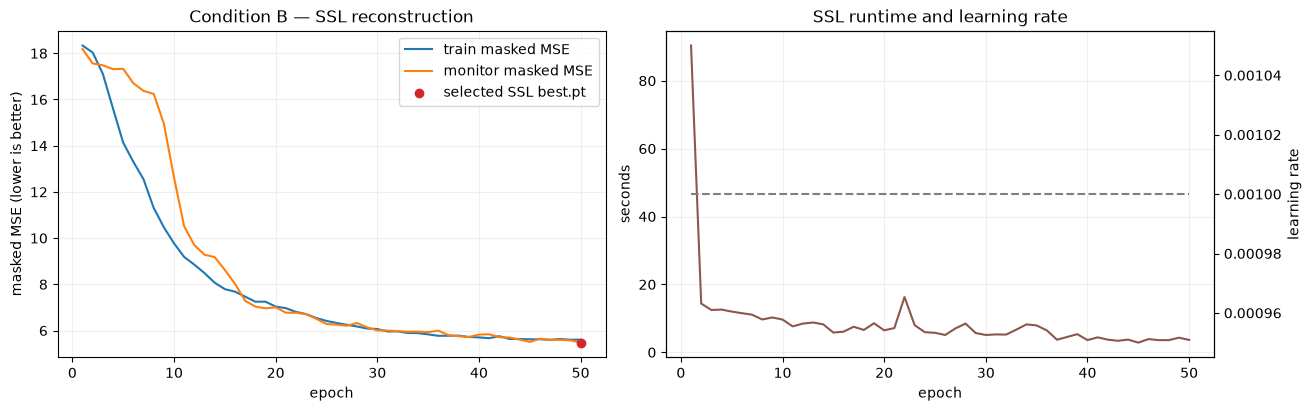

,epoch,train_loss_total,train_loss_coordinate,train_loss_bone,train_loss_symmetry,train_nme,train_pck_0.05,train_pck_0.10,train_pck_0.20,train_bone_length_error,...,monitor_pck_0.05,monitor_pck_0.10,monitor_pck_0.20,monitor_bone_length_error,monitor_seconds,learning_rate,batch_size,best_epoch,best_monitor_nme,epochs_without_improvement
0,1,0.198465,0.178932,0.054417,0.118573,0.464310,0.025540,0.095300,0.287353,0.222199,...,0.050211,0.148825,0.390063,0.161307,23.027826,0.001,5640,1,0.358883,0
1,2,0.110178,0.098770,0.033116,0.062569,0.338089,0.051522,0.172570,0.431699,0.145191,...,0.064564,0.185562,0.433073,0.154155,11.175846,0.001,5640,2,0.335742,0
2,3,0.089249,0.079355,0.028825,0.053744,0.307339,0.065149,0.205690,0.473991,0.134183,...,0.070103,0.204872,0.464606,0.144011,7.762779,0.001,5640,3,0.311405,0
3,4,0.070408,0.061809,0.024403,0.049970,0.275576,0.079939,0.240992,0.518238,0.123297,...,0.083277,0.232464,0.500747,0.129249,9.654571,0.001,5640,4,0.288107,0
4,5,0.057041,0.049551,0.021021,0.044705,0.247634,0.096816,0.279537,0.567535,0.113359,...,0.099785,0.267571,0.536057,0.117960,8.101266,0.001,5640,5,0.270810,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,75,0.010876,0.008028,0.008355,0.015187,0.106444,0.352091,0.663957,0.894340,0.064431,...,0.203016,0.414775,0.656830,0.094524,33.298007,0.001,8192,64,0.207625,11
75,76,0.010837,0.008003,0.008327,0.015035,0.106548,0.350669,0.662241,0.893695,0.064499,...,0.214100,0.428028,0.669597,0.092812,39.255319,0.001,8192,64,0.207625,12
76,77,0.010690,0.007867,0.008272,0.015105,0.105733,0.353855,0.666396,0.895835,0.064124,...,0.217926,0.430829,0.671276,0.094426,32.750968,0.001,8192,64,0.207625,13
77,78,0.010686,0.007868,0.008267,0.015030,0.105619,0.354529,0.667103,0.895903,0.064130,...,0.212664,0.425815,0.663995,0.094005,46.422502,0.001,8192,64,0.207625,14


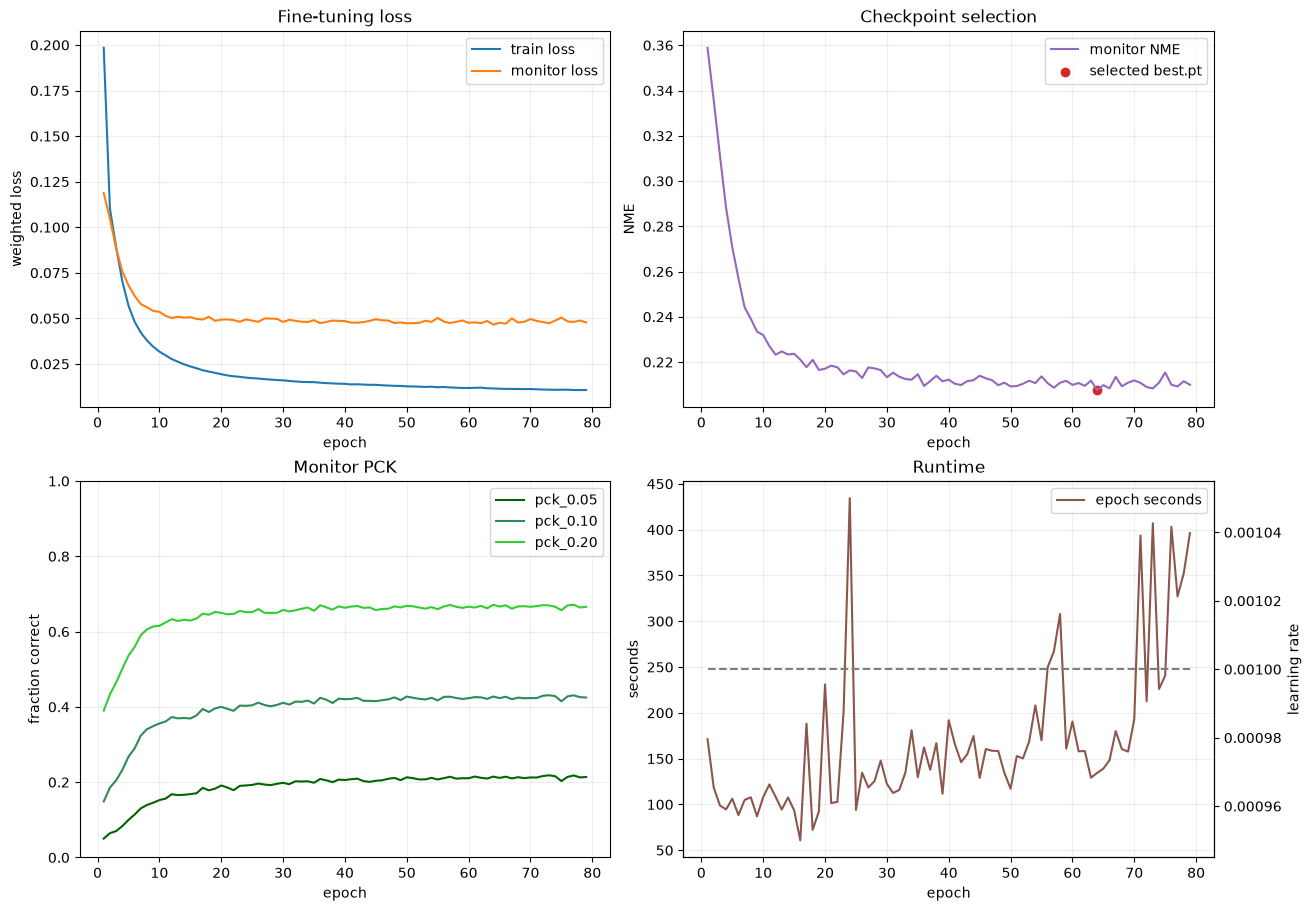

checkpoint          /data/axnguyen/31050_ML/wifi_csi_hpe/condition...
selected epoch                                                     64
best monitor NME                                             0.207625
encoder transfer                                        72/72 tensors
inference shape                                         (8192, 14, 2)
Name: trained_model_condition_b, dtype: object

In [5]:
pre_history=pd.read_csv(pre_logger.csv_path) if pre_logger.csv_path.exists() else pd.DataFrame()
fine_history=pd.read_csv(fine_logger.csv_path) if fine_logger.csv_path.exists() else pd.DataFrame()
if pre_history.empty: print('No SSL log yet.')
else:
    display(pre_history); selected_pre=pre_history.loc[pre_history.monitor_masked_mse.idxmin()]
    fig,pre_axes=plt.subplots(1,2,figsize=(13,4),constrained_layout=True)
    pre_axes[0].plot(pre_history.epoch,pre_history.train_masked_mse,color='tab:blue',label='train masked MSE')
    pre_axes[0].plot(pre_history.epoch,pre_history.monitor_masked_mse,color='tab:orange',label='monitor masked MSE')
    pre_axes[0].scatter([selected_pre.epoch],[selected_pre.monitor_masked_mse],color='tab:red',label='selected SSL best.pt',zorder=3)
    pre_axes[0].set(xlabel='epoch',ylabel='masked MSE (lower is better)',title='Condition B — SSL reconstruction'); pre_axes[0].grid(alpha=.2); pre_axes[0].legend()
    pre_axes[1].plot(pre_history.epoch,pre_history.train_seconds+pre_history.monitor_seconds,color='tab:brown',label='epoch seconds')
    pre_lr=pre_axes[1].twinx(); pre_lr.plot(pre_history.epoch,pre_history.learning_rate,color='tab:gray',linestyle='--',label='learning rate')
    pre_axes[1].set(xlabel='epoch',ylabel='seconds',title='SSL runtime and learning rate'); pre_lr.set_ylabel('learning rate'); pre_axes[1].grid(alpha=.2); plt.show()
if fine_history.empty: print('No fine-tuning log yet.')
else:
    display(fine_history); selected_fine=fine_history.loc[fine_history.monitor_nme.idxmin()]
    fig,axes=plt.subplots(2,2,figsize=(13,9),constrained_layout=True)
    axes[0,0].plot(fine_history.epoch,fine_history.train_loss_total,color='tab:blue',label='train loss'); axes[0,0].plot(fine_history.epoch,fine_history.monitor_loss_total,color='tab:orange',label='monitor loss')
    axes[0,1].plot(fine_history.epoch,fine_history.monitor_nme,color='tab:purple',label='monitor NME'); axes[0,1].scatter([selected_fine.epoch],[selected_fine.monitor_nme],color='tab:red',label='selected best.pt')
    for column,colour in [('monitor_pck_0.05','darkgreen'),('monitor_pck_0.10','seagreen'),('monitor_pck_0.20','limegreen')]: axes[1,0].plot(fine_history.epoch,fine_history[column],color=colour,label=column.removeprefix('monitor_'))
    axes[1,1].plot(fine_history.epoch,fine_history.train_seconds+fine_history.monitor_seconds,color='tab:brown',label='epoch seconds')
    fine_lr=axes[1,1].twinx(); fine_lr.plot(fine_history.epoch,fine_history.learning_rate,color='tab:gray',linestyle='--',label='learning rate'); fine_lr.set_ylabel('learning rate')
    titles=[('Fine-tuning loss','weighted loss'),('Checkpoint selection','NME'),('Monitor PCK','fraction correct'),('Runtime','seconds')]
    for axis,(title,ylabel) in zip(axes.flat,titles): axis.set(title=title,xlabel='epoch',ylabel=ylabel); axis.grid(alpha=.2); axis.legend()
    axes[1,0].set_ylim(0,1); plt.show()

if fine_best.exists():
    trained_model_condition_b=DomainAdaptedPoseModel(tuple(ssl_config['model']['channels']),ssl_config['data']['num_joints'],ssl_config['model']['dropout'])
    trained_model_condition_b,best_checkpoint=load_trained_model(trained_model_condition_b,fine_best,ssl_config['condition'],
        {'split_checksum':split_checksum,'normalizer_checksum':normalizer_checksum},expected_config=ssl_config)
    assert best_checkpoint['pretraining_checkpoint_checksum']==hashlib.sha256(pre_best.read_bytes()).hexdigest()
    assert best_checkpoint['transferred_encoder_keys']==list(trained_model_condition_b.encoder.state_dict())
    trained_model_condition_b=trained_model_condition_b.to(device).eval(); batch=next(iter(pose_loaders['monitor']))
    with torch.inference_mode(): prediction=trained_model_condition_b(batch['csi'].to(device))
    assert prediction.shape==(batch['csi'].shape[0],14,2)
    display(pd.Series({'checkpoint':str(fine_best),'selected epoch':best_checkpoint['epoch'],
        'best monitor NME':best_checkpoint['best_monitor_nme'],'encoder transfer':'72/72 tensors',
        'inference shape':str(tuple(prediction.shape))},name='trained_model_condition_b'))
else: print('No fine-tuned best.pt yet; run Stages 1 and 2.')

### 5.6 Condition B boundary

Section 5 ends with a monitor-selected, reloaded Condition B model. It never constructs the Wi-Pose final-test loader and never reads empty-room WiMANS CSI. Section 6 performs the one-time frozen comparison against Condition A.

## 6. Condition A — complete Wi-Pose test evaluation

This section evaluates Condition A alone on all 17,645 frames from the untouched Wi-Pose test partition. It loads the frozen predictions produced by the monitor-selected checkpoint; it does not retrain or select a model. Because the target is a hip-centred, torso-normalized 2D skeleton, the primary distance is reported as **2D MPJPE**, numerically identical here to the notebook's NME. PCK, PCK-AUC, bone-length error, symmetry error, per-joint diagnostics, a nearest-joint confusion matrix, and a random full-recording video provide complementary views.

### 6.1 Independent restart and held-out test audit

Run this cell first after restarting the kernel. It loads only Condition A's frozen Wi-Pose test predictions and verifies that they cover the complete test manifest.

In [2]:
from pathlib import Path
import json, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'environment.yml').exists()), None)
assert PROJECT_ROOT is not None, 'Open the repository before running Section 6.'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))
from shared.data.skeleton import BODY_14_EDGES, BODY_14_JOINTS

prediction_path = PROJECT_ROOT/'conditions/source_only_zero_shot/results/test_predictions.npz'
manifest_path = PROJECT_ROOT/'data/manifests/wipose_split_v1.jsonl'
assert prediction_path.exists(), f'Missing frozen Condition A predictions: {prediction_path}'
saved = np.load(prediction_path, allow_pickle=False)
prediction, target, confidence = saved['prediction'], saved['target'], saved['confidence']
sample_id = saved['sample_id'].astype(str)
test_rows = [json.loads(line) for line in manifest_path.open() if json.loads(line)['partition']=='test']
test_index = {row['sample_id']: row for row in test_rows}
assert len(sample_id)==len(test_rows)==17645 and set(sample_id)==set(test_index)
audit = pd.Series({'condition':'Condition A — source-only','checkpoint selection':'Wi-Pose monitor NME','test frames':len(sample_id),'test groups':len({test_index[s]['participant'] for s in sample_id}),'prediction shape':str(prediction.shape),'target shape':str(target.shape),'test used during training':False})
audit.to_frame('value')

,value
condition,Condition A — source-only
checkpoint selection,Wi-Pose monitor NME
test frames,17645
test groups,12
prediction shape,"(17645, 14, 2)"
target shape,"(17645, 14, 2)"
test used during training,False


### 6.2 Overall 2D MPJPE, PCK, and anatomical metrics

For valid-joint indicator $v_{n,j}=\mathbb 1[c_{n,j}>0]$ and Euclidean error $e_{n,j}=\|\hat{\mathbf y}_{n,j}-\mathbf y_{n,j}\|_2$, the normalized 2D mean per-joint position error is

$$\boxed{\operatorname{MPJPE}_{2D}=\operatorname{NME}=
\frac{\sum_{n,j}v_{n,j}e_{n,j}}{\sum_{n,j}v_{n,j}}.}$$

It is dimensionless because canonicalization divides coordinates by torso length. PCK at threshold $\tau$ is

$$\boxed{\operatorname{PCK}(\tau)=
\frac{\sum_{n,j}v_{n,j}\mathbb 1[e_{n,j}\leq\tau]}{\sum_{n,j}v_{n,j}}.}$$

The notebook reports $\tau\in\{0.05,0.10,0.20\}$. The normalized area under the PCK curve is

$$\operatorname{PCK\!\text{-}AUC}_{[0,0.5]}=
\frac{1}{0.5}\int_0^{0.5}\operatorname{PCK}(\tau)\,d\tau.$$

For edge $e$, the reported bone-length error is

$$E_{\mathrm{bone}}=\operatorname{mean}_{n,e}
\left|\|\hat{\mathbf v}_{n,e}\|_2-\|\mathbf v_{n,e}\|_2\right|,$$

and the prediction-only symmetry error is

$$E_{\mathrm{sym}}=\operatorname{mean}_{n,(e_L,e_R)\in\mathcal S}
\left|\|\hat{\mathbf v}_{n,e_L}\|_2-\|\hat{\mathbf v}_{n,e_R}\|_2\right|.$$

Lower MPJPE, bone error, and symmetry error are better. Higher PCK and PCK-AUC are better.

,Condition A
2D MPJPE / NME ↓,0.206182
PCK@0.05 ↑,0.214512
PCK@0.10 ↑,0.429555
PCK@0.20 ↑,0.668676
"normalized PCK-AUC [0,.50] ↑",0.644496
bone-length error ↓,0.079913
symmetry error ↓,0.018491
valid joints,247030.000000


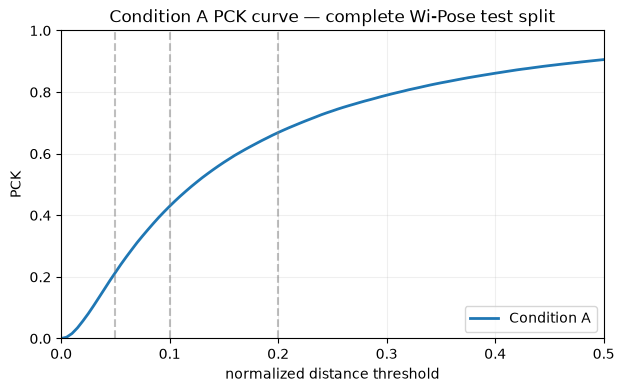

In [2]:
from shared.evaluation.metrics import symmetry_error
import torch

valid = confidence > 0
distance = np.linalg.norm(prediction-target, axis=-1)
mpjpe_2d = distance[valid].mean()
thresholds = np.linspace(0, .50, 101)
pck_curve = np.array([(distance[valid] <= threshold).mean() for threshold in thresholds])
pred_bones = np.stack([np.linalg.norm(prediction[:,b]-prediction[:,a], axis=-1) for a,b in BODY_14_EDGES], axis=1)
true_bones = np.stack([np.linalg.norm(target[:,b]-target[:,a], axis=-1) for a,b in BODY_14_EDGES], axis=1)
overall = pd.Series({'2D MPJPE / NME ↓':mpjpe_2d,'PCK@0.05 ↑':pck_curve[10],'PCK@0.10 ↑':pck_curve[20],'PCK@0.20 ↑':pck_curve[40],'normalized PCK-AUC [0,.50] ↑':np.trapezoid(pck_curve, thresholds)/.50,'bone-length error ↓':np.abs(pred_bones-true_bones).mean(),'symmetry error ↓':float(symmetry_error(torch.from_numpy(prediction)).mean()),'valid joints':int(valid.sum())})
display(overall.to_frame('Condition A'))
fig,ax=plt.subplots(figsize=(7,4)); ax.plot(thresholds,pck_curve,color='tab:blue',lw=2,label='Condition A')
for threshold in (.05,.10,.20): ax.axvline(threshold,color='grey',ls='--',alpha=.5)
ax.set(title='Condition A PCK curve — complete Wi-Pose test split',xlabel='normalized distance threshold',ylabel='PCK',xlim=(0,.5),ylim=(0,1)); ax.grid(alpha=.2); ax.legend(); plt.show()

### 6.3 Per-joint 2D MPJPE and PCK

These views expose which anatomical joints drive the aggregate score. Bar height is per-joint 2D MPJPE; heatmap colour is per-joint PCK at the three declared thresholds.

,joint,2D MPJPE,PCK@0.05,PCK@0.10,PCK@0.20
0,nose,0.223889,0.189912,0.445679,0.693058
1,neck,0.137200,0.407934,0.638141,0.809748
2,right_shoulder,0.178165,0.238595,0.498668,0.721337
3,right_elbow,0.284497,0.064834,0.213828,0.487900
4,right_wrist,0.404472,0.027317,0.103995,0.302069
5,left_shoulder,0.171255,0.239615,0.481780,0.735733
6,left_elbow,0.231835,0.122584,0.294021,0.561122
7,left_wrist,0.311818,0.063417,0.210371,0.451063
8,right_hip,0.061010,0.535676,0.826750,0.980391
9,right_knee,0.195072,0.185492,0.422613,0.682176


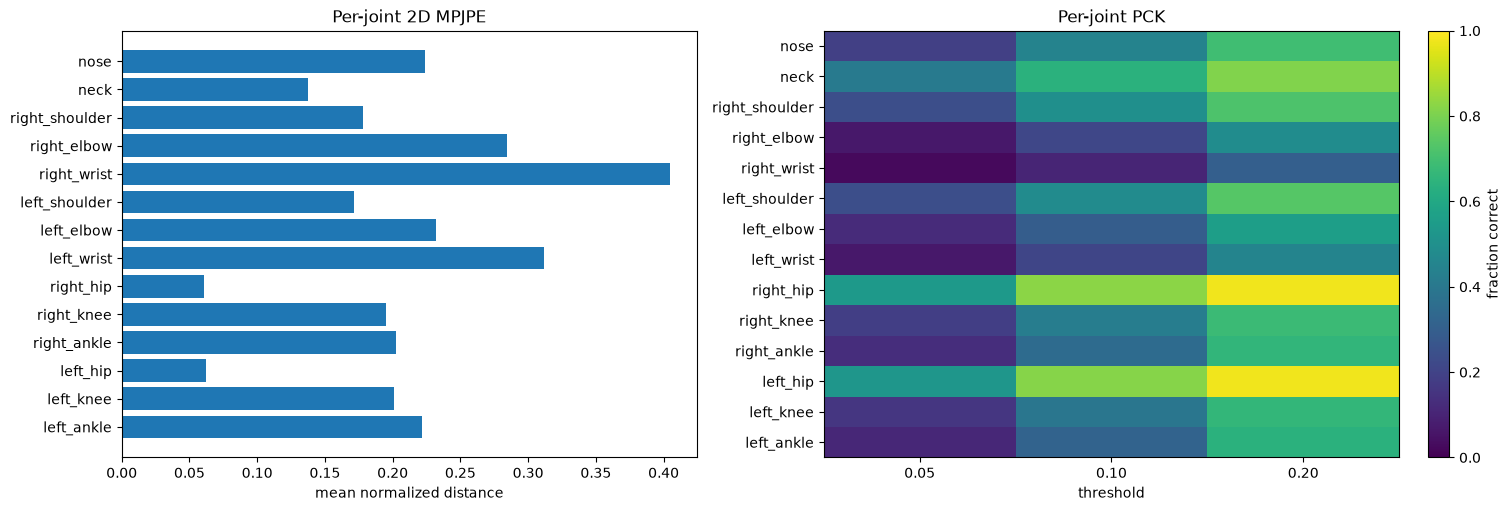

In [3]:
joint_mpjpe=np.array([distance[valid[:,j],j].mean() for j in range(14)])
joint_pck=np.array([[(distance[valid[:,j],j]<=threshold).mean() for threshold in (.05,.10,.20)] for j in range(14)])
joint_table=pd.DataFrame({'joint':BODY_14_JOINTS,'2D MPJPE':joint_mpjpe,'PCK@0.05':joint_pck[:,0],'PCK@0.10':joint_pck[:,1],'PCK@0.20':joint_pck[:,2]})
display(joint_table)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(15,5),constrained_layout=True)
ax1.barh(BODY_14_JOINTS,joint_mpjpe,color='tab:blue'); ax1.invert_yaxis(); ax1.set(title='Per-joint 2D MPJPE',xlabel='mean normalized distance')
image=ax2.imshow(joint_pck,aspect='auto',vmin=0,vmax=1,cmap='viridis'); ax2.set(yticks=range(14),yticklabels=BODY_14_JOINTS,xticks=range(3),xticklabels=['0.05','0.10','0.20'],title='Per-joint PCK',xlabel='threshold'); fig.colorbar(image,ax=ax2,label='fraction correct'); plt.show()

### 6.4 Joint-identity confusion matrix

PoseCNN predicts coordinates rather than activity classes, so the notebook uses a spatial joint-identity analogue. For predicted joint $i$, the nearest reference identity is

$$z_{n,i}=\arg\min_j\|\hat{\mathbf y}_{n,i}-\mathbf y_{n,j}\|_2.$$

The row-normalized matrix entry is

$$C_{i,j}=\frac{\sum_n v_{n,i}\mathbb 1[z_{n,i}=j]}{\sum_n v_{n,i}},
\qquad \sum_j C_{i,j}=1.$$

Each row represents one predicted joint, and each column represents its nearest ground-truth joint. A strong diagonal means that predictions tend to occupy the correct anatomical region. Adjacent joints and overlapping left/right limbs can produce off-diagonal entries even when coordinate error remains moderate, so MPJPE and PCK remain the primary accuracy measures.

Mean diagonal identity rate: 67.76%


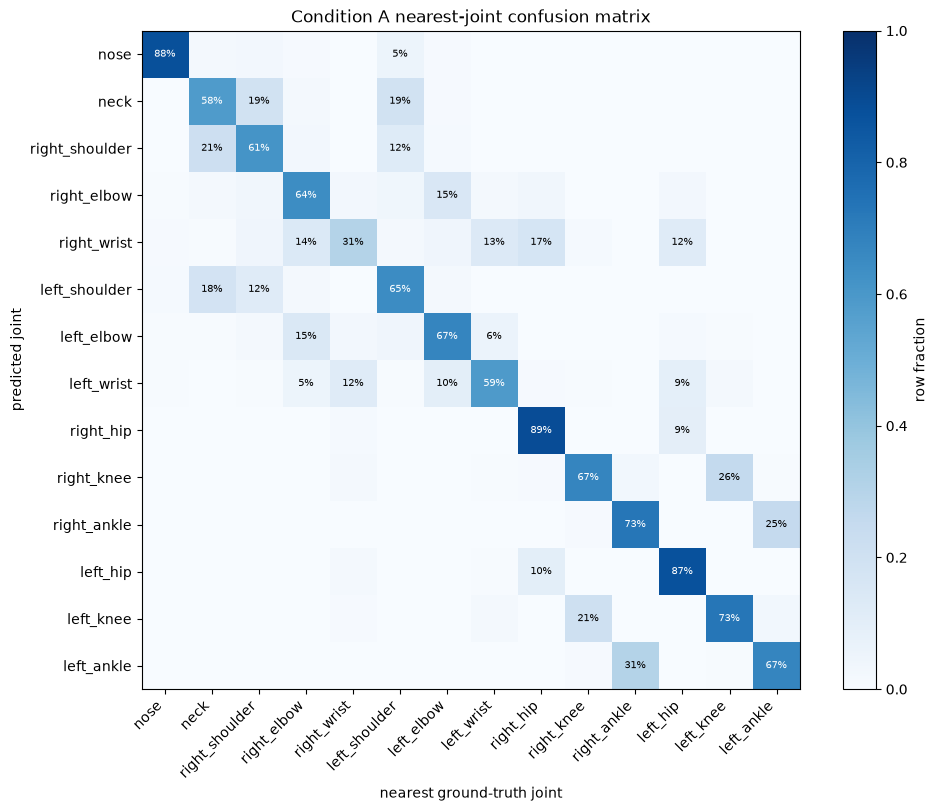

In [4]:
nearest=np.linalg.norm(prediction[:,:,None,:]-target[:,None,:,:],axis=-1).argmin(axis=2)
confusion=np.zeros((14,14),dtype=np.int64)
for predicted_joint in range(14):
    confusion[predicted_joint]=np.bincount(nearest[valid[:,predicted_joint],predicted_joint],minlength=14)
confusion_rate=confusion/confusion.sum(axis=1,keepdims=True)
fig,ax=plt.subplots(figsize=(10,8),constrained_layout=True); image=ax.imshow(confusion_rate,vmin=0,vmax=1,cmap='Blues')
ax.set(xticks=range(14),xticklabels=BODY_14_JOINTS,yticks=range(14),yticklabels=BODY_14_JOINTS,xlabel='nearest ground-truth joint',ylabel='predicted joint',title='Condition A nearest-joint confusion matrix')
plt.setp(ax.get_xticklabels(),rotation=45,ha='right'); fig.colorbar(image,ax=ax,label='row fraction')
for i in range(14):
    for j in range(14):
        if confusion_rate[i,j]>=.05: ax.text(j,i,f'{confusion_rate[i,j]:.0%}',ha='center',va='center',color='white' if confusion_rate[i,j]>.5 else 'black',fontsize=7)
plt.show()
print(f'Mean diagonal identity rate: {np.diag(confusion_rate).mean():.2%}')

### 6.5 Random full-recording Condition A inference video

Every execution chooses one complete recording from the frozen Wi-Pose test partition. The left panel is the AlphaPose-derived BODY-14 target and the right panel is Condition A's CSI-only prediction. Set `RANDOM_SEED` to an integer for repeatability. Wi-Pose identifiers are treated as recording groups rather than verified human identities.

In [5]:
from matplotlib import animation
from IPython.display import HTML
RANDOM_SEED=None
VIDEO_FPS=12
rng=np.random.default_rng(RANDOM_SEED)
recordings=np.array(sorted({s.rsplit('-frame',1)[0] for s in sample_id}))
RANDOM_TEST_RECORDING=str(rng.choice(recordings))
selected=np.flatnonzero(np.char.startswith(sample_id,RANDOM_TEST_RECORDING+'-frame'))
frame_number=np.array([int(sample_id[i].rsplit('frame',1)[1]) for i in selected]); selected=selected[np.argsort(frame_number)]
def pose_for_display(pose): return np.stack((-pose[...,1],pose[...,0]),axis=-1)
video_target,video_prediction=pose_for_display(target[selected]),pose_for_display(prediction[selected])
all_xy=np.concatenate([video_target,video_prediction]).reshape(-1,2); lo,hi=all_xy.min(0)-.15,all_xy.max(0)+.15
fig,axes=plt.subplots(1,2,figsize=(9,4),constrained_layout=True); artists=[]
for ax,title,color in zip(axes,['AlphaPose BODY-14 target','Condition A CSI inference'],['tab:green','tab:blue']):
    lines=[ax.plot([],[],'-o',color=color,lw=2.5,ms=4)[0] for _ in BODY_14_EDGES]; artists.append(lines)
    ax.set(xlim=(lo[0],hi[0]),ylim=(hi[1],lo[1]),aspect='equal',xlabel='upright display x',ylabel='upright display y',title=title); ax.grid(alpha=.2)
def update_condition_a_video(i):
    for lines,pose in zip(artists,[video_target[i],video_prediction[i]]):
        for line,(a,b) in zip(lines,BODY_14_EDGES): line.set_data(pose[[a,b],0],pose[[a,b],1])
    idx=selected[i]; fig.suptitle(f'{sample_id[idx]} ({i+1}/{len(selected)}) | 2D MPJPE={distance[idx][valid[idx]].mean():.3f}',color='tab:red'); return [line for lines in artists for line in lines]
condition_a_video=animation.FuncAnimation(fig,update_condition_a_video,frames=len(selected),interval=1000/VIDEO_FPS,blit=False,repeat=True); plt.close(fig)
video_path=PROJECT_ROOT/'results/evaluation/figures'/f'wipose_{RANDOM_TEST_RECORDING}_condition_a.mp4'; video_path.parent.mkdir(parents=True,exist_ok=True)
condition_a_video.save(video_path,writer='ffmpeg',fps=VIDEO_FPS,dpi=120)
print(f'Random test recording: {RANDOM_TEST_RECORDING} | saved {len(selected)} frames: {video_path}')
HTML(condition_a_video.to_html5_video())

Random test recording: jump_005 | saved 137 frames: /data/axnguyen/31050_ML/wifi_csi_hpe/results/evaluation/figures/wipose_jump_005_condition_a.mp4


## 7. Evaluation, results, and refinement

This section is an independent, frozen evaluation. It reloads both monitor-selected `best.pt` checkpoints, uses Wi-Pose test labels exactly once for the primary accuracy comparison, and uses AlphaPose estimates from held-out WiMANS videos only as explicitly labelled **video-derived pseudo-references—not physical ground truth**. No optimizer, training split, or checkpoint selection is used here.

### 7.1 Independent evaluation restart

This restart cell reconstructs the complete evaluation state from saved configuration and preprocessing artefacts. Checksum validation prevents a checkpoint from being evaluated with a different split or normalizer.

In [1]:
from pathlib import Path
import hashlib, json, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'environment.yml').exists()), None)
assert PROJECT_ROOT is not None, 'Open the repository before running Section 6.'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))
from shared.evaluation.run_final import load_evaluation
from shared.evaluation.final import paired_bootstrap

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
configs, normalizer, checks, evaluation_models, selected_checkpoints = load_evaluation(PROJECT_ROOT, DEVICE)
checkpoint_table = pd.DataFrame([{'condition': name, 'selected_epoch': ckpt['epoch'],
    'best_monitor_nme': ckpt['best_monitor_nme'], 'device': str(DEVICE),
    'split_checksum': ckpt['split_checksum'][:12], 'normalizer_checksum': ckpt['normalizer_checksum'][:12]}
    for name, ckpt in selected_checkpoints.items()])
display(checkpoint_table)
print('Evaluation mode only:', all(not m.training for m in evaluation_models.values()))


,condition,selected_epoch,best_monitor_nme,device,split_checksum,normalizer_checksum
0,Condition A,63,0.211997,cuda:0,fc36b46a6779,366f983edcaf
1,Condition B,64,0.207625,cuda:0,fc36b46a6779,366f983edcaf


Evaluation mode only: True


### 7.2 Protocol and held-out-data audit

`empty_room` is the WiMANS environment name, not an occupancy label: every selected row declares one user and representative videos visibly contain a participant. The 594 records were excluded from SSL and supervised fitting. Coverage is reported before agreement metrics because AlphaPose may miss or suppress uncertain frames.

In [2]:
manifest_path = PROJECT_ROOT/'data/manifests/wimans_partitions_v1.jsonl'
wimans_rows = [json.loads(line) for line in manifest_path.read_text().splitlines() if line.strip()]
heldout = [row for row in wimans_rows if row['partition']=='zero_shot_test']
video_dir = PROJECT_ROOT/'data/extracted/wimans/video'
pseudo_dir = PROJECT_ROOT/'data/pseudo_labels/wimans_alphapose'
audit = pd.DataFrame([{**row, 'video_exists': (video_dir/f"{row['sample_id']}.mp4").exists(),
    'pseudo_reference_exists': (pseudo_dir/f"{row['sample_id']}.npz").exists()} for row in heldout])
assert len(audit)==594 and audit.video_exists.all() and set(audit.environment)=={'empty_room'}
display(pd.DataFrame({'value': [len(audit), int(audit.video_exists.sum()), int(audit.pseudo_reference_exists.sum()),
    audit.number_of_users.unique().tolist(), sorted(audit.activity.unique()), sorted(audit.location.unique())]},
    index=['held-out recordings','matching videos','pseudo-reference NPZ files','declared users','activities','locations']))
display(audit.groupby(['activity','location']).size().unstack(fill_value=0))


,value
held-out recordings,594
matching videos,594
pseudo-reference NPZ files,594
declared users,[1]
activities,"[jump, lie_down, nothing, pick_up, rotation, s..."
locations,"[a, b, c, d, e]"


location,a,b,c,d,e
activity,,,,,
jump,14,13,13,13,13
lie_down,14,13,13,13,13
nothing,14,13,13,13,13
pick_up,14,13,13,13,13
rotation,14,13,13,13,13
sit_down,14,13,13,13,13
stand_up,14,13,13,13,13
walk,14,13,13,13,13
wave,14,13,13,13,13


### 7.3 Untouched Wi-Pose final-test comparison

These are the assignment's defensible pose-accuracy results because Wi-Pose supplies native BODY-14 targets. NME and bone/symmetry errors are lower-is-better; PCK and normalized PCK-AUC are higher-is-better. The paired interval resamples held-out participants rather than treating adjacent frames as independent people.

For paired participant-level uncertainty, let $d_g=\bar e_{B,g}-\bar e_{A,g}$ be the NME difference for held-out group $g$. The reported effect is $\bar d=G^{-1}\sum_gd_g$. The notebook draws 10,000 bootstrap samples of the $G=12$ groups with replacement and reports the 2.5th and 97.5th percentiles of the resampled $\bar d$. A negative interval favours Condition B.

,nme,pck_0.05,pck_0.10,pck_0.20,bone_length_error,symmetry_error,pck_auc_0_0.50
condition,,,,,,,
Condition A,0.206182,0.214512,0.429555,0.668676,0.079913,0.018491,0.644510
Condition B,0.202268,0.223216,0.446925,0.686479,0.079319,0.016284,0.654752


,ci95_high,ci95_low,condition_b_win_rate,groups,mean_delta_b_minus_a,resamples,seed
0,-0.00006,-0.007606,0.833333,12,-0.004029,10000,31050


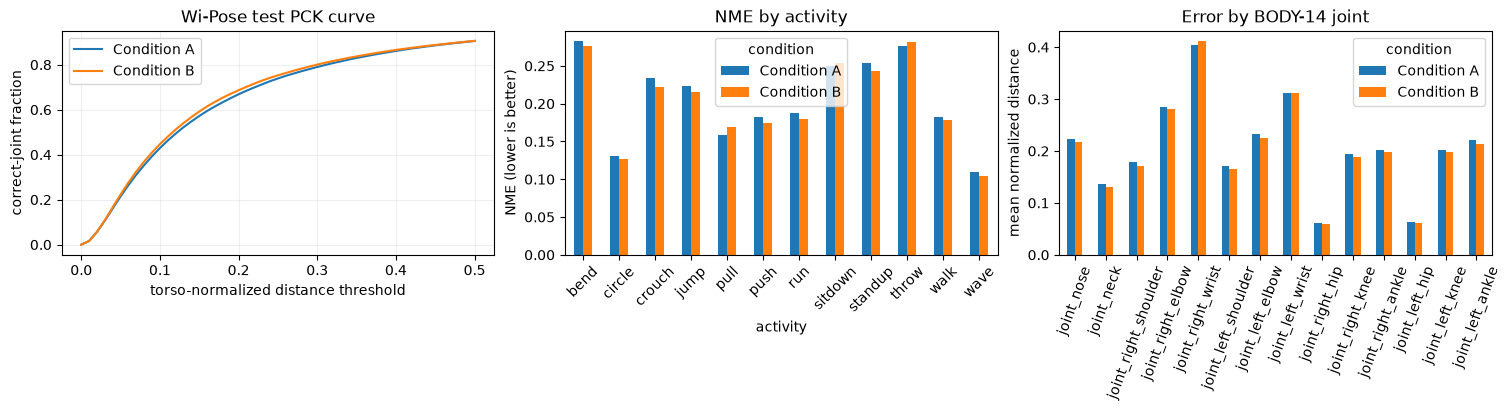

In [2]:
from shared.evaluation.run_final import evaluate_wipose
wipose_summary_path=PROJECT_ROOT/'results/evaluation/wipose_test_summary.csv'
if not wipose_summary_path.exists(): evaluate_wipose(PROJECT_ROOT, DEVICE)
wipose_summary=pd.read_csv(wipose_summary_path,index_col=0)
wipose_rows=pd.read_csv(PROJECT_ROOT/'results/evaluation/wipose_test_per_sample.csv')
wipose_bootstrap=json.loads((PROJECT_ROOT/'results/evaluation/wipose_paired_bootstrap.json').read_text())
display(wipose_summary.style.format('{:.6f}'))
display(pd.DataFrame([wipose_bootstrap]))
fig,axes=plt.subplots(1,3,figsize=(15,4),constrained_layout=True)
colors={'Condition A':'tab:blue','Condition B':'tab:orange'}
for name,g in wipose_rows.groupby('condition'):
    d=g.filter(regex='^joint_').to_numpy().ravel(); d=d[np.isfinite(d)]
    t=np.arange(0,.501,.01); axes[0].plot(t,[(d<=x).mean() for x in t],label=name,color=colors[name])
axes[0].set(title='Wi-Pose test PCK curve',xlabel='torso-normalized distance threshold',ylabel='correct-joint fraction'); axes[0].legend(); axes[0].grid(alpha=.2)
wipose_rows.groupby(['activity','condition']).nme.mean().unstack().plot.bar(ax=axes[1],color=[colors['Condition A'],colors['Condition B']]); axes[1].set(title='NME by activity',ylabel='NME (lower is better)'); axes[1].tick_params(axis='x',rotation=45)
joint_cols=[c for c in wipose_rows if c.startswith('joint_')]; joint_mean=wipose_rows.groupby('condition')[joint_cols].mean().T
joint_mean.plot.bar(ax=axes[2],color=[colors['Condition A'],colors['Condition B']]); axes[2].set(title='Error by BODY-14 joint',ylabel='mean normalized distance'); axes[2].tick_params(axis='x',rotation=70)
plt.show()


### 7.4 AlphaPose pseudo-reference preparation

The official AlphaPose repository is isolated from the project environment. To avoid loading the detector 594 times, the videos are concatenated losslessly and processed in one run. The converter then restores the 90-frame recording boundaries and safely skips already completed NPZ files. The commands and implementation remain visible for reproducibility.

In [4]:
ALPHAPOSE_ROOT=Path('/data/axnguyen/tools/AlphaPose')
ALPHAPOSE_OUTPUT=pseudo_dir/'raw_alphapose'
import inspect
from shared.evaluation.alphapose_pipeline import convert as convert_alphapose_output
commands=pd.DataFrame({'purpose':['prepare 594-video stream','run official AlphaPose on available GPU','convert COCO-17 JSON to BODY-14 NPZ'],
'command':[
'python -m shared.evaluation.alphapose_pipeline prepare',
f'CUDA_VISIBLE_DEVICES=0 /data/axnguyen/Env/Anaconda/envs/alphapose/bin/python scripts/demo_inference.py --cfg configs/coco/resnet/256x192_res50_lr1e-3_1x.yaml --checkpoint pretrained_models/fast_res50_256x192.pth --video {pseudo_dir}/heldout_594.mp4 --outdir {ALPHAPOSE_OUTPUT} --detector yolo --gpus 0 --sp --detbatch 2 --posebatch 32',
f'python -m shared.evaluation.alphapose_pipeline convert --raw-json {ALPHAPOSE_OUTPUT}/alphapose-results.json']})
display(commands)
provenance_path=pseudo_dir/'provenance.json'
if provenance_path.exists(): display(pd.Series(json.loads(provenance_path.read_text()),name='AlphaPose provenance').to_frame())
else: print(f'Extraction is not complete yet. Resumable outputs will appear in {pseudo_dir}')

print('Visible backend: COCO-17 conversion and resumable NPZ writer')
print(inspect.getsource(convert_alphapose_output))


,purpose,command
0,prepare 594-video stream,python -m shared.evaluation.alphapose_pipeline...
1,run official AlphaPose on available GPU,CUDA_VISIBLE_DEVICES=0 /data/axnguyen/Env/Anac...
2,convert COCO-17 JSON to BODY-14 NPZ,python -m shared.evaluation.alphapose_pipeline...


,AlphaPose provenance
alphapose_git_commit,c60106d19afb443e964df6f06ed1842962f5f1f7
alphapose_local_patch,torchvision NMS/RoIAlign fallback; host has no...
confidence_primary,0.3
confidence_sensitivity,"[0.1, 0.5]"
config,configs/coco/resnet/256x192_res50_lr1e-3_1x.yaml
detector,yolov3-spp
detector_checkpoint_sha256,87a1e8c85c763316f34e428f2295e1db9ed4abcec59dd9...
frames,53460
heldout_manifest_sha256,9b7b741d8caddeeac95c6bd944c35b4088963cf62f85dc...
label,AlphaPose video-derived pseudo-reference (not ...


Visible backend: COCO-17 conversion and resumable NPZ writer
def convert(root: Path, output: Path, raw_json: Path, alphapose_root: Path) -> None:
    index = json.loads((output / "video_index.json").read_text())
    detections = json.loads(raw_json.read_text())
    by_frame: dict[int, list[dict]] = defaultdict(list)
    for item in detections:
        stem = Path(str(item["image_id"])).stem
        digits = "".join(c for c in stem if c.isdigit())
        if digits:
            by_frame[int(digits)].append(item)
    frame_base = min(by_frame) if by_frame else 0
    completed, valid_frames = 0, 0
    started = time.perf_counter()
    for row in index:
        target = output / f"{row['sample_id']}.npz"
        if target.exists():
            with np.load(target, allow_pickle=False) as saved:
                valid_frames += int(saved["valid_primary"].sum())
            completed += 1
            continue
        raw = np.full((90, 17, 3), np.nan, np.float32)
        person_score = np.zero

### 7.5 CSI/video alignment

WiMANS does not provide authoritative packet-to-frame timestamps. Frame centres are therefore mapped uniformly across each recording and represented by centred five-packet CSI windows. Zero offset is primary; ±1/±2-frame results quantify how strongly conclusions depend on this approximation.

For video frame $f\in\{0,\ldots,F-1\}$ and a CSI sequence of $T$ packets, the approximate frame centre is

$$q_f=\operatorname{round}\!\left(\frac{f+0.5}{F}T-0.5\right).$$

Evaluation clips a centred five-packet window around $q_f$ to the available packet range. The offset analysis shifts $f$ by $-2,-1,0,1,2$ frames before applying this mapping.

In [5]:
from shared.evaluation.final import aligned_csi_windows
example_row=heldout[0]; example_csi=np.load(example_row['csi_path'],mmap_mode='r')
example_windows=aligned_csi_windows(example_csi,90)
alignment_table=pd.DataFrame({'property':['video frames','CSI packets','model windows','window shape','primary offset','sensitivity offsets'],
'value':[90,len(example_csi),len(example_windows),str(example_windows.shape[1:]),'0 frames','-2,-1,0,+1,+2 frames']})
display(alignment_table)
assert example_windows.shape==(90,9,5,30) and np.isfinite(example_windows).all()


,property,value
0,video frames,90
1,CSI packets,2959
2,model windows,90
3,window shape,"(9, 5, 30)"
4,primary offset,0 frames
5,sensitivity offsets,"-2,-1,0,+1,+2 frames"


### 7.6 Identical-frame WiMANS comparison

Both conditions receive exactly the same normalized CSI windows and are compared with the same valid AlphaPose frames. This cell computes the frozen comparison only when the pseudo-reference set is complete; otherwise it reports the missing prerequisite without inventing results.

In [3]:
from shared.evaluation.run_final import evaluate_wimans
wimans_summary_path=PROJECT_ROOT/'results/evaluation/wimans_pseudo_reference_summary.csv'
if not wimans_summary_path.exists() and int(audit.pseudo_reference_exists.sum())==594:
    evaluate_wimans(PROJECT_ROOT,DEVICE)
if wimans_summary_path.exists():
    wimans_summary=pd.read_csv(wimans_summary_path,index_col=0); display(wimans_summary.style.format('{:.6f}'))
    display(pd.DataFrame([json.loads((PROJECT_ROOT/'results/evaluation/wimans_paired_bootstrap.json').read_text())]))
else: print('WiMANS comparison pending AlphaPose completion; no pseudo-reference metric is claimed.')


,nme,pck_0.05,pck_0.10,pck_0.20,bone_length_error,symmetry_error,pck_auc_0_0.50,valid_frames,valid_recordings
condition,,,,,,,,,
Condition A,0.353495,0.149736,0.313833,0.514011,0.156843,0.026224,0.523864,52684.000000,594.000000
Condition B,0.336049,0.124991,0.268565,0.514269,0.153769,0.018472,0.533149,52684.000000,594.000000


,ci95_high,ci95_low,condition_b_win_rate,groups,mean_delta_b_minus_a,resamples,seed
0,-0.013166,-0.022474,0.607744,594,-0.017837,10000,31050


### 7.7 Quantitative pseudo-reference results

Coverage is shown alongside agreement. Confidence and alignment panels are diagnostic sensitivity analyses, not extra model-selection trials. Red marks the primary protocol: confidence 0.30 and zero-frame offset.

Coverage measures the fraction of video frames that retain a usable BODY-14 pseudo-reference after confidence filtering:

$$\operatorname{coverage}=\frac{N_{\mathrm{valid\ pseudo\text{-}reference\ frames}}}{N_{\mathrm{video\ frames}}}.$$

For consecutive valid frames, reference and prediction velocity magnitudes are $u_f=\operatorname{mean}_j\|\mathbf y_{f,j}-\mathbf y_{f-1,j}\|_2$ and $\hat u_f=\operatorname{mean}_j\|\hat{\mathbf y}_{f,j}-\hat{\mathbf y}_{f-1,j}\|_2$. Velocity error averages $|\hat u_f-u_f|$. Prediction jitter averages the second finite difference:

$$E_{\mathrm{jitter}}=\operatorname{mean}_{f,j}
\|\hat{\mathbf y}_{f+1,j}-2\hat{\mathbf y}_{f,j}+\hat{\mathbf y}_{f-1,j}\|_2.$$

These temporal measures diagnose motion behaviour. They do not replace frame-level pose accuracy.

,condition,offset_frames,confidence_threshold,nme,pck_010,valid_frames
0,Condition A,-2,0.1,0.371696,0.309393,53281
1,Condition A,-2,0.3,0.356814,0.311966,52684
2,Condition A,-2,0.5,0.324892,0.319459,50590
3,Condition A,-1,0.1,0.371681,0.309509,53281
4,Condition A,-1,0.3,0.356794,0.312061,52684
5,Condition A,-1,0.5,0.324879,0.319575,50590
6,Condition A,0,0.1,0.371676,0.309215,53281
7,Condition A,0,0.3,0.356787,0.311762,52684
8,Condition A,0,0.5,0.324853,0.319276,50590
9,Condition A,1,0.1,0.371662,0.308930,53281


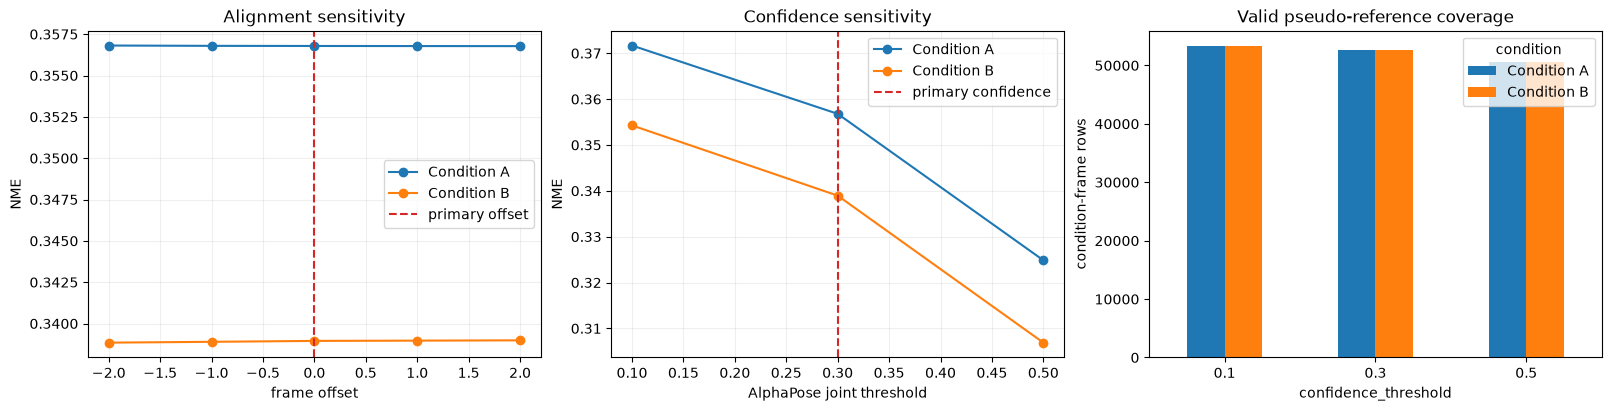

,reference_velocity,prediction_velocity,velocity_error,prediction_jitter
condition,,,,
Condition A,0.066247,0.036351,0.045343,0.059272
Condition B,0.066247,0.045283,0.048305,0.073789


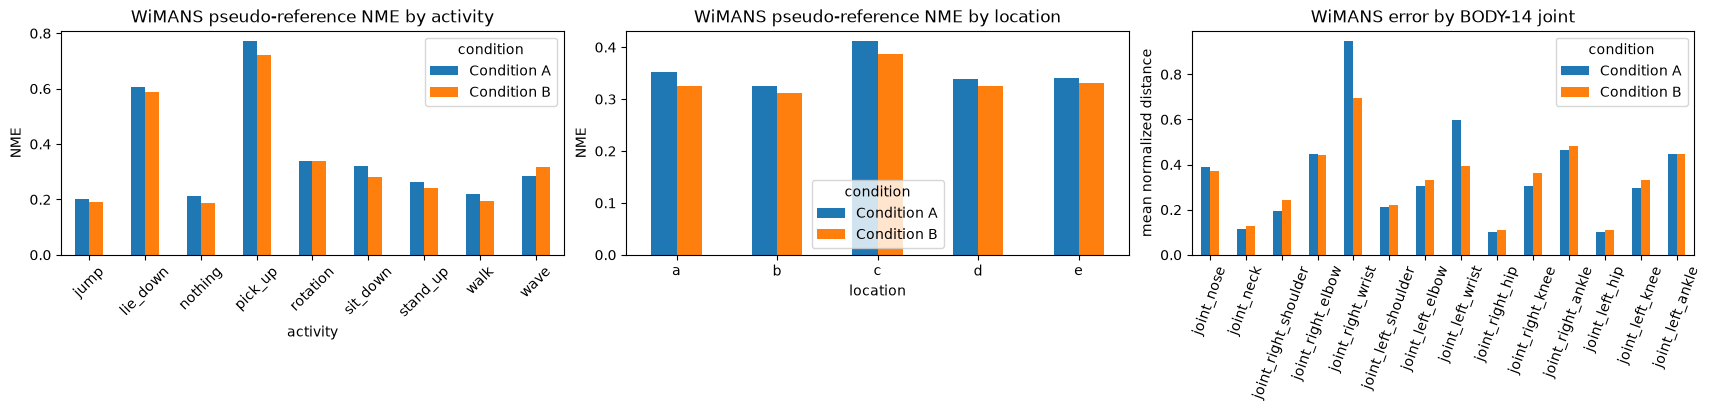

In [4]:
sensitivity_path=PROJECT_ROOT/'results/evaluation/wimans_alignment_confidence_sensitivity.csv'
if sensitivity_path.exists():
    sensitivity=pd.read_csv(sensitivity_path)
    aggregate=sensitivity.groupby(['condition','offset_frames','confidence_threshold']).agg(nme=('nme','mean'),pck_010=('pck_0.10','mean'),valid_frames=('valid_frames','sum')).reset_index()
    display(aggregate)
    fig,axes=plt.subplots(1,3,figsize=(16,4),constrained_layout=True)
    for name,g in aggregate[aggregate.confidence_threshold==.3].groupby('condition'): axes[0].plot(g.offset_frames,g.nme,'o-',label=name,color=colors[name])
    axes[0].axvline(0,color='tab:red',ls='--',label='primary offset'); axes[0].set(title='Alignment sensitivity',xlabel='frame offset',ylabel='NME'); axes[0].legend(); axes[0].grid(alpha=.2)
    for name,g in aggregate[aggregate.offset_frames==0].groupby('condition'): axes[1].plot(g.confidence_threshold,g.nme,'o-',label=name,color=colors[name])
    axes[1].axvline(.3,color='tab:red',ls='--',label='primary confidence'); axes[1].set(title='Confidence sensitivity',xlabel='AlphaPose joint threshold',ylabel='NME'); axes[1].legend(); axes[1].grid(alpha=.2)
    coverage=aggregate[aggregate.offset_frames==0].pivot(index='confidence_threshold',columns='condition',values='valid_frames'); coverage.plot.bar(ax=axes[2],color=[colors['Condition A'],colors['Condition B']]); axes[2].set(title='Valid pseudo-reference coverage',ylabel='condition-frame rows'); axes[2].tick_params(axis='x',rotation=0)
    plt.show()
    primary=pd.read_csv(PROJECT_ROOT/'results/evaluation/wimans_pseudo_reference_per_frame.csv')
    temporal=pd.read_csv(PROJECT_ROOT/'results/evaluation/wimans_temporal_metrics.csv')
    display(temporal.groupby('condition')[['reference_velocity','prediction_velocity','velocity_error','prediction_jitter']].mean().style.format('{:.6f}'))
    fig,axes=plt.subplots(1,3,figsize=(17,4),constrained_layout=True)
    primary.groupby(['activity','condition']).nme.mean().unstack().plot.bar(ax=axes[0],color=[colors['Condition A'],colors['Condition B']]); axes[0].set(title='WiMANS pseudo-reference NME by activity',ylabel='NME'); axes[0].tick_params(axis='x',rotation=45)
    primary.groupby(['location','condition']).nme.mean().unstack().plot.bar(ax=axes[1],color=[colors['Condition A'],colors['Condition B']]); axes[1].set(title='WiMANS pseudo-reference NME by location',ylabel='NME'); axes[1].tick_params(axis='x',rotation=0)
    joints=[x for x in primary if x.startswith('joint_')]; primary.groupby('condition')[joints].mean().T.plot.bar(ax=axes[2],color=[colors['Condition A'],colors['Condition B']]); axes[2].set(title='WiMANS error by BODY-14 joint',ylabel='mean normalized distance'); axes[2].tick_params(axis='x',rotation=70)
    plt.show()
else:
    print('Sensitivity plots will appear after AlphaPose conversion and WiMANS evaluation.')


### 7.8 Condition A performance — source-only PoseCNN

Condition A is reported independently here so its behaviour is visible without a paired plot obscuring it. Blue always means Condition A. The left table distinguishes native Wi-Pose ground truth from WiMANS AlphaPose video-derived pseudo-references. Lower NME is better; higher PCK is better.

,evaluation,samples/frames,NME,PCK@0.05,PCK@0.10,PCK@0.20
0,Wi-Pose native test,17645,0.2062,0.215,0.430,0.669
1,WiMANS AlphaPose pseudo-reference,52684,0.3535,0.150,0.314,0.514


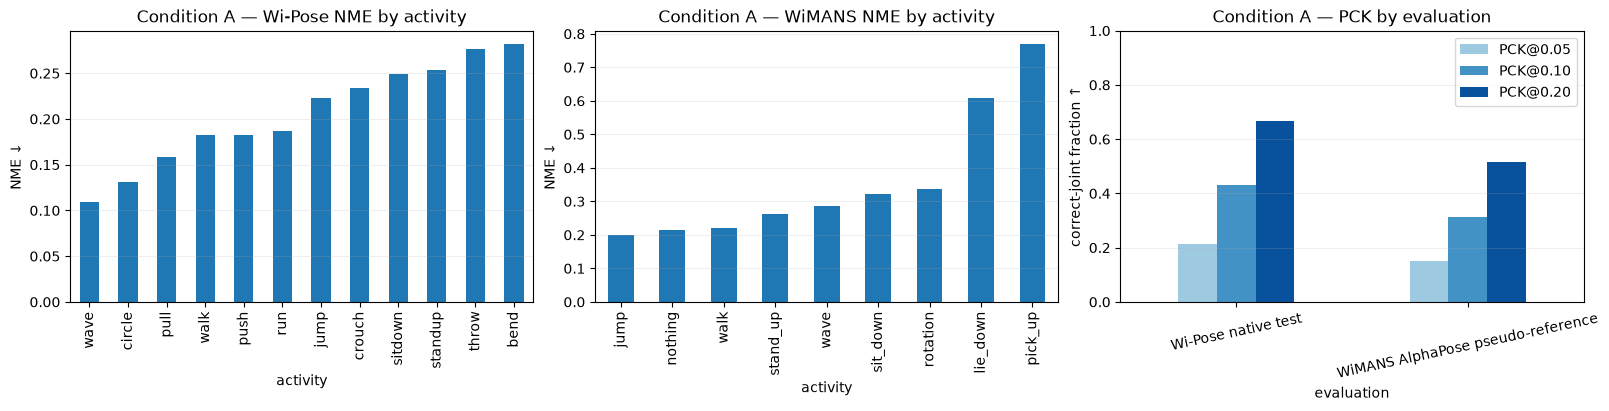

In [5]:
condition_name='Condition A'; condition_color='tab:blue'
native=pd.read_csv(PROJECT_ROOT/'results/evaluation/wipose_test_per_sample.csv').query('condition == @condition_name')
cross=pd.read_csv(PROJECT_ROOT/'results/evaluation/wimans_pseudo_reference_per_frame.csv').query('condition == @condition_name')
summary=pd.DataFrame([
    {'evaluation':'Wi-Pose native test','samples/frames':len(native),'NME':native.nme.mean(),'PCK@0.05':native['pck_0.05'].mean(),'PCK@0.10':native['pck_0.10'].mean(),'PCK@0.20':native['pck_0.20'].mean()},
    {'evaluation':'WiMANS AlphaPose pseudo-reference','samples/frames':len(cross),'NME':cross.nme.mean(),'PCK@0.05':cross['pck_0.05'].mean(),'PCK@0.10':cross['pck_0.10'].mean(),'PCK@0.20':cross['pck_0.20'].mean()}])
display(summary.style.format({'NME':'{:.4f}','PCK@0.05':'{:.3f}','PCK@0.10':'{:.3f}','PCK@0.20':'{:.3f}'}))
fig,axes=plt.subplots(1,3,figsize=(16,4),constrained_layout=True)
native.groupby('activity').nme.mean().sort_values().plot.bar(ax=axes[0],color=condition_color)
cross.groupby('activity').nme.mean().sort_values().plot.bar(ax=axes[1],color=condition_color)
pck=summary.set_index('evaluation')[['PCK@0.05','PCK@0.10','PCK@0.20']]; pck.plot.bar(ax=axes[2],color=['#9ecae1','#4292c6','#08519c'])
axes[0].set(title='Condition A — Wi-Pose NME by activity',ylabel='NME ↓'); axes[1].set(title='Condition A — WiMANS NME by activity',ylabel='NME ↓'); axes[2].set(title='Condition A — PCK by evaluation',ylabel='correct-joint fraction ↑',ylim=(0,1)); axes[2].tick_params(axis='x',rotation=12)
for ax in axes: ax.grid(axis='y',alpha=.2)
plt.show()

### 7.9 Condition B performance — SSL-initialized PoseCNN

Condition B is shown separately with the same tables, aggregation, axes, and metric definitions as Condition A. Orange always means Condition B, so the two subsections can be read independently without changing the evaluation protocol.

,evaluation,samples/frames,NME,PCK@0.05,PCK@0.10,PCK@0.20
0,Wi-Pose native test,17645,0.2023,0.223,0.447,0.686
1,WiMANS AlphaPose pseudo-reference,52684,0.3360,0.125,0.269,0.514


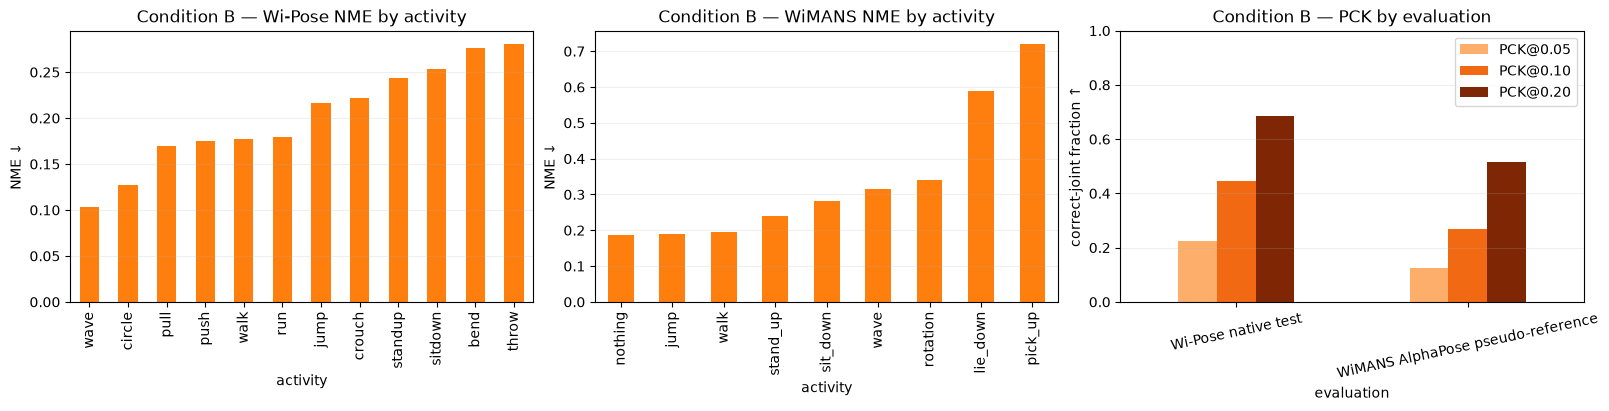

In [6]:
condition_name='Condition B'; condition_color='tab:orange'
native=pd.read_csv(PROJECT_ROOT/'results/evaluation/wipose_test_per_sample.csv').query('condition == @condition_name')
cross=pd.read_csv(PROJECT_ROOT/'results/evaluation/wimans_pseudo_reference_per_frame.csv').query('condition == @condition_name')
summary=pd.DataFrame([
    {'evaluation':'Wi-Pose native test','samples/frames':len(native),'NME':native.nme.mean(),'PCK@0.05':native['pck_0.05'].mean(),'PCK@0.10':native['pck_0.10'].mean(),'PCK@0.20':native['pck_0.20'].mean()},
    {'evaluation':'WiMANS AlphaPose pseudo-reference','samples/frames':len(cross),'NME':cross.nme.mean(),'PCK@0.05':cross['pck_0.05'].mean(),'PCK@0.10':cross['pck_0.10'].mean(),'PCK@0.20':cross['pck_0.20'].mean()}])
display(summary.style.format({'NME':'{:.4f}','PCK@0.05':'{:.3f}','PCK@0.10':'{:.3f}','PCK@0.20':'{:.3f}'}))
fig,axes=plt.subplots(1,3,figsize=(16,4),constrained_layout=True)
native.groupby('activity').nme.mean().sort_values().plot.bar(ax=axes[0],color=condition_color)
cross.groupby('activity').nme.mean().sort_values().plot.bar(ax=axes[1],color=condition_color)
pck=summary.set_index('evaluation')[['PCK@0.05','PCK@0.10','PCK@0.20']]; pck.plot.bar(ax=axes[2],color=['#fdae6b','#f16913','#7f2704'])
axes[0].set(title='Condition B — Wi-Pose NME by activity',ylabel='NME ↓'); axes[1].set(title='Condition B — WiMANS NME by activity',ylabel='NME ↓'); axes[2].set(title='Condition B — PCK by evaluation',ylabel='correct-joint fraction ↑',ylim=(0,1)); axes[2].tick_params(axis='x',rotation=12)
for ax in axes: ax.grid(axis='y',alpha=.2)
plt.show()

### 7.10 Corrected side-by-side qualitative skeletons

The evaluation now first rotates WiMANS image coordinates into the same stored-camera frame used to train on Wi-Pose. For human-readable display, every reference and prediction is then transformed identically with `display = (−canonical_y, canonical_x)` and the display-y axis is inverted—the same convention used in exploration. Green is the pseudo-reference, blue is Condition A, and orange is Condition B. Remaining disagreement is model error, not a different plot flip.

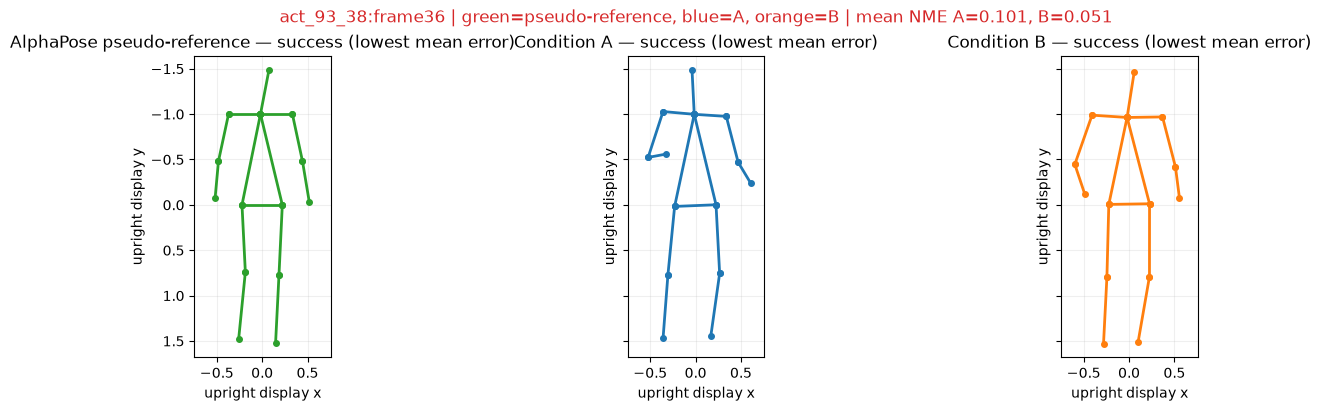

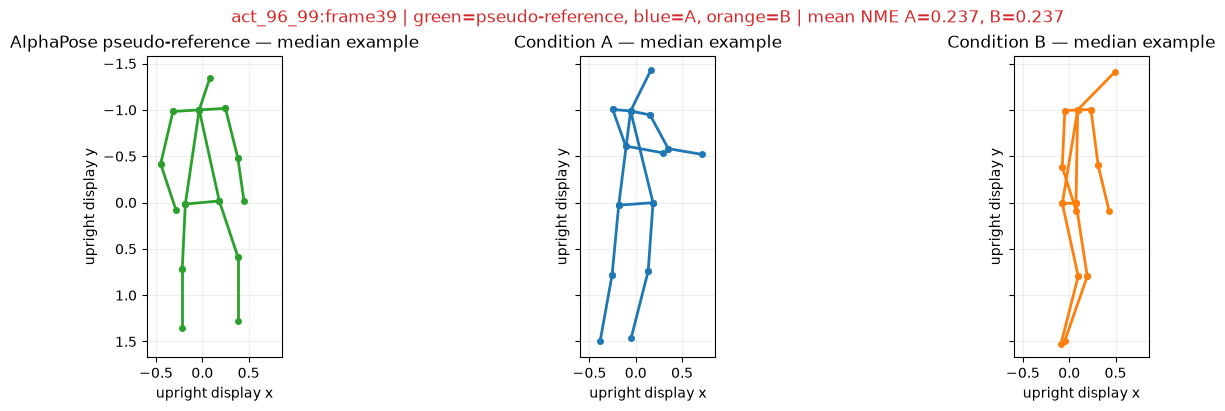

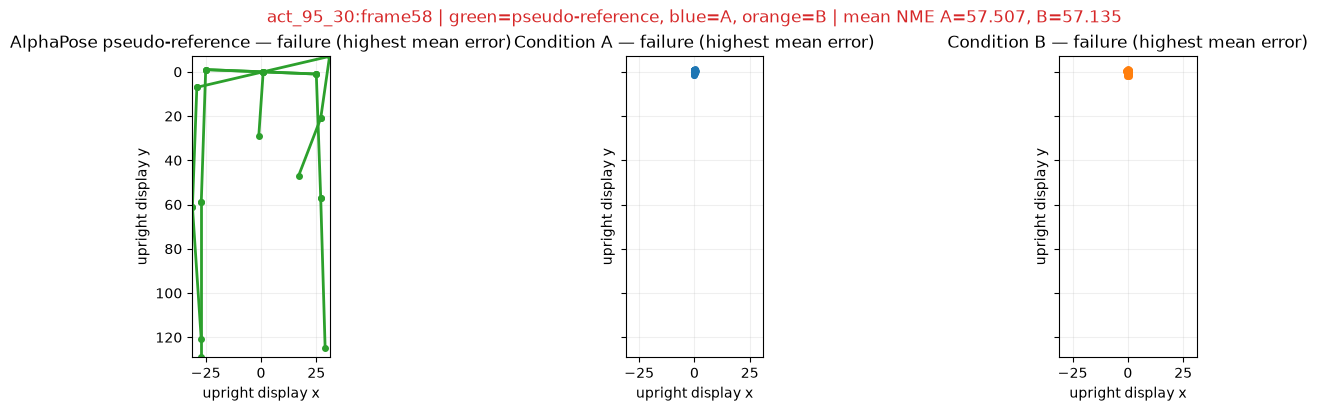

In [7]:
qualitative_path=PROJECT_ROOT/'results/evaluation/wimans_qualitative_predictions.npz'
from shared.data.skeleton import BODY_14_EDGES
q=np.load(qualitative_path)
def pose_for_display(pose):
    pose=np.asarray(pose); return np.stack((-pose[...,1],pose[...,0]),axis=-1)
error_a=np.linalg.norm(q['condition_a']-q['reference'],axis=-1).mean(1); error_b=np.linalg.norm(q['condition_b']-q['reference'],axis=-1).mean(1); mean_error=(error_a+error_b)/2
chosen=[int(np.argmin(mean_error)),int(np.argsort(mean_error)[len(mean_error)//2]),int(np.argmax(mean_error))]
labels=['success (lowest mean error)','median example','failure (highest mean error)']; poses=[('AlphaPose pseudo-reference','reference','tab:green'),('Condition A','condition_a','tab:blue'),('Condition B','condition_b','tab:orange')]
for selected,label in zip(chosen,labels):
    fig,axes=plt.subplots(1,3,figsize=(13,4),sharex=True,sharey=True,constrained_layout=True)
    shown=np.concatenate([pose_for_display(q[key][selected]) for _,key,_ in poses]); margin=.15; lo=shown.min(0)-margin; hi=shown.max(0)+margin
    for ax,(title,key,color) in zip(axes,poses):
        pose=pose_for_display(q[key][selected])
        for a,b in BODY_14_EDGES: ax.plot(pose[[a,b],0],pose[[a,b],1],'-o',color=color,lw=2,ms=4)
        ax.set(xlim=(lo[0],hi[0]),ylim=(hi[1],lo[1]),aspect='equal',xlabel='upright display x',ylabel='upright display y'); ax.grid(alpha=.2); ax.set_title(f'{title} — {label}')
    fig.suptitle(f"{q['sample_frame'][selected]} | green=pseudo-reference, blue=A, orange=B | mean NME A={error_a[selected]:.3f}, B={error_b[selected]:.3f}",color='tab:red'); plt.show()

### 7.11 Full-recording skeleton video

This reproduces the exploration-style animation for one complete WiMANS recording. All three panels use identical axes and the corrected upright display transform. Change `VIDEO_RECORDING` to any ID present in `sample_frame`; the cell sorts frames numerically, reports per-frame NME, embeds an HTML5 video in the notebook, and saves the same MP4 under `results/evaluation/figures/`.

In [8]:
from matplotlib import animation
from IPython.display import HTML
VIDEO_RECORDING='act_95_33'
VIDEO_FPS=12
ids=q['sample_frame'].astype(str); selected=np.flatnonzero(np.char.startswith(ids,VIDEO_RECORDING+':frame'))
assert len(selected),f'No valid pseudo-reference frames found for {VIDEO_RECORDING}'
frame_number=np.array([int(ids[i].rsplit('frame',1)[1]) for i in selected]); selected=selected[np.argsort(frame_number)]
video_poses={key:pose_for_display(q[key][selected]) for _,key,_ in poses}; all_xy=np.concatenate(list(video_poses.values()),axis=0).reshape(-1,2); lo=all_xy.min(0)-.15; hi=all_xy.max(0)+.15
fig,axes=plt.subplots(1,3,figsize=(13,4),constrained_layout=True); artists=[]
for ax,(title,key,color) in zip(axes,poses):
    lines=[ax.plot([],[],'-o',color=color,lw=2.5,ms=4)[0] for _ in BODY_14_EDGES]; artists.append(lines)
    ax.set(xlim=(lo[0],hi[0]),ylim=(hi[1],lo[1]),aspect='equal',xlabel='upright display x',ylabel='upright display y',title=title); ax.grid(alpha=.2)
def update_comparison_video(i):
    for lines,(_,key,_) in zip(artists,poses):
        pose=video_poses[key][i]
        for line,(a,b) in zip(lines,BODY_14_EDGES): line.set_data(pose[[a,b],0],pose[[a,b],1])
    idx=selected[i]; fig.suptitle(f'{ids[idx]} ({i+1}/{len(selected)}) | green=pseudo-reference, blue=A, orange=B | NME A={error_a[idx]:.3f}, B={error_b[idx]:.3f}',color='tab:red')
    return [line for lines in artists for line in lines]
comparison_video=animation.FuncAnimation(fig,update_comparison_video,frames=len(selected),interval=1000/VIDEO_FPS,blit=False,repeat=True)
plt.close(fig)
video_path=PROJECT_ROOT/'results/evaluation/figures'/f'{VIDEO_RECORDING}_skeleton_comparison.mp4'; video_path.parent.mkdir(parents=True,exist_ok=True)
comparison_video.save(video_path,writer='ffmpeg',fps=VIDEO_FPS,dpi=120)
print(f'Saved {len(selected)} valid frames: {video_path}')
HTML(comparison_video.to_html5_video())

Saved 90 valid frames: /data/axnguyen/31050_ML/wifi_csi_hpe/results/evaluation/figures/act_95_33_skeleton_comparison.mp4


### 7.12 Random recording comparison

This is the randomized version of Section 6.11. Every execution selects one complete held-out WiMANS recording, animates every valid frame for the AlphaPose pseudo-reference and both conditions, embeds the HTML5 video, and saves the MP4 under `results/evaluation/figures/`. Set `RANDOM_SEED` to an integer only when a repeatable choice is needed. WiMANS identifiers denote recordings, not verified subject identities.

In [3]:
from matplotlib import animation
from IPython.display import HTML
RANDOM_SEED = None  # Integer for repeatability; None chooses anew each run.
RANDOM_VIDEO_FPS = 12
rng = np.random.default_rng(RANDOM_SEED)
ids = q['sample_frame'].astype(str)
recordings = np.unique(np.array([item.split(':frame', 1)[0] for item in ids]))
RANDOM_VIDEO_RECORDING = str(rng.choice(recordings))
selected = np.flatnonzero(np.char.startswith(ids, RANDOM_VIDEO_RECORDING + ':frame'))
frame_number = np.array([int(ids[i].rsplit('frame', 1)[1]) for i in selected])
selected = selected[np.argsort(frame_number)]
video_poses = {key: pose_for_display(q[key][selected]) for _, key, _ in poses}
all_xy = np.concatenate(list(video_poses.values()), axis=0).reshape(-1, 2)
lo, hi = all_xy.min(0) - .15, all_xy.max(0) + .15
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True); artists = []
for ax, (title, key, color) in zip(axes, poses):
    lines = [ax.plot([], [], '-o', color=color, lw=2.5, ms=4)[0] for _ in BODY_14_EDGES]; artists.append(lines)
    ax.set(xlim=(lo[0], hi[0]), ylim=(hi[1], lo[1]), aspect='equal', xlabel='upright display x', ylabel='upright display y', title=title); ax.grid(alpha=.2)
def update_random_comparison_video(i):
    for lines, (_, key, _) in zip(artists, poses):
        pose = video_poses[key][i]
        for line, (a, b) in zip(lines, BODY_14_EDGES): line.set_data(pose[[a, b], 0], pose[[a, b], 1])
    idx = selected[i]; fig.suptitle(f'{ids[idx]} ({i+1}/{len(selected)}) | green=pseudo-reference, blue=A, orange=B | NME A={error_a[idx]:.3f}, B={error_b[idx]:.3f}', color='tab:red')
    return [line for lines in artists for line in lines]
random_comparison_video = animation.FuncAnimation(fig, update_random_comparison_video, frames=len(selected), interval=1000/RANDOM_VIDEO_FPS, blit=False, repeat=True)
plt.close(fig)
video_path = PROJECT_ROOT/'results/evaluation/figures'/f'{RANDOM_VIDEO_RECORDING}_random_skeleton_comparison.mp4'; video_path.parent.mkdir(parents=True, exist_ok=True)
random_comparison_video.save(video_path, writer='ffmpeg', fps=RANDOM_VIDEO_FPS, dpi=120)
print(f'Random recording: {RANDOM_VIDEO_RECORDING} | saved {len(selected)} valid frames: {video_path}')
HTML(random_comparison_video.to_html5_video())

Random recording: act_93_49 | saved 90 valid frames: /data/axnguyen/31050_ML/wifi_csi_hpe/results/evaluation/figures/act_93_49_random_skeleton_comparison.mp4


### 7.13 Findings, limitations, and evidence-led refinement

**Coordinate correction.** WiMANS AlphaPose image coordinates are now rotated into the Wi-Pose stored-camera frame before canonicalization. This is part of evaluation, not a cosmetic plot flip. The notebook applies the inverse upright transform only for display.

**Native result.** On untouched Wi-Pose ground truth, Condition B improves NME from `0.206182` to `0.202268`; the participant-level paired B−A interval is `[-0.007606, -0.000060]`.

**Cross-domain result.** AlphaPose provides 52,684 primary-valid frames across all 594 recordings (98.55% coverage). After correcting the coordinate contract, NME is `0.353495` for A and `0.336049` for B. The recording-level paired B−A interval is `[-0.022474, -0.013166]`, with B winning on 60.77% of recordings. This supports improved agreement with the video-derived pseudo-reference, not a claim of physical ground-truth accuracy.

**Limitations and refinement.** Uniform duration alignment remains approximate, and AlphaPose confidence/filtering can bias the valid subset. The retained offset, confidence, temporal, anatomical, per-activity, and qualitative diagnostics show where the aggregate result is stable and where better synchronization or reference auditing is needed.

## 8. Discussion, limitations, and implementation log

### 8.1 Answer to the research question

PoseCNN learned a measurable mapping from five-packet WiFi-CSI amplitude windows to canonical BODY-14 coordinates. Condition A reached an NME of `0.206182` and PCK@0.20 of `0.668676` on the untouched Wi-Pose test groups. These values show that source-domain CSI contains pose information, while the wrist errors and left/right confusions show that a five-packet amplitude window does not resolve all articulation.

Label-free CSI pretraining produced a small, consistent gain. Condition B reduced Wi-Pose test NME to `0.202268`, a difference of `-0.003914` or about `1.90%` relative to Condition A. Its participant-level paired 95% bootstrap interval, `[-0.007606, -0.000060]`, excludes zero. Condition B also raised PCK@0.10 from `0.429555` to `0.446925` and PCK@0.20 from `0.668676` to `0.686479`.

The held-out WiMANS comparison points in the same direction. Condition B reduced pseudo-reference NME to `0.336049`, compared with `0.353495` for Condition A. The recording-level paired interval was `[-0.022474, -0.013166]`, and Condition B had lower recording NME in `60.77%` of the 594 recordings. This result supports improved agreement with AlphaPose-derived video references in the target environment. WiMANS does not provide physical pose ground truth, so the experiment cannot establish absolute target-domain accuracy.

### 8.2 Reading the metrics together

NME and PCK describe different parts of the error distribution. NME averages distance and remains sensitive to large mistakes. PCK reports the share of joints inside a chosen tolerance. On WiMANS, Condition B improved NME, PCK@0.20, PCK-AUC, bone error, and symmetry error, while Condition A retained higher PCK@0.05 and PCK@0.10. Condition B therefore reduced larger errors and improved broad agreement without producing more very-close joints at the strict thresholds.

The per-joint analysis locates the remaining errors. Hips and the nose achieve strong nearest-joint identity rates because canonicalization anchors the skeleton at the hip midpoint and these landmarks vary less than distal joints. Wrists show larger errors and more confusion with elbows or the opposite limb. Knee and ankle off-diagonal entries expose left/right ambiguity in 2D projections. The confusion matrix measures spatial identity, while NME and PCK measure distance; no single metric captures all three patterns.

Bone-length and symmetry errors test anatomical structure. Low values can coexist with inaccurate coordinates because a plausible skeleton may appear in the wrong pose. The qualitative frames and full-recording videos provide a final check for flips, collapsed limbs, temporal instability, and coordinate-transform errors that scalar summaries can hide.

### 8.3 Internal validity and leakage control

The experiment keeps complete Wi-Pose recording groups in one partition. Ninety-six groups train the model, 12 control early stopping, and 12 remain untouched until final evaluation. The normalizer uses the 132,786 training frames only. Checkpoint and normalizer checksums guard against evaluating a model with a different data split.

Condition A never reads WiMANS during fitting. Condition B uses WiMANS classroom and meeting-room CSI during masked reconstruction without activity or pose labels. It excludes all 594 empty-room evaluation recordings. Both conditions then use the same Wi-Pose train and monitor partitions, loss, optimizer settings, and checkpoint-selection metric. This design isolates SSL initialization as the main experimental difference.

Adjacent frames remain correlated within each recording. The participant-level Wi-Pose bootstrap and recording-level WiMANS bootstrap treat groups, rather than frames, as independent sampling units. Twelve Wi-Pose test groups still provide a small basis for uncertainty estimates, so the interval may change under a larger subject sample.

### 8.4 Construct and external validity

Wi-Pose labels come from AlphaPose estimates on synchronized video. Confidence weighting reduces the influence of uncertain joints during coordinate training, but pose-estimator bias remains in the targets. Canonicalization removes translation and body scale, which supports cross-camera comparison but limits the output to relative articulation. The system does not recover room position, image coordinates, metric limb lengths, depth, or a 3D pose.

WiMANS adds changes in room, frequency band, hardware placement, activities, and capture procedure. These changes make it useful for domain-transfer analysis. Its video-derived pseudo-references inherit detector errors, occlusion failures, and the coordinate conventions of AlphaPose. Reported target-domain metrics quantify agreement with that reference pipeline.

Uniform-duration alignment supplies an approximation because WiMANS lacks authoritative packet-to-frame timestamps. The confidence and ±2-frame sensitivity analyses test nearby alternatives, yet they cannot prove the correct correspondence. Better synchronization could change both conditions' scores and their paired difference.

The current dataset selection covers one person at 5 GHz. Results do not establish performance for multiple people, 2.4 GHz signals, unseen hardware layouts, different buildings, or real-time deployment.

### 8.5 Model and signal limitations

- Five packets give the model little motion context. Predictions can miss fast limb movement or confuse poses with similar instantaneous CSI patterns.
- The pipeline uses amplitude only. It does not test calibrated CSI phase, antenna phase differences, or phase sanitization.
- PoseCNN contains about 0.92 million parameters and uses convolution across packets and subcarriers. The experiment does not compare it with transformers, recurrent models, graph heads, or longer-context temporal models.
- The skeleton-aware objective weights coordinate, bone, and symmetry terms by `1.00`, `0.25`, and `0.05`. The notebook holds these values fixed rather than estimating their sensitivity.
- The SSL mask ratio remains fixed at 30%. The experiment does not isolate the contributions of Wi-Pose SSL windows, WiMANS SSL windows, or the quantity of target-domain exposure.
- Training and evaluation rely on one random seed for splits and optimization. Group bootstrap intervals quantify test-set uncertainty, not training-seed variability.

### 8.6 Evidence-led next experiments

The next experiment should repeat both conditions across several optimization seeds while keeping the participant split fixed. Reporting the mean and spread would separate initialization noise from the observed SSL gain.

A longer-context ablation should reconstruct continuous Wi-Pose recordings and compare 5, 15, and 30 packets under the same participant split. Temporal consistency or a lightweight temporal convolution belongs in that experiment. Filtering should enter only as a measured ablation because independent smoothing of five-packet samples lacks enough context.

The target-domain evaluation needs synchronized packet and video timestamps or a documented alignment marker. A small manually audited subset would estimate AlphaPose pseudo-reference error and reveal whether confidence filtering favours easy poses. Multi-person and 2.4 GHz experiments should follow after the single-person alignment issue is resolved.

SSL ablations should compare source-only pretraining, target-only pretraining, mixed pretraining, and random initialization. Mask ratios and the number of WiMANS windows should vary one factor at a time. These comparisons would identify whether Condition B benefits from masked reconstruction, extra source exposure, or target-domain CSI.

### 8.7 Reproducibility and system behaviour

Each major notebook section starts from saved manifests, normalization statistics, configurations, logs, and checkpoints. Restart cells validate file presence and data contracts. Training writes `last.pt` for continuation and `best.pt` for monitor-selected inference. Final evaluations load `best.pt` and write per-sample metrics, summaries, bootstrap results, qualitative predictions, and provenance.

The notebook keeps camera-coordinate conversion separate from the model target and display rotation. This separation corrected an earlier WiMANS orientation error. Named BODY-14 mapping, tensor-shape assertions, finite-value checks, and skeleton plots provide independent checks against silent coordinate or indexing mistakes.

### 8.8 Privacy, safety, and deployment scope

WiFi sensing can estimate human activity without a visible camera. A deployment should require informed consent, access controls, retention limits, and a clear indication that sensing is active. Removing video at inference reduces image collection but does not remove privacy risk because CSI can reveal presence and movement.

The present model should not support medical, safety-critical, workplace-monitoring, or identity-related decisions. The evaluation does not establish reliability across body types, mobility aids, clothing, room layouts, or radio hardware. A deployed interface should expose uncertainty and failure states rather than presenting every skeleton as reliable.

### 8.9 Conclusion

The source-only model establishes a working WiFi-to-pose baseline under a leakage-controlled split. Masked CSI pretraining improves average source-test accuracy and target pseudo-reference agreement, with paired intervals that favour Condition B. The gain remains modest, and target evaluation depends on AlphaPose and approximate temporal alignment. Longer synchronized context, repeated training seeds, and audited target references would provide the strongest next evidence.

### 8.10 Implementation log

| Milestone | Challenge | Decision | Verification |
|---|---|---|---|
| Joint decoding | Paper numbering could be confused with AlphaPose order | Retain AlphaPose-18 and map BODY-14 by name | Mapping table, anatomy edges, visual audit |
| Split design | Adjacent frames can leak | Keep complete declared groups together | Pairwise overlap assertion |
| Normalization | Monitor and test leakage | Fit $[9,30]$ statistics on training frames only | Split checksum and fitted count |
| Signal cleaning | Five packets cannot support long filters | Use amplitude and frozen standardization for version 1 | Shape and finite-value checks |
| Supervised objective | Coordinates alone can produce implausible limbs | Add bone-vector and symmetry terms | Component logs and source inspection |
| SSL transfer | The first autoencoder encoder did not match PoseCNN | Use the exact four PoseCNN residual blocks | Strict state-dictionary transfer |
| Target evaluation | WiMANS lacks native pose coordinates | Use qualified AlphaPose pseudo-references | Provenance, coverage, and confidence audit |
| Coordinate contract | WiMANS images used a different orientation | Convert references into the Wi-Pose camera frame | Shared-axis qualitative plots and video |
| Temporal alignment | Packet-to-frame timestamps are unavailable | Use uniform-duration centres and five-packet windows | $\pm2$-frame sensitivity analysis |
| Statistical unit | Adjacent frames are correlated | Bootstrap participants or recordings | Paired group-level confidence intervals |

### 8.11 AI assistance and remaining knowledge gaps

AI assistance helped scaffold code, review tensor and coordinate contracts, identify leakage risks, and edit documentation. I checked suggestions against executable source, manifest assertions, checkpoint checksums, metric files, and visual skeleton audits. I rejected ambiguous joint indexing and the first partial encoder-transfer design. I retained corrections that mapped joints by name, separated display rotation from training coordinates, and enforced strict encoder transfer.

The remaining knowledge gaps concern WiMANS packet-to-video synchronization, the interpretation of Wi-Pose recording identifiers as people, and the physical accuracy of AlphaPose pseudo-references. The submission record should include dated prompt examples, accepted and rejected suggestions, personal changes, and the checks used to verify each material change.

## Submission checklist

- [ ] One PDF named `STUDENTNAME_STUDENTID_YEAR_UTS_ML_Journal.pdf`.
- [ ] Plain-text public notebook URL included in the PDF.
- [ ] Public notebook/repository access tested in a logged-out browser.
- [ ] Exploration, preprocessing, training, and evaluation implementations included.
- [ ] Task input/output defined for training and deployment.
- [ ] Architecture, loss, optimizer, and theory-to-code mapping explained.
- [ ] Proper grouped train/monitor/test validation demonstrated.
- [ ] Results, visualizations, metrics, implications, limitations, and refinements included.
- [ ] Implementation log, AI usage, verification, and knowledge gaps included.
- [ ] Saved notebook outputs match versioned result files and the offline demo.